In [1]:
"""
UC2 Enhanced Decision Layer - Python Version

Purpose:
- Recreate the enhanced UC2 decision layer in Python.
- Use Kaggle IoT health monitoring dataset.
- Add synthetic EHR/profile records.
- Run emergency fast path before ML.
- Run tiny autoencoder scoring for non-emergency rows.
- Apply caregiver HITL matrix.
- Apply EHR/personalized thresholds.
- Apply recurrence risk.
- Compute final severity and notification routing.
- Build SLM/provider/MCP payloads.

This mirrors the new enhanced TypeScript decision-layer handoff.

Author: Jay / ACCESS-DP UC2 prototype
"""

from __future__ import annotations

import json
import math
import random
import hashlib
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta
from pathlib import Path
from typing import Dict, List, Optional, Any, Tuple

import numpy as np
import pandas as pd

# CONFIG

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Update these paths for your machine
DATASET_PATH = Path(
    r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\USE_CASE_2\iot_health_monitoring_dataset.csv"
)

MODEL_DIR = Path(
    r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\model_handoff\model"
)

TFLITE_MODEL_PATH = MODEL_DIR / "tiny_uc2_autoencoder.tflite"
SCALER_JSON_PATH = MODEL_DIR / "tiny_uc2_scaler.json"
METADATA_JSON_PATH = MODEL_DIR / "tiny_uc2_metadata.json"

OUTPUT_DIR = Path("./uc2_enhanced_decision_layer_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_EVENTS_CSV = OUTPUT_DIR / "uc2_enhanced_decision_events.csv"
OUTPUT_EVENTS_JSONL = OUTPUT_DIR / "uc2_enhanced_decision_events.jsonl"
OUTPUT_EHR_CSV = OUTPUT_DIR / "synthetic_ehr_profiles.csv"
OUTPUT_SUMMARY_JSON = OUTPUT_DIR / "uc2_enhanced_summary.json"

# MODEL CONTRACT

MODEL_NAME = "tiny_uc2_autoencoder"
MODEL_VERSION = "tiny_ae_uc2_v0.1.0"
USE_CASE = "UC2_SLOW_PATH_ANOMALY"
EVENT_NAME = "TRIGGER_WORKFLOW_ANOMALY_TYPE_04"

FEATURE_ORDER = [
    "heart_rate",
    "blood_oxygen",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "glucose_level",
    "body_temperature",
    "respiratory_rate",
    "activity_level",
    "sleep_quality",
    "stress_level",
    "hrv_sdnn",
    "steps_count",
    "calories_burned",
    "pulse_pressure",
    "mean_arterial_pressure",
    "hour_sin",
    "hour_cos",
    "is_sleep_window",
]

ANOMALY_THRESHOLD_MSE = 1.129848

EMERGENCY_THRESHOLDS = {
    "blood_oxygen_min": 88.0,
    "heart_rate_max": 140.0,
    "respiratory_rate_max": 30.0,
    "body_temperature_f_max": 104.0,
}

# ENUM-LIKE CONSTANTS

FINAL_NOTIFICATION_TYPES = [
    "NO_ALERT",
    "MONITORING_ADVICE",
    "SLM_SUMMARY_AND_PROVIDER_NOTE",
    "CRITICAL_EMERGENCY_ALERT",
    "DISMISSED_WITH_AUDIT",
]

SENSOR_ANOMALY_TYPES = [
    "NORMAL_PATTERN",
    "CARDIO_RESPIRATORY_SIGNAL_CHANGE",
    "SLEEP_RECOVERY_DEVIATION",
    "EXERTION_OR_ACTIVITY_PATTERN",
    "UNEXPLAINED_PHYSIOLOGIC_STRESS",
    "POSSIBLE_SEIZURE_LIKE_MOTION",
    "POSSIBLE_SENSOR_ARTIFACT",
    "CRITICAL_VITAL_THRESHOLD",
    "INSUFFICIENT_DATA",
]

POST_HITL_ANOMALY_TYPES = [
    "RESPIRATORY_CONCERN",
    "GI_AUTONOMIC_RISK",
    "SLEEP_STRESS_RECOVERY",
    "EXERTION_LIKE_PATTERN",
    "MEDICATION_ADHERENCE_CONCERN",
    "POSTICTAL_RECOVERY_CONCERN",
    "SEIZURE_LIKE_EVENT_CONFIRMED",
    "PROVIDER_REVIEW_RECOMMENDED",
    "NO_CONCERN_CONFIRMED",
    "CRITICAL_EMERGENCY_ALERT",
    "POSSIBLE_SENSOR_ARTIFACT",
    "INSUFFICIENT_DATA",
]

ANOMALY_FAMILIES = [
    "CARDIO_RESPIRATORY",
    "GI_AUTONOMIC",
    "SLEEP_RECOVERY",
    "EXERTION_ACTIVITY",
    "SEIZURE_LIKE",
    "CRITICAL_VITAL",
    "NORMAL_OR_UNKNOWN",
]

CAREGIVER_CODES = [
    "EXERCISE_OR_ACTIVITY",
    "POOR_SLEEP",
    "STRESS_OR_EMOTIONAL_UPSET",
    "REDUCED_INTAKE",
    "MEDICATION_CHANGE_OR_MISSED",
    "BATHROOM_CHANGES",
    "VOMITING_OR_DIARRHEA",
    "WEAK_CONFUSED_NOT_BASELINE",
    "PAIN_OR_DISCOMFORT",
    "BREATHING_DIFFERENT",
    "SENSOR_OR_WATCH_ISSUE",
    "NOTHING_UNUSUAL_NOTICED",
    "NOT_SURE",
]

# DATA CLASSES

@dataclass
class PatientProfile:
    patient_id: str
    baseline_spo2: float
    baseline_resting_hr: float
    baseline_respiratory_rate: float
    baseline_bp_systolic: float
    baseline_bp_diastolic: float
    baseline_glucose: float
    baseline_temperature_f: float
    known_conditions: List[str]
    medications: List[str]
    clinician_recipient: str
    care_plan_notes: str

@dataclass
class EmergencyRuleResult:
    emergency_triggered: bool
    severity: int
    reasons: List[str]

@dataclass
class PersonalizedThresholdResult:
    severity_floor: int
    reasons: List[str]

@dataclass
class CaregiverMatrixResult:
    anomaly_family: str
    selected_codes: List[str]
    max_matrix_delta: int
    observation_severity_floor: int
    critical_route_triggered: bool
    critical_route_reasons: List[str]
    matrix_reasons: List[str]

@dataclass
class RecurrenceRiskResult:
    recurrence_score: int
    severity_floor: int
    reasons: List[str]

# UTILS

def now_iso() -> str:
    return datetime.utcnow().isoformat() + "Z"

def stable_hash(obj: Any) -> str:
    blob = json.dumps(obj, sort_keys=True, default=str)
    return hashlib.sha256(blob.encode("utf-8")).hexdigest()

def safe_float(x: Any, default: float = np.nan) -> float:
    try:
        if pd.isna(x):
            return default
        return float(x)
    except Exception:
        return default

def clamp(value: float, min_value: float, max_value: float) -> float:
    return max(min_value, min(max_value, value))

def hour_time_features(timestamp: datetime) -> Tuple[float, float, int]:
    hour_float = timestamp.hour + timestamp.minute / 60.0
    angle = 2 * math.pi * hour_float / 24.0
    hour_sin = math.sin(angle)
    hour_cos = math.cos(angle)
    is_sleep_window = 1 if timestamp.hour >= 22 or timestamp.hour < 6 else 0
    return hour_sin, hour_cos, is_sleep_window

def mean_arterial_pressure(sbp: float, dbp: float) -> float:
    return dbp + ((sbp - dbp) / 3.0)

# LOADERS

def load_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")

    df = pd.read_csv(path)
    print(f"[OK] Loaded dataset: {path}")
    print(f"[OK] Shape: {df.shape}")
    print(f"[OK] Columns: {list(df.columns)}")
    return df

def load_scaler_json(path: Path) -> Dict[str, Any]:
    if not path.exists():
        print(f"[WARN] Scaler JSON not found: {path}")
        print("[WARN] Using identity scaler fallback.")
        return {
            "feature_order": FEATURE_ORDER,
            "mean": [0.0] * len(FEATURE_ORDER),
            "scale": [1.0] * len(FEATURE_ORDER),
        }

    with open(path, "r", encoding="utf-8") as f:
        scaler = json.load(f)

    print(f"[OK] Loaded scaler JSON: {path}")
    return scaler

def load_metadata_json(path: Path) -> Dict[str, Any]:
    if not path.exists():
        print(f"[WARN] Metadata JSON not found: {path}")
        return {
            "model_name": MODEL_NAME,
            "model_version": MODEL_VERSION,
            "feature_order": FEATURE_ORDER,
            "anomaly_threshold_mse": ANOMALY_THRESHOLD_MSE,
        }

    with open(path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    print(f"[OK] Loaded metadata JSON: {path}")
    return metadata

# SYNTHETIC EHR GENERATION

def create_synthetic_ehr_profiles(df: pd.DataFrame, max_patients: Optional[int] = None) -> Dict[str, PatientProfile]:
    """
    Creates synthetic EHR/profile records.

    If the dataset has patient IDs, use them.
    Otherwise assign synthetic patient IDs.
    """

    possible_patient_cols = ["patient_id", "Patient_ID", "patient", "PatientID", "user_id", "User_ID"]

    patient_col = None
    for col in possible_patient_cols:
        if col in df.columns:
            patient_col = col
            break

    if patient_col is None:
        df["patient_id"] = [f"patient_{i % 500:03d}" for i in range(len(df))]
        patient_col = "patient_id"

    patient_ids = sorted(df[patient_col].astype(str).unique().tolist())

    if max_patients is not None:
        patient_ids = patient_ids[:max_patients]

    profiles: Dict[str, PatientProfile] = {}

    condition_pool = [
        ["COPD", "hypertension"],
        ["TBI history", "mobility limitation"],
        ["spina bifida", "neurogenic bladder risk"],
        ["diabetes risk", "hypertension"],
        ["early neurological condition"],
        ["post-surgical recovery", "fall risk"],
    ]

    medication_pool = [
        ["albuterol", "lisinopril"],
        ["metformin", "atorvastatin"],
        ["gabapentin", "acetaminophen"],
        ["levetiracetam", "vitamin D"],
        ["amlodipine"],
        ["none_recorded"],
    ]

    for i, pid in enumerate(patient_ids):
        patient_rows = df[df[patient_col].astype(str) == pid]

        def col_mean_or_default(candidates: List[str], default: float) -> float:
            for c in candidates:
                if c in patient_rows.columns:
                    val = pd.to_numeric(patient_rows[c], errors="coerce").mean()
                    if not pd.isna(val):
                        return float(val)
            return default

        baseline_hr = col_mean_or_default(["heart_rate", "Heart_Rate", "HR"], 78.0)
        baseline_spo2 = col_mean_or_default(["blood_oxygen", "SpO2", "spo2", "Oxygen_Saturation"], 97.0)
        baseline_rr = col_mean_or_default(["respiratory_rate", "Respiratory_Rate", "RR"], 16.0)
        baseline_sbp = col_mean_or_default(["blood_pressure_systolic", "Systolic_BP", "BP_Systolic"], 118.0)
        baseline_dbp = col_mean_or_default(["blood_pressure_diastolic", "Diastolic_BP", "BP_Diastolic"], 76.0)
        baseline_glucose = col_mean_or_default(["glucose_level", "Glucose", "Blood_Glucose"], 102.0)
        baseline_temp = col_mean_or_default(["body_temperature", "Body_Temperature", "Temperature"], 98.4)

        # Keep baselines in plausible range
        profile = PatientProfile(
            patient_id=pid,
            baseline_spo2=clamp(baseline_spo2, 90.0, 99.0),
            baseline_resting_hr=clamp(baseline_hr, 55.0, 105.0),
            baseline_respiratory_rate=clamp(baseline_rr, 10.0, 24.0),
            baseline_bp_systolic=clamp(baseline_sbp, 90.0, 160.0),
            baseline_bp_diastolic=clamp(baseline_dbp, 50.0, 100.0),
            baseline_glucose=clamp(baseline_glucose, 70.0, 180.0),
            baseline_temperature_f=clamp(baseline_temp, 96.0, 100.0),
            known_conditions=condition_pool[i % len(condition_pool)],
            medications=medication_pool[i % len(medication_pool)],
            clinician_recipient=f"clinician_{i % 12:02d}@example.org",
            care_plan_notes="Synthetic EHR profile for UC2 enhanced decision-layer testing.",
        )

        profiles[pid] = profile

    ehr_df = pd.DataFrame([asdict(p) for p in profiles.values()])
    ehr_df.to_csv(OUTPUT_EHR_CSV, index=False)
    print(f"[OK] Synthetic EHR profiles saved: {OUTPUT_EHR_CSV}")
    print(f"[OK] Synthetic EHR profile count: {len(profiles)}")

    return profiles

# FEATURE NORMALIZATION / ENGINEERING

COLUMN_ALIASES = {
    "heart_rate": ["heart_rate", "Heart_Rate", "HR"],
    "blood_oxygen": ["blood_oxygen", "SpO2", "spo2", "Oxygen_Saturation"],
    "blood_pressure_systolic": ["blood_pressure_systolic", "Systolic_BP", "BP_Systolic"],
    "blood_pressure_diastolic": ["blood_pressure_diastolic", "Diastolic_BP", "BP_Diastolic"],
    "glucose_level": ["glucose_level", "Glucose", "Blood_Glucose"],
    "body_temperature": ["body_temperature", "Body_Temperature", "Temperature"],
    "respiratory_rate": ["respiratory_rate", "Respiratory_Rate", "RR"],
    "activity_level": ["activity_level", "Activity_Level", "activity"],
    "sleep_quality": ["sleep_quality", "Sleep_Quality"],
    "stress_level": ["stress_level", "Stress_Level"],
    "hrv_sdnn": ["hrv_sdnn", "HRV", "HRV_SDNN"],
    "steps_count": ["steps_count", "Steps", "steps"],
    "calories_burned": ["calories_burned", "Calories_Burned", "calories"],
}

def get_row_value(row: pd.Series, canonical_name: str, default: float = np.nan) -> float:
    aliases = COLUMN_ALIASES.get(canonical_name, [canonical_name])
    for col in aliases:
        if col in row.index:
            val = safe_float(row[col], np.nan)
            if not pd.isna(val):
                return val
    return default

def get_patient_id(row: pd.Series, idx: int) -> str:
    for col in ["patient_id", "Patient_ID", "PatientID", "patient", "user_id", "User_ID"]:
        if col in row.index:
            return str(row[col])
    return f"patient_{idx % 500:03d}"

def get_timestamp(row: pd.Series, idx: int) -> datetime:
    for col in ["timestamp", "Timestamp", "time", "datetime", "DateTime"]:
        if col in row.index:
            try:
                return pd.to_datetime(row[col]).to_pydatetime()
            except Exception:
                pass
    return datetime(2026, 1, 1, 0, 0, 0) + timedelta(minutes=idx)

def complete_feature_vector(
    row: pd.Series,
    idx: int,
    profile: PatientProfile,
) -> Tuple[Dict[str, float], Dict[str, str]]:
    """
    Builds the exact 18-feature model vector.

    Missing values can be filled from:
    - EHR/profile baseline
    - deterministic derived values
    - conservative defaults
    """

    timestamp = get_timestamp(row, idx)
    quality_tags: Dict[str, str] = {}

    def val_or_profile(feature: str, profile_value: float, default_value: float) -> float:
        raw = get_row_value(row, feature, np.nan)
        if not pd.isna(raw):
            quality_tags[feature] = "observed_dataset"
            return float(raw)

        if profile_value is not None and not pd.isna(profile_value):
            quality_tags[feature] = "ehr_profile"
            return float(profile_value)

        quality_tags[feature] = "imputed_default"
        return float(default_value)

    heart_rate = val_or_profile("heart_rate", profile.baseline_resting_hr, 78.0)
    blood_oxygen = val_or_profile("blood_oxygen", profile.baseline_spo2, 97.0)
    sbp = val_or_profile("blood_pressure_systolic", profile.baseline_bp_systolic, 118.0)
    dbp = val_or_profile("blood_pressure_diastolic", profile.baseline_bp_diastolic, 76.0)
    glucose = val_or_profile("glucose_level", profile.baseline_glucose, 102.0)
    temp = val_or_profile("body_temperature", profile.baseline_temperature_f, 98.4)
    rr = val_or_profile("respiratory_rate", profile.baseline_respiratory_rate, 16.0)

    activity = get_row_value(row, "activity_level", np.nan)
    if pd.isna(activity):
        activity = 0.20
        quality_tags["activity_level"] = "imputed_default"
    else:
        quality_tags["activity_level"] = "observed_dataset"

    sleep_quality = get_row_value(row, "sleep_quality", np.nan)
    if pd.isna(sleep_quality):
        sleep_quality = 0.65
        quality_tags["sleep_quality"] = "imputed_default"
    else:
        quality_tags["sleep_quality"] = "observed_dataset"

    stress = get_row_value(row, "stress_level", np.nan)
    if pd.isna(stress):
        stress = 0.30
        quality_tags["stress_level"] = "imputed_default"
    else:
        quality_tags["stress_level"] = "observed_dataset"

    hrv_sdnn = get_row_value(row, "hrv_sdnn", np.nan)
    if pd.isna(hrv_sdnn):
        hrv_sdnn = 42.0
        quality_tags["hrv_sdnn"] = "imputed_default"
    else:
        quality_tags["hrv_sdnn"] = "observed_dataset"

    steps = get_row_value(row, "steps_count", np.nan)
    if pd.isna(steps):
        steps = 0.0
        quality_tags["steps_count"] = "imputed_default"
    else:
        quality_tags["steps_count"] = "observed_dataset"

    calories = get_row_value(row, "calories_burned", np.nan)
    if pd.isna(calories):
        calories = max(1.0, float(activity) * 10.0)
        quality_tags["calories_burned"] = "derived_or_imputed"
    else:
        quality_tags["calories_burned"] = "observed_dataset"

    pulse_pressure = sbp - dbp
    map_value = mean_arterial_pressure(sbp, dbp)
    hour_sin, hour_cos, sleep_window = hour_time_features(timestamp)

    quality_tags["pulse_pressure"] = "derived"
    quality_tags["mean_arterial_pressure"] = "derived"
    quality_tags["hour_sin"] = "derived_time"
    quality_tags["hour_cos"] = "derived_time"
    quality_tags["is_sleep_window"] = "derived_time"

    features = {
        "heart_rate": heart_rate,
        "blood_oxygen": blood_oxygen,
        "blood_pressure_systolic": sbp,
        "blood_pressure_diastolic": dbp,
        "glucose_level": glucose,
        "body_temperature": temp,
        "respiratory_rate": rr,
        "activity_level": activity,
        "sleep_quality": sleep_quality,
        "stress_level": stress,
        "hrv_sdnn": hrv_sdnn,
        "steps_count": steps,
        "calories_burned": calories,
        "pulse_pressure": pulse_pressure,
        "mean_arterial_pressure": map_value,
        "hour_sin": hour_sin,
        "hour_cos": hour_cos,
        "is_sleep_window": sleep_window,
    }

    return features, quality_tags

# EMERGENCY RULE ENGINE

def run_emergency_rules(features: Dict[str, float]) -> EmergencyRuleResult:
    reasons = []

    if features["blood_oxygen"] <= EMERGENCY_THRESHOLDS["blood_oxygen_min"]:
        reasons.append(
            f"SpO2 {features['blood_oxygen']:.1f} <= {EMERGENCY_THRESHOLDS['blood_oxygen_min']:.1f}"
        )

    if features["heart_rate"] >= EMERGENCY_THRESHOLDS["heart_rate_max"]:
        reasons.append(
            f"Heart rate {features['heart_rate']:.1f} >= {EMERGENCY_THRESHOLDS['heart_rate_max']:.1f}"
        )

    if features["respiratory_rate"] >= EMERGENCY_THRESHOLDS["respiratory_rate_max"]:
        reasons.append(
            f"Respiratory rate {features['respiratory_rate']:.1f} >= {EMERGENCY_THRESHOLDS['respiratory_rate_max']:.1f}"
        )

    if features["body_temperature"] >= EMERGENCY_THRESHOLDS["body_temperature_f_max"]:
        reasons.append(
            f"Temperature {features['body_temperature']:.1f}F >= {EMERGENCY_THRESHOLDS['body_temperature_f_max']:.1f}F"
        )

    return EmergencyRuleResult(
        emergency_triggered=len(reasons) > 0,
        severity=3 if reasons else 0,
        reasons=reasons,
    )

# SCALING + AE SCORING

def scale_features(features: Dict[str, float], scaler: Dict[str, Any]) -> np.ndarray:
    feature_order = scaler.get("feature_order", FEATURE_ORDER)
    mean = np.array(scaler.get("mean", [0.0] * len(feature_order)), dtype=np.float32)
    scale = np.array(scaler.get("scale", [1.0] * len(feature_order)), dtype=np.float32)

    x = np.array([features[f] for f in feature_order], dtype=np.float32)

    # Avoid divide by zero
    scale = np.where(scale == 0, 1.0, scale)

    x_scaled = (x - mean) / scale
    return x_scaled.astype(np.float32)

def try_tflite_reconstruction(x_scaled: np.ndarray, tflite_model_path: Path) -> Optional[np.ndarray]:
    """
    Attempts to run TFLite inference.

    Requires either:
    - tensorflow installed, or
    - tflite_runtime installed.

    If unavailable, returns None and the caller can use fallback mock reconstruction.
    """

    if not tflite_model_path.exists():
        return None

    interpreter = None

    try:
        import tensorflow as tf
        interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
    except Exception:
        try:
            from tflite_runtime.interpreter import Interpreter
            interpreter = Interpreter(model_path=str(tflite_model_path))
        except Exception:
            return None

    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_tensor = x_scaled.reshape(1, -1).astype(np.float32)

    interpreter.set_tensor(input_details[0]["index"], input_tensor)
    interpreter.invoke()
    output_tensor = interpreter.get_tensor(output_details[0]["index"])

    return output_tensor.reshape(-1).astype(np.float32)

def mock_reconstruction(x_scaled: np.ndarray) -> np.ndarray:
    """
    Fallback mock reconstruction.

    This allows the decision layer to run even without TensorFlow/TFLite installed.
    It is NOT the real model.

    It intentionally reconstructs most normal-ish points well but adds slight
    distortion for large absolute z values so downstream logic can be tested.
    """
    noise = np.random.normal(0, 0.05, size=x_scaled.shape).astype(np.float32)
    distortion = np.where(np.abs(x_scaled) > 2.0, 0.35 * np.sign(x_scaled), 0.0).astype(np.float32)
    return x_scaled - distortion + noise

def compute_ae_score(
    x_scaled: np.ndarray,
    reconstruction: np.ndarray,
    feature_order: List[str] = FEATURE_ORDER,
) -> Tuple[float, List[Dict[str, Any]], Dict[str, float]]:
    errors = (x_scaled - reconstruction) ** 2
    mse = float(np.mean(errors))

    error_by_feature = {
        feature_order[i]: float(errors[i])
        for i in range(len(feature_order))
    }

    top_indices = np.argsort(errors)[::-1][:5]
    top_contributors = [
        {
            "feature": feature_order[i],
            "contribution": float(errors[i]),
        }
        for i in top_indices
    ]

    return mse, top_contributors, error_by_feature

# SENSOR ANOMALY ROUTING

def assign_sensor_anomaly_type(
    features: Dict[str, float],
    ae_score_mse: float,
    ml_anomaly_flag: bool,
    emergency_result: EmergencyRuleResult,
    top_contributors: List[Dict[str, Any]],
) -> Tuple[str, str]:
    """
    Returns:
    - sensor_anomaly_type
    - anomaly_family
    """

    if emergency_result.emergency_triggered:
        return "CRITICAL_VITAL_THRESHOLD", "CRITICAL_VITAL"

    if not ml_anomaly_flag:
        return "NORMAL_PATTERN", "NORMAL_OR_UNKNOWN"

    top_features = {x["feature"] for x in top_contributors[:3]}

    hr = features["heart_rate"]
    spo2 = features["blood_oxygen"]
    rr = features["respiratory_rate"]
    activity = features["activity_level"]
    sleep_quality = features["sleep_quality"]
    stress = features["stress_level"]
    hrv = features["hrv_sdnn"]

    cardio_features = {"heart_rate", "blood_oxygen", "respiratory_rate", "hrv_sdnn"}
    sleep_features = {"sleep_quality", "is_sleep_window", "hour_sin", "hour_cos"}
    exertion_features = {"activity_level", "steps_count", "calories_burned"}

    if len(top_features.intersection(cardio_features)) > 0 or hr > 105 or spo2 < 94 or rr > 22:
        return "CARDIO_RESPIRATORY_SIGNAL_CHANGE", "CARDIO_RESPIRATORY"

    if len(top_features.intersection(sleep_features)) > 0 or sleep_quality < 0.4:
        return "SLEEP_RECOVERY_DEVIATION", "SLEEP_RECOVERY"

    if len(top_features.intersection(exertion_features)) > 0 and activity > 0.6:
        return "EXERTION_OR_ACTIVITY_PATTERN", "EXERTION_ACTIVITY"

    if stress > 0.7 and hrv < 25:
        return "UNEXPLAINED_PHYSIOLOGIC_STRESS", "GI_AUTONOMIC"

    return "UNEXPLAINED_PHYSIOLOGIC_STRESS", "NORMAL_OR_UNKNOWN"

def pre_hitl_severity_from_ml(
    ml_anomaly_flag: bool,
    sensor_anomaly_type: str,
    ae_score_mse: float,
) -> int:
    if sensor_anomaly_type == "CRITICAL_VITAL_THRESHOLD":
        return 3

    if not ml_anomaly_flag:
        return 0

    # Basic severity from AE score distance above threshold
    ratio = ae_score_mse / ANOMALY_THRESHOLD_MSE if ANOMALY_THRESHOLD_MSE > 0 else 0

    if ratio >= 1.5:
        return 2

    return 1

# CAREGIVER HITL MATRIX

HITL_MATRIX: Dict[str, Dict[str, Dict[str, Any]]] = {
    "EXERCISE_OR_ACTIVITY": {
        "CARDIO_RESPIRATORY": {"delta": 0},
        "GI_AUTONOMIC": {"delta": 0},
        "SLEEP_RECOVERY": {"delta": 0},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 0},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 0},
    },
    "POOR_SLEEP": {
        "CARDIO_RESPIRATORY": {"delta": 1},
        "GI_AUTONOMIC": {"delta": 1},
        "SLEEP_RECOVERY": {"delta": 2},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 1},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 0},
    },
    "STRESS_OR_EMOTIONAL_UPSET": {
        "CARDIO_RESPIRATORY": {"delta": 1},
        "GI_AUTONOMIC": {"delta": 1},
        "SLEEP_RECOVERY": {"delta": 1},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 1},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 0},
    },
    "REDUCED_INTAKE": {
        "CARDIO_RESPIRATORY": {"delta": 1},
        "GI_AUTONOMIC": {"delta": 2},
        "SLEEP_RECOVERY": {"delta": 1},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 1},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 0},
    },
    "MEDICATION_CHANGE_OR_MISSED": {
        "CARDIO_RESPIRATORY": {"delta": 2},
        "GI_AUTONOMIC": {"delta": 2},
        "SLEEP_RECOVERY": {"delta": 1},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 2},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 1},
    },
    "BATHROOM_CHANGES": {
        "CARDIO_RESPIRATORY": {"delta": 1},
        "GI_AUTONOMIC": {"delta": 2},
        "SLEEP_RECOVERY": {"delta": 0},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 1},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 0},
    },
    "VOMITING_OR_DIARRHEA": {
        "CARDIO_RESPIRATORY": {"delta": 1},
        "GI_AUTONOMIC": {"delta": 3},
        "SLEEP_RECOVERY": {"delta": 1},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 2},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 1},
    },
    "WEAK_CONFUSED_NOT_BASELINE": {
        "CARDIO_RESPIRATORY": {"delta": 2},
        "GI_AUTONOMIC": {"delta": 2},
        "SLEEP_RECOVERY": {"delta": 2},
        "EXERTION_ACTIVITY": {"delta": 1},
        "SEIZURE_LIKE": {"delta": 3},
        "CRITICAL_VITAL": {"delta": 3, "critical_route": True},
        "NORMAL_OR_UNKNOWN": {"delta": 2},
    },
    "PAIN_OR_DISCOMFORT": {
        "CARDIO_RESPIRATORY": {"delta": 1},
        "GI_AUTONOMIC": {"delta": 2},
        "SLEEP_RECOVERY": {"delta": 1},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 1},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 0},
    },
    "BREATHING_DIFFERENT": {
        "CARDIO_RESPIRATORY": {"delta": 3},
        "GI_AUTONOMIC": {"delta": 2},
        "SLEEP_RECOVERY": {"delta": 1},
        "EXERTION_ACTIVITY": {"delta": 1},
        "SEIZURE_LIKE": {"delta": 3},
        "CRITICAL_VITAL": {"delta": 3, "critical_route": True},
        "NORMAL_OR_UNKNOWN": {"delta": 2},
    },
    "SENSOR_OR_WATCH_ISSUE": {
        "CARDIO_RESPIRATORY": {"delta": 0},
        "GI_AUTONOMIC": {"delta": 0},
        "SLEEP_RECOVERY": {"delta": 0},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 0},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 0},
    },
    "NOTHING_UNUSUAL_NOTICED": {
        "CARDIO_RESPIRATORY": {"delta": 0},
        "GI_AUTONOMIC": {"delta": 0},
        "SLEEP_RECOVERY": {"delta": 0},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 0},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 0},
    },
    "NOT_SURE": {
        "CARDIO_RESPIRATORY": {"delta": 1},
        "GI_AUTONOMIC": {"delta": 1},
        "SLEEP_RECOVERY": {"delta": 0},
        "EXERTION_ACTIVITY": {"delta": 0},
        "SEIZURE_LIKE": {"delta": 1},
        "CRITICAL_VITAL": {"delta": 0},
        "NORMAL_OR_UNKNOWN": {"delta": 0},
    },
}

OLD_CAREGIVER_ALIASES = {
    "EXERCISE": "EXERCISE_OR_ACTIVITY",
    "ACTIVITY": "EXERCISE_OR_ACTIVITY",
    "POOR_SLEEP_QUALITY": "POOR_SLEEP",
    "STRESS": "STRESS_OR_EMOTIONAL_UPSET",
    "REDUCED_FOOD_FLUID": "REDUCED_INTAKE",
    "MED_CHANGE": "MEDICATION_CHANGE_OR_MISSED",
    "MISSED_MEDICATION": "MEDICATION_CHANGE_OR_MISSED",
    "BATHROOM": "BATHROOM_CHANGES",
    "GI_SYMPTOMS": "VOMITING_OR_DIARRHEA",
    "VOMITING": "VOMITING_OR_DIARRHEA",
    "DIARRHEA": "VOMITING_OR_DIARRHEA",
    "CONFUSION": "WEAK_CONFUSED_NOT_BASELINE",
    "WEAKNESS": "WEAK_CONFUSED_NOT_BASELINE",
    "PAIN": "PAIN_OR_DISCOMFORT",
    "BREATHING": "BREATHING_DIFFERENT",
    "SENSOR_ISSUE": "SENSOR_OR_WATCH_ISSUE",
    "NOTHING": "NOTHING_UNUSUAL_NOTICED",
    "UNSURE": "NOT_SURE",
}

def normalize_caregiver_codes(codes: Optional[List[str]]) -> List[str]:
    if not codes:
        return []

    normalized = []

    for code in codes:
        if code is None:
            continue

        c = str(code).strip().upper()

        if c in CAREGIVER_CODES:
            normalized.append(c)
        elif c in OLD_CAREGIVER_ALIASES:
            normalized.append(OLD_CAREGIVER_ALIASES[c])

    return sorted(list(set(normalized)))

def infer_synthetic_caregiver_codes(
    features: Dict[str, float],
    sensor_anomaly_type: str,
    anomaly_family: str,
    row_idx: int,
) -> List[str]:
    """
    Simulates caregiver HITL responses for offline dataset testing.

    In the actual app, these come from caregiver checkbox selections.
    """

    codes = []

    if sensor_anomaly_type == "NORMAL_PATTERN":
        return []

    hr = features["heart_rate"]
    spo2 = features["blood_oxygen"]
    rr = features["respiratory_rate"]
    activity = features["activity_level"]
    sleep_quality = features["sleep_quality"]
    stress = features["stress_level"]

    if anomaly_family == "CARDIO_RESPIRATORY":
        if spo2 < 94 or rr > 22:
            codes.append("BREATHING_DIFFERENT")
        elif hr > 110 and activity > 0.5:
            codes.append("EXERCISE_OR_ACTIVITY")
        else:
            codes.append("NOT_SURE")

    elif anomaly_family == "GI_AUTONOMIC":
        if row_idx % 3 == 0:
            codes.append("VOMITING_OR_DIARRHEA")
        else:
            codes.append("REDUCED_INTAKE")

    elif anomaly_family == "SLEEP_RECOVERY":
        codes.append("POOR_SLEEP")

    elif anomaly_family == "EXERTION_ACTIVITY":
        codes.append("EXERCISE_OR_ACTIVITY")

    elif anomaly_family == "SEIZURE_LIKE":
        codes.append("WEAK_CONFUSED_NOT_BASELINE")

    else:
        if stress > 0.7:
            codes.append("STRESS_OR_EMOTIONAL_UPSET")
        elif sleep_quality < 0.4:
            codes.append("POOR_SLEEP")
        else:
            codes.append("NOT_SURE")

    # Occasionally simulate sensor/watch issue
    if row_idx % 997 == 0:
        codes.append("SENSOR_OR_WATCH_ISSUE")

    return normalize_caregiver_codes(codes)

def evaluate_caregiver_matrix(
    selected_codes: List[str],
    anomaly_family: str,
    pre_hitl_severity: int,
) -> CaregiverMatrixResult:
    selected_codes = normalize_caregiver_codes(selected_codes)

    if anomaly_family not in ANOMALY_FAMILIES:
        anomaly_family = "NORMAL_OR_UNKNOWN"

    max_delta = 0
    critical_route = False
    critical_reasons = []
    matrix_reasons = []

    for code in selected_codes:
        cell = HITL_MATRIX.get(code, {}).get(anomaly_family, {"delta": 0})
        delta = int(cell.get("delta", 0))
        max_delta = max(max_delta, delta)

        matrix_reasons.append(
            f"{code} + {anomaly_family} => delta {delta}"
        )

        if cell.get("critical_route", False):
            critical_route = True
            critical_reasons.append(
                f"{code} with {anomaly_family} triggered explicit critical route"
            )

    if critical_route:
        observation_floor = 3
    else:
        observation_floor = min(2, pre_hitl_severity + max_delta)

    return CaregiverMatrixResult(
        anomaly_family=anomaly_family,
        selected_codes=selected_codes,
        max_matrix_delta=max_delta,
        observation_severity_floor=observation_floor,
        critical_route_triggered=critical_route,
        critical_route_reasons=critical_reasons,
        matrix_reasons=matrix_reasons,
    )

# EHR / PERSONALIZED THRESHOLDS

def evaluate_personalized_thresholds(
    features: Dict[str, float],
    profile: PatientProfile,
) -> PersonalizedThresholdResult:
    reasons = []
    floor = 0

    spo2_drop = profile.baseline_spo2 - features["blood_oxygen"]
    hr_rise = features["heart_rate"] - profile.baseline_resting_hr
    rr_rise = features["respiratory_rate"] - profile.baseline_respiratory_rate

    if spo2_drop >= 6:
        floor = max(floor, 2)
        reasons.append(
            f"SpO2 drop {spo2_drop:.1f} from patient baseline {profile.baseline_spo2:.1f} => severity floor 2"
        )
    elif spo2_drop >= 4:
        floor = max(floor, 1)
        reasons.append(
            f"SpO2 drop {spo2_drop:.1f} from patient baseline {profile.baseline_spo2:.1f} => severity floor 1"
        )

    if hr_rise >= 40:
        floor = max(floor, 2)
        reasons.append(
            f"HR rise {hr_rise:.1f} over baseline {profile.baseline_resting_hr:.1f} => severity floor 2"
        )
    elif hr_rise >= 25:
        floor = max(floor, 1)
        reasons.append(
            f"HR rise {hr_rise:.1f} over baseline {profile.baseline_resting_hr:.1f} => severity floor 1"
        )

    if rr_rise >= 10:
        floor = max(floor, 2)
        reasons.append(
            f"RR rise {rr_rise:.1f} over baseline {profile.baseline_respiratory_rate:.1f} => severity floor 2"
        )
    elif rr_rise >= 6:
        floor = max(floor, 1)
        reasons.append(
            f"RR rise {rr_rise:.1f} over baseline {profile.baseline_respiratory_rate:.1f} => severity floor 1"
        )

    return PersonalizedThresholdResult(
        severity_floor=floor,
        reasons=reasons,
    )

# RECURRENCE RISK

def evaluate_recurrence_risk(
    patient_id: str,
    current_anomaly_family: str,
    current_time: datetime,
    prior_events: List[Dict[str, Any]],
    lookback_hours: int = 72,
) -> RecurrenceRiskResult:
    window_start = current_time - timedelta(hours=lookback_hours)

    same_class_count = 0
    related_class_count = 0
    caregiver_confirmed_count = 0
    prior_severity2_count = 0
    prior_severity3_count = 0

    related_map = {
        "CARDIO_RESPIRATORY": {"GI_AUTONOMIC", "SLEEP_RECOVERY"},
        "GI_AUTONOMIC": {"CARDIO_RESPIRATORY", "SLEEP_RECOVERY"},
        "SLEEP_RECOVERY": {"CARDIO_RESPIRATORY", "GI_AUTONOMIC"},
        "SEIZURE_LIKE": {"CARDIO_RESPIRATORY"},
        "EXERTION_ACTIVITY": {"CARDIO_RESPIRATORY"},
        "CRITICAL_VITAL": {"CARDIO_RESPIRATORY"},
        "NORMAL_OR_UNKNOWN": set(),
    }

    for ev in prior_events:
        if ev.get("patient_id") != patient_id:
            continue

        try:
            ev_time = pd.to_datetime(ev.get("timestamp")).to_pydatetime()
        except Exception:
            continue

        if ev_time < window_start or ev_time >= current_time:
            continue

        ev_family = ev.get("anomaly_family", "NORMAL_OR_UNKNOWN")
        ev_sev = int(ev.get("post_hitl_severity", ev.get("severity", 0)) or 0)
        ev_codes = ev.get("caregiver_selected_codes", []) or []

        if ev_family == current_anomaly_family and current_anomaly_family != "NORMAL_OR_UNKNOWN":
            same_class_count += 1
        elif ev_family in related_map.get(current_anomaly_family, set()):
            related_class_count += 1

        if len(ev_codes) > 0:
            caregiver_confirmed_count += 1

        if ev_sev == 2:
            prior_severity2_count += 1
        elif ev_sev >= 3:
            prior_severity3_count += 1

    score = (
        same_class_count * 2
        + related_class_count * 1
        + caregiver_confirmed_count * 2
        + prior_severity2_count * 2
        + prior_severity3_count * 4
    )

    if score >= 10:
        floor = 2
    elif score >= 6:
        floor = 2
    elif score >= 3:
        floor = 1
    else:
        floor = 0

    reasons = []
    if score > 0:
        reasons.append(
            f"Recurrence score {score}: same={same_class_count}, related={related_class_count}, "
            f"caregiver_confirmed={caregiver_confirmed_count}, prior_sev2={prior_severity2_count}, "
            f"prior_sev3={prior_severity3_count}"
        )

    return RecurrenceRiskResult(
        recurrence_score=score,
        severity_floor=floor,
        reasons=reasons,
    )

# POST-HITL ANOMALY TYPE + FINAL ROUTING

def assign_post_hitl_anomaly_type(
    sensor_anomaly_type: str,
    anomaly_family: str,
    caregiver_codes: List[str],
    final_severity: int,
) -> str:
    codes = set(caregiver_codes)

    if final_severity == 3:
        return "CRITICAL_EMERGENCY_ALERT"

    if "SENSOR_OR_WATCH_ISSUE" in codes:
        return "POSSIBLE_SENSOR_ARTIFACT"

    if "VOMITING_OR_DIARRHEA" in codes or "BATHROOM_CHANGES" in codes or "REDUCED_INTAKE" in codes:
        return "GI_AUTONOMIC_RISK"

    if "BREATHING_DIFFERENT" in codes or anomaly_family == "CARDIO_RESPIRATORY":
        return "RESPIRATORY_CONCERN"

    if "MEDICATION_CHANGE_OR_MISSED" in codes:
        return "MEDICATION_ADHERENCE_CONCERN"

    if "POOR_SLEEP" in codes or anomaly_family == "SLEEP_RECOVERY":
        return "SLEEP_STRESS_RECOVERY"

    if "EXERCISE_OR_ACTIVITY" in codes or anomaly_family == "EXERTION_ACTIVITY":
        return "EXERTION_LIKE_PATTERN"

    if "WEAK_CONFUSED_NOT_BASELINE" in codes and anomaly_family == "SEIZURE_LIKE":
        return "SEIZURE_LIKE_EVENT_CONFIRMED"

    if final_severity == 0:
        return "NO_CONCERN_CONFIRMED"

    return "PROVIDER_REVIEW_RECOMMENDED"

def final_route_from_severity(
    final_severity: int,
    ml_anomaly_flag: bool,
    caregiver_codes: List[str],
) -> Tuple[str, Optional[str]]:
    """
    Returns:
    - final_notification_type
    - final_notification_level
    """

    if final_severity >= 3:
        return "CRITICAL_EMERGENCY_ALERT", "critical"

    if final_severity == 2:
        return "SLM_SUMMARY_AND_PROVIDER_NOTE", "follow_up"

    if final_severity == 1:
        return "MONITORING_ADVICE", "monitor"

    if ml_anomaly_flag and "NOTHING_UNUSUAL_NOTICED" in caregiver_codes:
        return "DISMISSED_WITH_AUDIT", "logged_only"

    return "NO_ALERT", None

# PAYLOAD BUILDERS

def build_slm_payload(event: Dict[str, Any], profile: PatientProfile) -> Optional[Dict[str, Any]]:
    if event["final_notification_type"] not in ["SLM_SUMMARY_AND_PROVIDER_NOTE", "MONITORING_ADVICE"]:
        return None

    return {
        "payload_type": "SLM_CONTEXT",
        "model_name": MODEL_NAME,
        "model_version": MODEL_VERSION,
        "use_case": USE_CASE,
        "event_name": EVENT_NAME,
        "patient_id": event["patient_id"],
        "timestamp": event["timestamp"],
        "safety_boundary": {
            "slm_decides_anomaly": False,
            "slm_allowed_actions": [
                "explain structured findings",
                "ask caregiver follow-up questions",
                "summarize for provider",
            ],
        },
        "structured_decision": {
            "ae_score_mse": event["ae_score_mse"],
            "ml_anomaly_flag": event["ml_anomaly_flag"],
            "sensor_anomaly_type": event["sensor_anomaly_type"],
            "post_hitl_anomaly_type": event["post_hitl_anomaly_type"],
            "post_hitl_severity": event["post_hitl_severity"],
            "caregiver_selected_codes": event["caregiver_selected_codes"],
            "personalized_threshold_reasons": event["personalized_threshold_reasons"],
            "recurrence_reasons": event["recurrence_reasons"],
        },
        "patient_context": {
            "known_conditions": profile.known_conditions,
            "medications": profile.medications,
            "baseline_spo2": profile.baseline_spo2,
            "baseline_resting_hr": profile.baseline_resting_hr,
            "baseline_respiratory_rate": profile.baseline_respiratory_rate,
        },
    }

def build_provider_payload(event: Dict[str, Any], profile: PatientProfile) -> Optional[Dict[str, Any]]:
    if event["final_notification_type"] not in ["SLM_SUMMARY_AND_PROVIDER_NOTE", "CRITICAL_EMERGENCY_ALERT"]:
        return None

    return {
        "payload_type": "PROVIDER_NOTE_CONTEXT",
        "recipient": profile.clinician_recipient,
        "patient_id": event["patient_id"],
        "timestamp": event["timestamp"],
        "summary_fields": {
            "final_notification_type": event["final_notification_type"],
            "final_notification_level": event["final_notification_level"],
            "post_hitl_severity": event["post_hitl_severity"],
            "sensor_anomaly_type": event["sensor_anomaly_type"],
            "post_hitl_anomaly_type": event["post_hitl_anomaly_type"],
            "caregiver_selected_codes": event["caregiver_selected_codes"],
            "top_reconstruction_contributors": event["top_reconstruction_contributors"],
            "emergency_rule_reasons": event["emergency_rule_reasons"],
            "personalized_threshold_reasons": event["personalized_threshold_reasons"],
            "recurrence_reasons": event["recurrence_reasons"],
        },
        "ehr_context": {
            "known_conditions": profile.known_conditions,
            "medications": profile.medications,
            "care_plan_notes": profile.care_plan_notes,
        },
    }

def build_mcp_payload(event: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    if event["final_notification_type"] == "NO_ALERT":
        return None

    return {
        "payload_type": "MCP_ORCHESTRATION_CONTEXT",
        "event_name": EVENT_NAME,
        "patient_id": event["patient_id"],
        "timestamp": event["timestamp"],
        "tools_requested": {
            "fhir_io": event["final_notification_type"] in [
                "SLM_SUMMARY_AND_PROVIDER_NOTE",
                "CRITICAL_EMERGENCY_ALERT",
            ],
            "schedule": event["final_notification_type"] == "SLM_SUMMARY_AND_PROVIDER_NOTE",
            "notify": event["final_notification_type"] != "NO_ALERT",
        },
        "consent_required": True,
        "raw_vitals_included": False,
        "structured_event_id": event["event_id"],
    }

# MAIN DECISION FUNCTION

def run_uc2_decision_layer_for_row(
    row: pd.Series,
    idx: int,
    profile: PatientProfile,
    scaler: Dict[str, Any],
    prior_events: List[Dict[str, Any]],
    use_tflite: bool = True,
) -> Dict[str, Any]:

    patient_id = profile.patient_id
    timestamp_dt = get_timestamp(row, idx)
    timestamp = timestamp_dt.isoformat()

    completed_features, quality_tags = complete_feature_vector(row, idx, profile)

    emergency = run_emergency_rules(completed_features)

    # Emergency fast path
    if emergency.emergency_triggered:
        ae_score_mse = None
        ml_anomaly_flag = False
        reconstruction = None
        scaled_input = None
        top_contributors = []
        error_by_feature = {}

        sensor_anomaly_type = "CRITICAL_VITAL_THRESHOLD"
        anomaly_family = "CRITICAL_VITAL"
        pre_hitl_severity = 3

        caregiver_codes = []
        matrix_result = evaluate_caregiver_matrix(caregiver_codes, anomaly_family, pre_hitl_severity)
        personalized = evaluate_personalized_thresholds(completed_features, profile)
        recurrence = evaluate_recurrence_risk(patient_id, anomaly_family, timestamp_dt, prior_events)

        post_hitl_severity = 3
        post_hitl_anomaly_type = "CRITICAL_EMERGENCY_ALERT"
        final_notification_type = "CRITICAL_EMERGENCY_ALERT"
        final_notification_level = "critical"

    # Normal slow path
    else:
        x_scaled = scale_features(completed_features, scaler)
        scaled_input = x_scaled.tolist()

        reconstruction = None
        if use_tflite:
            reconstruction = try_tflite_reconstruction(x_scaled, TFLITE_MODEL_PATH)

        if reconstruction is None:
            reconstruction = mock_reconstruction(x_scaled)

        ae_score_mse, top_contributors, error_by_feature = compute_ae_score(
            x_scaled,
            reconstruction,
            FEATURE_ORDER,
        )

        ml_anomaly_flag = ae_score_mse > ANOMALY_THRESHOLD_MSE

        sensor_anomaly_type, anomaly_family = assign_sensor_anomaly_type(
            completed_features,
            ae_score_mse,
            ml_anomaly_flag,
            emergency,
            top_contributors,
        )

        pre_hitl_severity = pre_hitl_severity_from_ml(
            ml_anomaly_flag,
            sensor_anomaly_type,
            ae_score_mse,
        )

        caregiver_codes = infer_synthetic_caregiver_codes(
            completed_features,
            sensor_anomaly_type,
            anomaly_family,
            idx,
        )

        matrix_result = evaluate_caregiver_matrix(
            caregiver_codes,
            anomaly_family,
            pre_hitl_severity,
        )

        personalized = evaluate_personalized_thresholds(completed_features, profile)

        recurrence = evaluate_recurrence_risk(
            patient_id,
            anomaly_family,
            timestamp_dt,
            prior_events,
        )

        post_hitl_severity = max(
            pre_hitl_severity,
            matrix_result.observation_severity_floor,
            personalized.severity_floor,
            recurrence.severity_floor,
        )

        post_hitl_anomaly_type = assign_post_hitl_anomaly_type(
            sensor_anomaly_type,
            anomaly_family,
            caregiver_codes,
            post_hitl_severity,
        )

        final_notification_type, final_notification_level = final_route_from_severity(
            post_hitl_severity,
            ml_anomaly_flag,
            caregiver_codes,
        )

    event_id = stable_hash({
        "patient_id": patient_id,
        "timestamp": timestamp,
        "idx": idx,
        "event_name": EVENT_NAME,
    })[:16]

    audit_event = {
        "event_id": event_id,
        "patient_id": patient_id,
        "timestamp": timestamp,
        "model_name": MODEL_NAME,
        "model_version": MODEL_VERSION,
        "event_name": EVENT_NAME,
        "feature_hash": stable_hash(completed_features),
        "emergency_evaluated_before_ml": True,
        "slm_decides_anomaly": False,
    }

    event = {
        "event_id": event_id,
        "patient_id": patient_id,
        "timestamp": timestamp,
        "use_case": USE_CASE,
        "event_name": EVENT_NAME,

        # Model/ML
        "model_name": MODEL_NAME,
        "model_version": MODEL_VERSION,
        "ae_score_mse": ae_score_mse,
        "anomaly_threshold_mse": ANOMALY_THRESHOLD_MSE,
        "ml_anomaly_flag": ml_anomaly_flag,

        # Old-compatible aliases
        "anomalyScore": ae_score_mse,
        "isAnomaly": ml_anomaly_flag,

        # Severity/routing
        "pre_hitl_severity": pre_hitl_severity,
        "post_hitl_severity": post_hitl_severity,
        "severity": post_hitl_severity,

        "sensor_anomaly_type": sensor_anomaly_type,
        "post_hitl_anomaly_type": post_hitl_anomaly_type,
        "anomalyType": sensor_anomaly_type,

        "anomaly_family": anomaly_family,

        # Caregiver HITL
        "caregiver_selected_codes": caregiver_codes,
        "caregiverResponses": caregiver_codes,
        "max_matrix_delta": matrix_result.max_matrix_delta,
        "observation_severity_floor": matrix_result.observation_severity_floor,
        "critical_route_triggered": matrix_result.critical_route_triggered,
        "critical_route_reasons": matrix_result.critical_route_reasons,
        "matrix_reasons": matrix_result.matrix_reasons,

        # EHR/personalized
        "personalized_threshold_severity_floor": personalized.severity_floor,
        "personalized_threshold_reasons": personalized.reasons,

        # Recurrence
        "recurrence_score": recurrence.recurrence_score,
        "recurrence_severity_floor": recurrence.severity_floor,
        "recurrence_reasons": recurrence.reasons,

        # Final notifications
        "final_notification_type": final_notification_type,
        "final_notification_level": final_notification_level,
        "notificationType": final_notification_type,
        "notificationLevel": final_notification_level,
        "alertType": final_notification_type,
        "alertLevel": final_notification_level,

        # Emergency
        "emergency_triggered": emergency.emergency_triggered,
        "emergency_rule_reasons": emergency.reasons,
        "emergency_rule_result": asdict(emergency),

        # Features/debug
        "completed_feature_vector": [completed_features[f] for f in FEATURE_ORDER],
        "modelInput": [completed_features[f] for f in FEATURE_ORDER],
        "scaled_feature_vector": scaled_input,
        "scaledInput": scaled_input,
        "quality_tags": quality_tags,
        "top_reconstruction_contributors": top_contributors,
        "topFeatures": top_contributors,
        "reconstruction_error_by_feature": error_by_feature,
        "reconstructionError": error_by_feature,

        # Actual feature columns for CSV readability
        **{f: completed_features[f] for f in FEATURE_ORDER},

        # Payload/audit placeholders, filled below
        "slm_payload": None,
        "provider_payload": None,
        "mcp_payload": None,
        "payload": None,
        "audit_event": audit_event,
    }

    event["slm_payload"] = build_slm_payload(event, profile)
    event["provider_payload"] = build_provider_payload(event, profile)
    event["mcp_payload"] = build_mcp_payload(event)

    # Old-compatible combined payload
    event["payload"] = {
        "slm_payload": event["slm_payload"],
        "provider_payload": event["provider_payload"],
        "mcp_payload": event["mcp_payload"],
    }

    return event

# OUTPUT SERIALIZATION

def flatten_event_for_csv(event: Dict[str, Any]) -> Dict[str, Any]:
    """
    Converts nested lists/dicts into JSON strings for CSV output.
    """

    flat = {}

    for k, v in event.items():
        if isinstance(v, (dict, list)):
            flat[k] = json.dumps(v, default=str)
        else:
            flat[k] = v

    return flat

def save_events(events: List[Dict[str, Any]]) -> None:
    flat_events = [flatten_event_for_csv(e) for e in events]
    pd.DataFrame(flat_events).to_csv(OUTPUT_EVENTS_CSV, index=False)

    with open(OUTPUT_EVENTS_JSONL, "w", encoding="utf-8") as f:
        for e in events:
            f.write(json.dumps(e, default=str) + "\n")

    print(f"[OK] Events CSV saved: {OUTPUT_EVENTS_CSV}")
    print(f"[OK] Events JSONL saved: {OUTPUT_EVENTS_JSONL}")

def build_summary(events: List[Dict[str, Any]]) -> Dict[str, Any]:
    df = pd.DataFrame([
        {
            "final_notification_type": e["final_notification_type"],
            "final_notification_level": e["final_notification_level"],
            "sensor_anomaly_type": e["sensor_anomaly_type"],
            "post_hitl_anomaly_type": e["post_hitl_anomaly_type"],
            "post_hitl_severity": e["post_hitl_severity"],
            "emergency_triggered": e["emergency_triggered"],
            "ml_anomaly_flag": e["ml_anomaly_flag"],
        }
        for e in events
    ])

    summary = {
        "total_events": len(events),
        "model_name": MODEL_NAME,
        "model_version": MODEL_VERSION,
        "event_name": EVENT_NAME,
        "anomaly_threshold_mse": ANOMALY_THRESHOLD_MSE,
        "final_notification_type_counts": df["final_notification_type"].value_counts(dropna=False).to_dict(),
        "final_notification_level_counts": df["final_notification_level"].value_counts(dropna=False).to_dict(),
        "sensor_anomaly_type_counts": df["sensor_anomaly_type"].value_counts(dropna=False).to_dict(),
        "post_hitl_anomaly_type_counts": df["post_hitl_anomaly_type"].value_counts(dropna=False).to_dict(),
        "severity_counts": df["post_hitl_severity"].value_counts(dropna=False).to_dict(),
        "emergency_triggered_count": int(df["emergency_triggered"].sum()),
        "ml_anomaly_flag_count": int(df["ml_anomaly_flag"].sum()),
    }

    with open(OUTPUT_SUMMARY_JSON, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, default=str)

    return summary

# VALIDATION CHECKS

def run_validation(events: List[Dict[str, Any]]) -> None:
    print("\n==================== VALIDATION ====================")

    assert len(events) > 0, "No events produced."

    for e in events[:50]:
        assert len(e["completed_feature_vector"]) == 18, "Feature vector must be length 18."
        assert e["event_name"] == EVENT_NAME
        assert e["model_name"] == MODEL_NAME
        assert e["severity"] == e["post_hitl_severity"]
        assert e["notificationType"] == e["final_notification_type"]
        assert e["notificationLevel"] == e["final_notification_level"]
        assert e["anomalyScore"] == e["ae_score_mse"]
        assert e["isAnomaly"] == e["ml_anomaly_flag"]

    emergency_events = [e for e in events if e["emergency_triggered"]]
    for e in emergency_events:
        assert e["final_notification_type"] == "CRITICAL_EMERGENCY_ALERT"
        assert e["post_hitl_severity"] == 3
        assert e["emergency_rule_result"]["emergency_triggered"] is True

    # Matrix specific checks if present
    breathing_cardio = [
        e for e in events
        if "BREATHING_DIFFERENT" in e["caregiver_selected_codes"]
        and e["anomaly_family"] == "CARDIO_RESPIRATORY"
    ]
    for e in breathing_cardio[:10]:
        assert e["max_matrix_delta"] >= 3

    vomiting_gi = [
        e for e in events
        if "VOMITING_OR_DIARRHEA" in e["caregiver_selected_codes"]
        and e["anomaly_family"] == "GI_AUTONOMIC"
    ]
    for e in vomiting_gi[:10]:
        assert e["max_matrix_delta"] >= 3

    print("[OK] Basic output aliases validated.")
    print("[OK] Feature vector length validated.")
    print("[OK] Emergency fast-path outputs validated.")
    print("[OK] Matrix checks validated where matching events exist.")
    print("====================================================\n")

# MAIN

def main(limit_rows: Optional[int] = None, use_tflite: bool = True) -> None:
    df = load_dataset(DATASET_PATH)

    if limit_rows is not None:
        df = df.head(limit_rows).copy()
        print(f"[INFO] Limited rows to: {limit_rows}")

    scaler = load_scaler_json(SCALER_JSON_PATH)
    metadata = load_metadata_json(METADATA_JSON_PATH)

    metadata_feature_order = metadata.get("feature_order", FEATURE_ORDER)
    if metadata_feature_order != FEATURE_ORDER:
        print("[WARN] Metadata feature_order differs from local FEATURE_ORDER.")
        print("[WARN] Using local FEATURE_ORDER for decision-layer consistency.")

    profiles = create_synthetic_ehr_profiles(df)

    events: List[Dict[str, Any]] = []
    prior_events: List[Dict[str, Any]] = []

    print("\n[INFO] Running enhanced UC2 decision layer...")

    for idx, row in df.iterrows():
        patient_id = get_patient_id(row, idx)

        if patient_id not in profiles:
            # Fallback profile if unexpected patient id appears
            profiles[patient_id] = PatientProfile(
                patient_id=patient_id,
                baseline_spo2=97.0,
                baseline_resting_hr=78.0,
                baseline_respiratory_rate=16.0,
                baseline_bp_systolic=118.0,
                baseline_bp_diastolic=76.0,
                baseline_glucose=102.0,
                baseline_temperature_f=98.4,
                known_conditions=["unknown"],
                medications=["unknown"],
                clinician_recipient="clinician_default@example.org",
                care_plan_notes="Fallback synthetic profile.",
            )

        event = run_uc2_decision_layer_for_row(
            row=row,
            idx=int(idx),
            profile=profiles[patient_id],
            scaler=scaler,
            prior_events=prior_events,
            use_tflite=use_tflite,
        )

        events.append(event)

        # Store simplified event for recurrence.
        # In production this would go to SQLite/SQLCipher.
        prior_events.append({
            "event_id": event["event_id"],
            "patient_id": event["patient_id"],
            "timestamp": event["timestamp"],
            "anomaly_family": event["anomaly_family"],
            "post_hitl_severity": event["post_hitl_severity"],
            "caregiver_selected_codes": event["caregiver_selected_codes"],
            "final_notification_type": event["final_notification_type"],
        })

        if len(events) % 1000 == 0:
            print(f"[INFO] Processed {len(events)} rows...")

    save_events(events)
    summary = build_summary(events)
    run_validation(events)

    print("\n==================== SUMMARY ====================")
    print(json.dumps(summary, indent=2, default=str))
    print("=================================================\n")

if __name__ == "__main__":
    # For a quick test, set limit_rows=500.
    # For full dataset, set limit_rows=None.
    main(limit_rows=None, use_tflite=True)

[OK] Loaded dataset: C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\USE_CASE_2\iot_health_monitoring_dataset.csv
[OK] Shape: (5094, 17)
[OK] Columns: ['timestamp', 'device_id', 'patient_id', 'heart_rate', 'blood_oxygen', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'glucose_level', 'body_temperature', 'respiratory_rate', 'activity_level', 'sleep_quality', 'stress_level', 'hrv_sdnn', 'steps_count', 'calories_burned', 'health_event']
[OK] Loaded scaler JSON: C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\model_handoff\model\tiny_uc2_scaler.json
[OK] Loaded metadata JSON: C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\model_handoff\model\tiny_uc2_metadata.json
[OK] Synthetic EHR profiles saved: uc2_enhanced_decision_layer_outputs\synthetic_ehr_profiles.csv
[OK] Synthetic EHR profile count: 500

[INFO] Running enhanced UC2 decision layer...


C:\Users\jaymo\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[INFO] Processed 1000 rows...
[INFO] Processed 2000 rows...
[INFO] Processed 3000 rows...
[INFO] Processed 4000 rows...
[INFO] Processed 5000 rows...
[OK] Events CSV saved: uc2_enhanced_decision_layer_outputs\uc2_enhanced_decision_events.csv
[OK] Events JSONL saved: uc2_enhanced_decision_layer_outputs\uc2_enhanced_decision_events.jsonl

==================== VALIDATION ====================
[OK] Basic output aliases validated.
[OK] Feature vector length validated.
[OK] Emergency fast-path outputs validated.
[OK] Matrix checks validated where matching events exist.


==================== SUMMARY ====================
{
  "total_events": 5094,
  "model_name": "tiny_uc2_autoencoder",
  "model_version": "tiny_ae_uc2_v0.1.0",
  "event_name": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "anomaly_threshold_mse": 1.129848,
  "final_notification_type_counts": {
    "NO_ALERT": 3556,
    "SLM_SUMMARY_AND_PROVIDER_NOTE": 853,
    "MONITORING_ADVICE": 598,
    "CRITICAL_EMERGENCY_ALERT": 87
  },
  "final_no

Loaded UC2 enhanced decision events: (5094, 72)
Figures will be saved to: C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\USE_CASE_2\uc2_enhanced_decision_layer_outputs\figures

Detected key columns:
  AE score                : anomalyScore
  AE threshold            : None
  is anomaly              : isAnomaly
  severity                : post_hitl_severity
  pre severity            : pre_hitl_severity
  notification            : notificationType
  sensor anomaly type     : sensor_anomaly_type
  post-HITL label         : None
  anomaly family          : anomaly_family
  emergency               : None
  caregiver responses     : caregiverResponses
  observation floor       : observation_severity_floor
  personalized floor      : personalized_threshold_severity_floor
  recurrence floor        : recurrence_severity_floor
  scenario                : None
  patient                 : patient_id
  timestamp               : timestamp
  top features            : topFeatures


# UC2 Enhanced Decision Layer — Validation Summary

These tables summarize the model score, emergency fast-path, caregiver HITL, personalized thresholds, recurrence floors, and final routing behavior.

## 1. Overall Run Summary

,metric,value
0,Total events,5094.000000
1,AE score mean,1.231188
2,AE score median,0.653881
3,AE score max,10.251426
4,AE threshold expected,1.129848
5,ML anomaly count,786.000000
6,ML anomaly percent,15.430000


### 2. Final Notification / Route Counts

,notificationType,count,percent
0,NO_ALERT,3556,69.81
1,SLM_SUMMARY_AND_PROVIDER_NOTE,853,16.75
2,MONITORING_ADVICE,598,11.74
3,CRITICAL_EMERGENCY_ALERT,87,1.71


### 3. Final Severity Counts

,post_hitl_severity,count,percent
0,0,3556,69.81
1,2,853,16.75
2,1,598,11.74
3,3,87,1.71


### 4. Preliminary Sensor Anomaly Type Counts

,sensor_anomaly_type,count,percent
0,NORMAL_PATTERN,4221,82.86
1,CARDIO_RESPIRATORY_SIGNAL_CHANGE,623,12.23
2,SLEEP_RECOVERY_DEVIATION,110,2.16
3,CRITICAL_VITAL_THRESHOLD,87,1.71
4,UNEXPLAINED_PHYSIOLOGIC_STRESS,49,0.96
5,EXERTION_OR_ACTIVITY_PATTERN,4,0.08


### 6. Anomaly Family Counts

,anomaly_family,count,percent
0,NORMAL_OR_UNKNOWN,4268,83.78
1,CARDIO_RESPIRATORY,623,12.23
2,SLEEP_RECOVERY,110,2.16
3,CRITICAL_VITAL,87,1.71
4,EXERTION_ACTIVITY,4,0.08
5,GI_AUTONOMIC,2,0.04


## 7. Caregiver HITL Response Code Counts

,caregiver_code,count
0,BREATHING_DIFFERENT,376
2,NOT_SURE,274
4,POOR_SLEEP,110
3,STRESS_OR_EMOTIONAL_UPSET,16
5,EXERCISE_OR_ACTIVITY,8
1,SENSOR_OR_WATCH_ISSUE,1
6,REDUCED_INTAKE,1
7,VOMITING_OR_DIARRHEA,1


## 8. Severity Floor Summary

,floor_or_severity,count,mean,std,min,25%,50%,75%,max
0,observation_severity_floor,5094.0,0.341382,0.751638,0.0,0.0,0.0,0.0,2.0
1,personalized_threshold_severity_floor,5094.0,0.130349,0.436740,0.0,0.0,0.0,0.0,2.0
2,recurrence_severity_floor,5094.0,0.187083,0.462348,0.0,0.0,0.0,0.0,2.0
3,pre_hitl_severity,5094.0,0.339026,0.770492,0.0,0.0,0.0,0.0,3.0
4,post_hitl_severity,5094.0,0.503534,0.829156,0.0,0.0,0.0,1.0,3.0


## 9. Severity Floor Distribution

,field,level,count,percent
0,observation_severity_floor,0,4221,82.86
1,observation_severity_floor,1,7,0.14
2,observation_severity_floor,2,866,17.00
3,personalized_threshold_severity_floor,0,4627,90.83
4,personalized_threshold_severity_floor,1,270,5.30
5,personalized_threshold_severity_floor,2,197,3.87
6,recurrence_severity_floor,0,4298,84.37
7,recurrence_severity_floor,1,639,12.54
8,recurrence_severity_floor,2,157,3.08
9,pre_hitl_severity,0,4221,82.86


## 10. Final Route by Severity

notificationType,CRITICAL_EMERGENCY_ALERT,MONITORING_ADVICE,NO_ALERT,SLM_SUMMARY_AND_PROVIDER_NOTE,All
post_hitl_severity,,,,,
0,0,0,3556,0,3556
1,0,598,0,0,598
2,0,0,0,853,853
3,87,0,0,0,87
All,87,598,3556,853,5094


## 11. Final Route by Preliminary Sensor Anomaly Type

notificationType,CRITICAL_EMERGENCY_ALERT,MONITORING_ADVICE,NO_ALERT,SLM_SUMMARY_AND_PROVIDER_NOTE,All
sensor_anomaly_type,,,,,
CARDIO_RESPIRATORY_SIGNAL_CHANGE,0,1,0,622,623
CRITICAL_VITAL_THRESHOLD,87,0,0,0,87
EXERTION_OR_ACTIVITY_PATTERN,0,4,0,0,4
NORMAL_PATTERN,0,591,3556,74,4221
SLEEP_RECOVERY_DEVIATION,0,0,0,110,110
UNEXPLAINED_PHYSIOLOGIC_STRESS,0,2,0,47,49
All,87,598,3556,853,5094


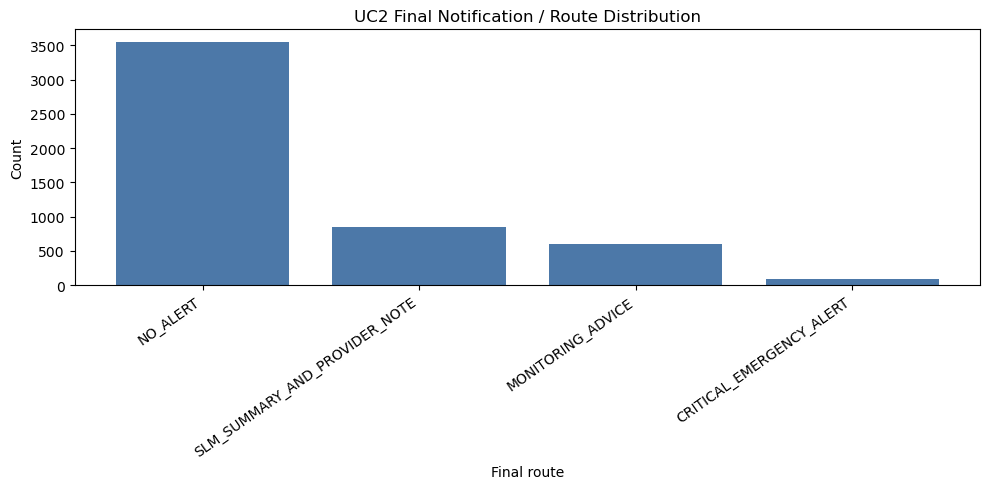

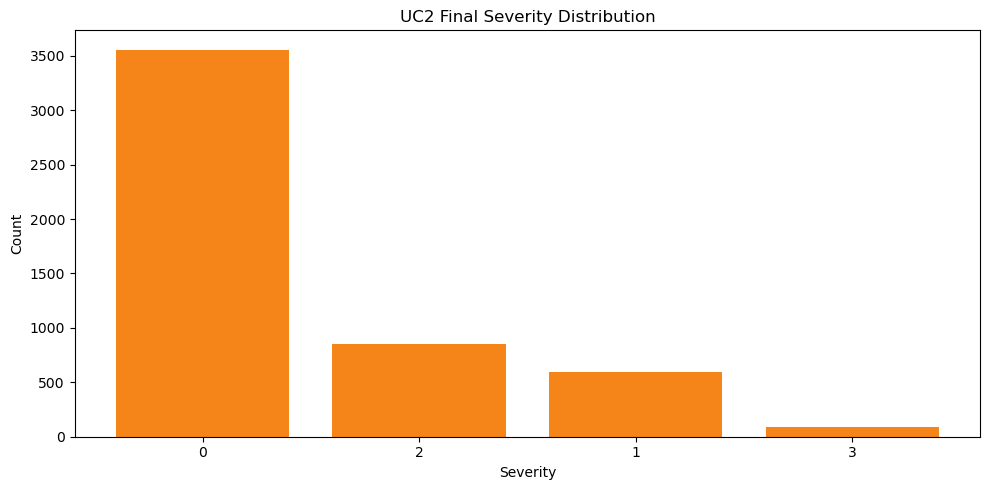

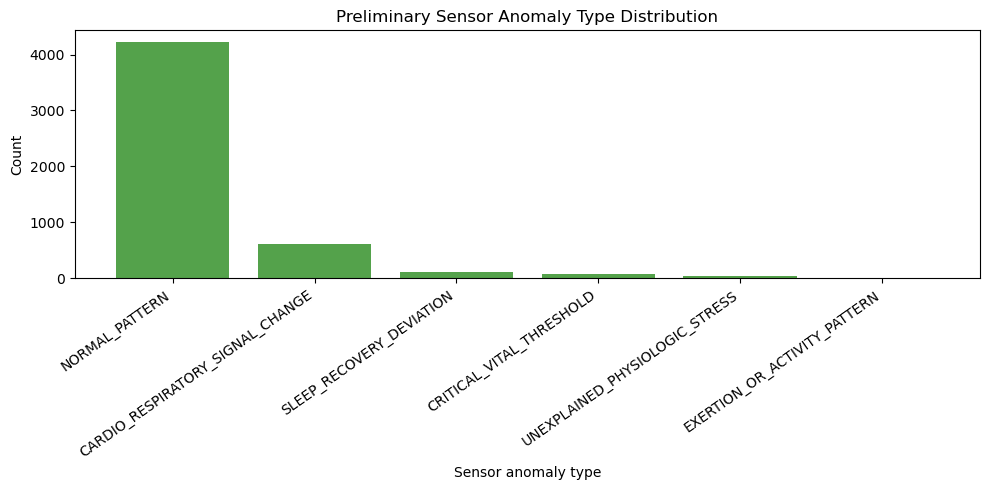

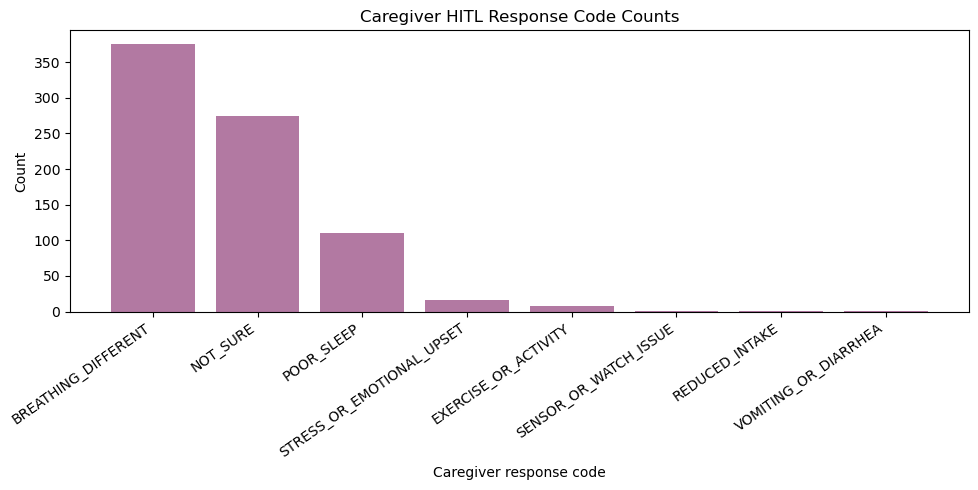

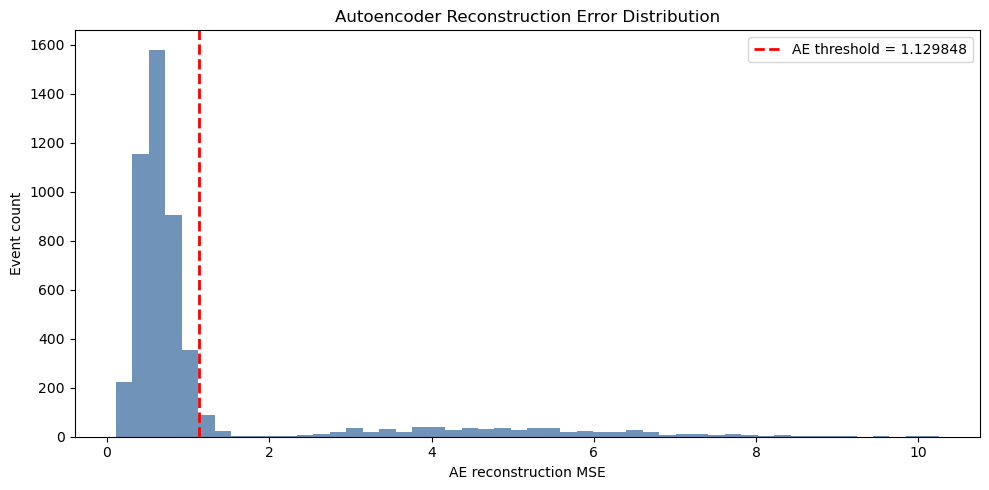

C:\Users\jaymo\AppData\Local\Temp\ipykernel_47616\3397465534.py:612: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


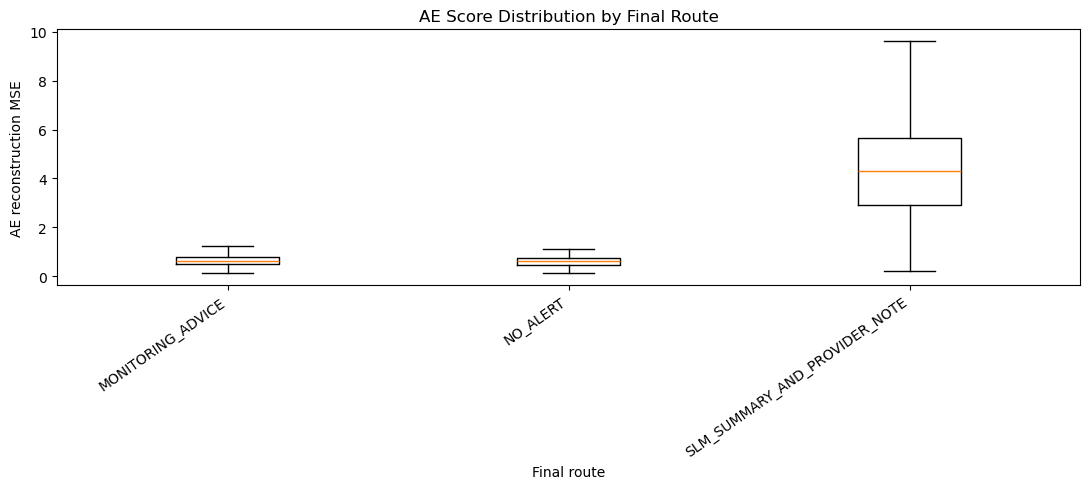

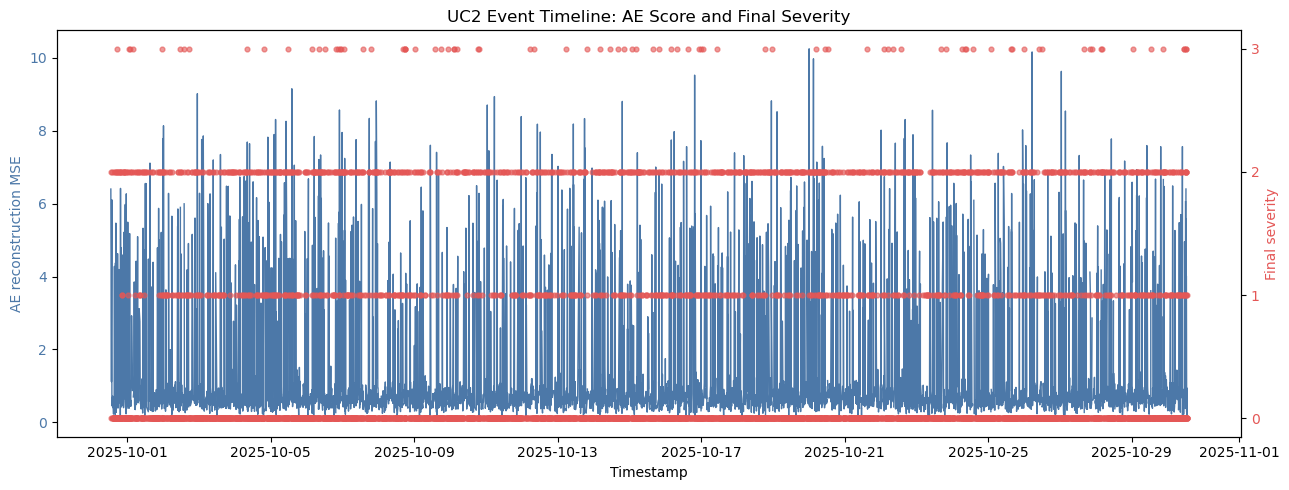

## 14. Top Reconstruction Contributor Frequency

,feature,count_as_top_contributor
0,stress_level,2686
1,sleep_quality,2628
7,calories_burned,2239
6,steps_count,2107
10,heart_rate,2068
2,blood_oxygen,1997
3,glucose_level,1915
5,respiratory_rate,1902
12,body_temperature,1756
4,hrv_sdnn,1641


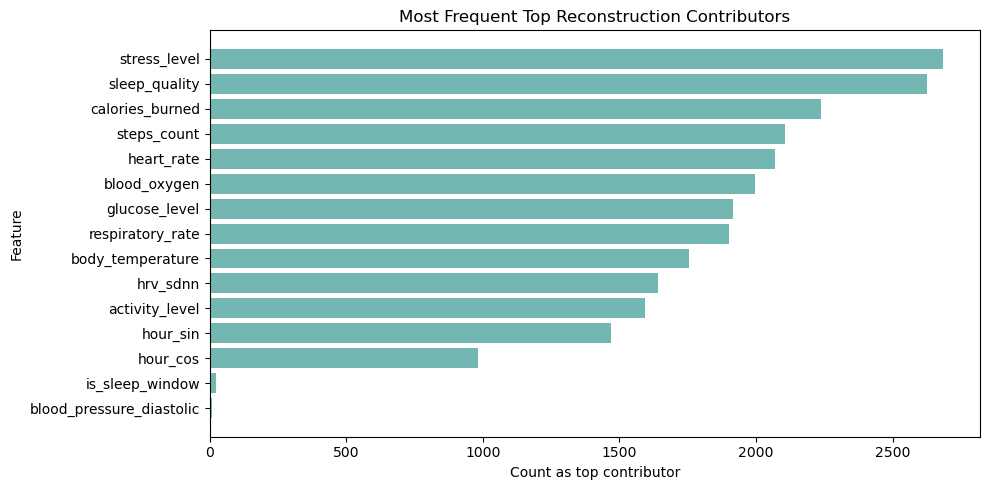

## 15. Emergency Fast Path vs Slow Path

,path,count
0,Emergency Rule Engine Fast Path,0
1,ML/HITL Slow Path,5094


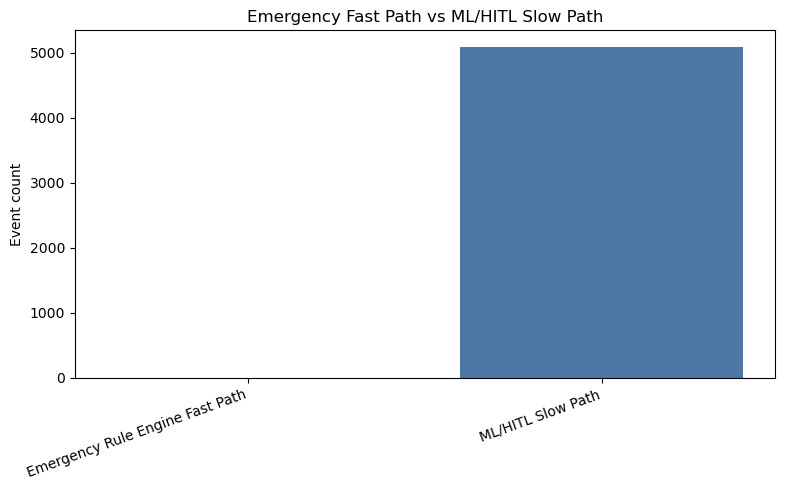

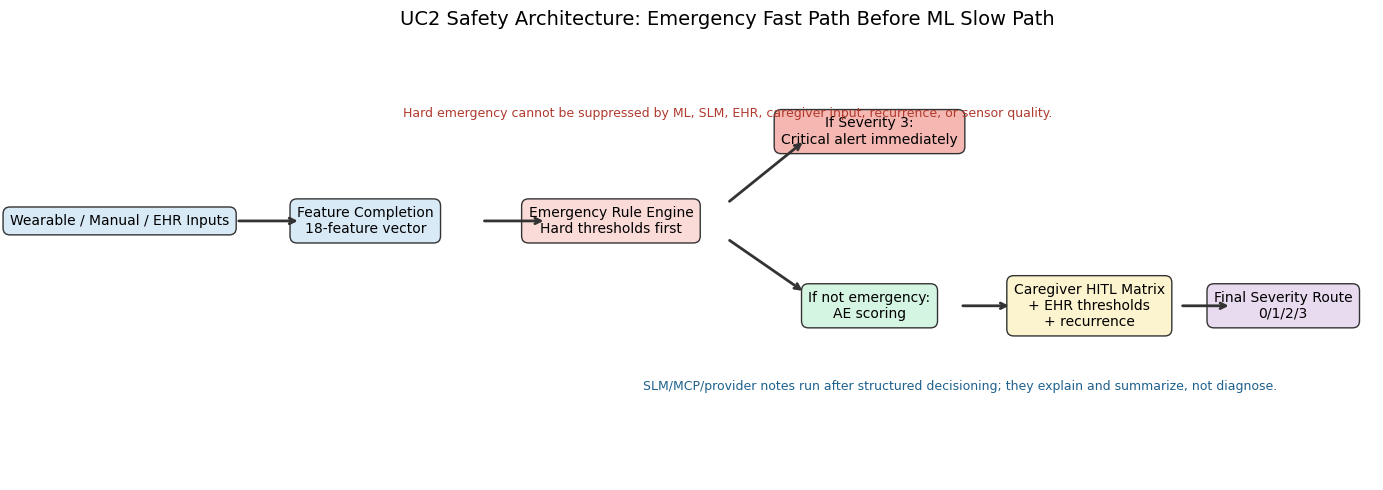

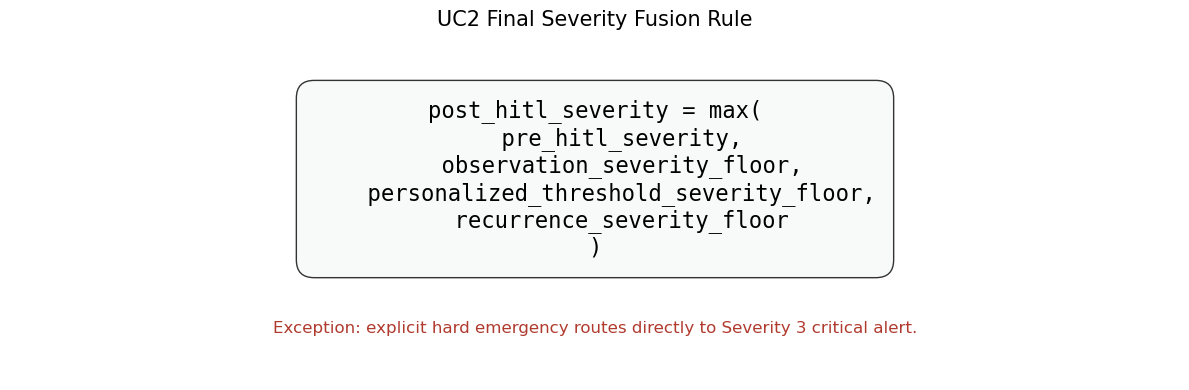

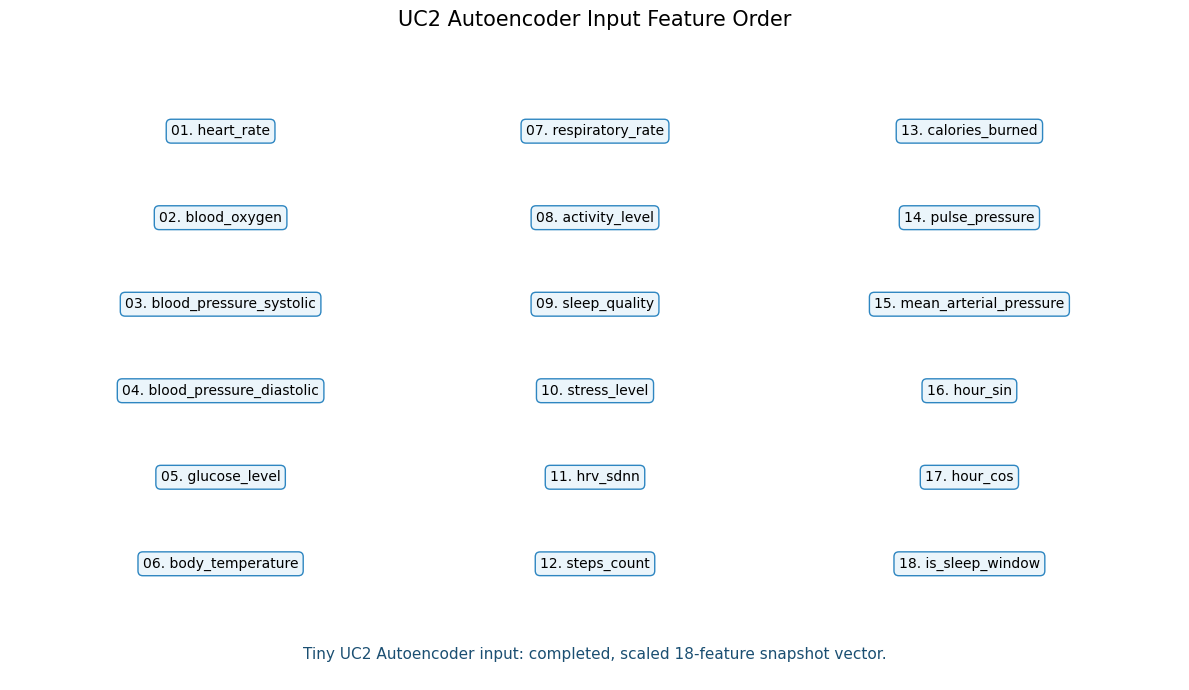

## 16. Clinician/Caregiver-Facing Route Meaning

,severity,route,meaning
0,0,NO_ALERT / DISMISSED_WITH_AUDIT,No immediate caregiver alert. Event may still ...
1,1,MONITORING_ADVICE,Low-level early-warning support. Caregiver rec...
2,2,SLM_SUMMARY_AND_PROVIDER_NOTE,Provider review or follow-up recommended. SLM ...
3,3,CRITICAL_EMERGENCY_ALERT,Hard emergency or urgent matrix-confirmed risk...


## 18. Presentation Asset Index

,asset,use
0,01_final_notification_route_distribution.png,"Show final routing behavior: no alert, monitor..."
1,02_final_severity_distribution.png,Show conservative severity spread across 0/1/2/3.
2,05_ae_score_histogram_with_threshold.png,Validate AE reconstruction error and threshold...
3,07_timeline_ae_score_and_severity.png,Show near-real-time/event-level scoring and ro...
4,08_top_reconstruction_contributors.png,Explain which input features most often drive ...
5,09_fast_path_vs_slow_path.png,Show emergency Rule Engine bypass vs ML slow p...
6,10_pipeline_diagram_emergency_before_ml.png,Main architecture slide: hard emergency before...
7,11_final_severity_formula.png,Show final severity fusion rule.
8,12_ae_18_feature_input_order.png,Show exact 18-feature model input vector.



Done.
Saved tables and figures to: C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\USE_CASE_2\uc2_enhanced_decision_layer_outputs\figures
Recommended slide visuals:
  - 10_pipeline_diagram_emergency_before_ml.png
  - 11_final_severity_formula.png
  - 05_ae_score_histogram_with_threshold.png
  - 07_timeline_ae_score_and_severity.png
  - 09_fast_path_vs_slow_path.png
  - 12_ae_18_feature_input_order.png


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ UC2 Enhanced Decision Layer — Validation Tables, Graphs, and Diagrams       ║
# ║ Purpose: Model validation + clinician/caregiver-facing presentation visuals ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional display styling for notebooks
try:
    from IPython.display import display, Markdown
    HAS_IPYTHON = True
except Exception:
    HAS_IPYTHON = False

# 1. Load enhanced decision-layer outputs

OUTPUT_DIR = Path("uc2_enhanced_decision_layer_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EVENTS_CSV = OUTPUT_DIR / "uc2_enhanced_decision_events.csv"
SUMMARY_JSON = OUTPUT_DIR / "uc2_enhanced_summary.json"

if not EVENTS_CSV.exists():
    raise FileNotFoundError(
        f"Could not find {EVENTS_CSV}. "
        "Run uc2_enhanced_decision_layer_python.py first."
    )

events_df = pd.read_csv(EVENTS_CSV)

summary = {}
if SUMMARY_JSON.exists():
    with open(SUMMARY_JSON, "r", encoding="utf-8") as f:
        summary = json.load(f)

print("Loaded UC2 enhanced decision events:", events_df.shape)
print("Figures will be saved to:", FIG_DIR.resolve())

# 2. Helpers for robust column handling

def find_col(df, candidates):
    """
    Return the first column that exists from a candidate list.
    """
    for c in candidates:
        if c in df.columns:
            return c
    return None

def safe_parse_list_or_dict(x):
    """
    Parse JSON-like or Python-literal strings from CSV columns.
    Handles lists, dicts, empty strings, NaN.
    """
    if pd.isna(x):
        return None

    if isinstance(x, (list, dict)):
        return x

    if not isinstance(x, str):
        return x

    s = x.strip()
    if s == "":
        return None

    try:
        return json.loads(s)
    except Exception:
        pass

    try:
        return ast.literal_eval(s)
    except Exception:
        return s

def value_counts_table(df, col, title=None):
    """
    Create count and percent table for one column.
    """
    if col is None or col not in df.columns:
        return pd.DataFrame()

    vc = df[col].fillna("MISSING").astype(str).value_counts(dropna=False)
    out = pd.DataFrame({
        col: vc.index,
        "count": vc.values,
        "percent": np.round((vc.values / max(len(df), 1)) * 100, 2)
    })

    if title and HAS_IPYTHON:
        display(Markdown(f"### {title}"))
        display(out)
    elif title:
        print("\n" + title)
        print(out)

    return out

def save_table_csv(table, filename):
    if table is not None and len(table) > 0:
        table.to_csv(FIG_DIR / filename, index=False)

def make_bar(
    table,
    x_col,
    y_col="count",
    title="",
    xlabel="",
    ylabel="Count",
    filename="bar.png",
    rotate=True,
    color="#4C78A8"
):
    if table is None or len(table) == 0:
        print(f"Skipping {filename}: no data.")
        return

    plt.figure(figsize=(10, 5))
    plt.bar(table[x_col].astype(str), table[y_col], color=color)
    plt.title(title)
    plt.xlabel(xlabel or x_col)
    plt.ylabel(ylabel)
    if rotate:
        plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

# 3. Column discovery

ae_score_col = find_col(events_df, [
    "ae_score",
    "anomaly_score",
    "anomalyScore",
    "reconstruction_error",
    "mse",
])

is_anomaly_col = find_col(events_df, [
    "is_anomaly",
    "isAnomaly",
    "ml_is_anomaly",
])

threshold_col = find_col(events_df, [
    "ae_threshold",
    "anomaly_threshold",
    "threshold",
])

severity_col = find_col(events_df, [
    "post_hitl_severity",
    "final_severity",
    "severity",
])

pre_severity_col = find_col(events_df, [
    "pre_hitl_severity",
    "initial_severity",
])

notification_col = find_col(events_df, [
    "final_route",
    "notificationType",
    "notification_type",
    "notificationLevel",
    "notification_level",
])

sensor_type_col = find_col(events_df, [
    "sensor_anomaly_type",
    "anomalyType",
    "anomaly_type",
])

post_label_col = find_col(events_df, [
    "post_hitl_label",
    "final_anomaly_label",
    "final_label",
])

family_col = find_col(events_df, [
    "anomaly_family",
    "family",
])

emergency_col = find_col(events_df, [
    "is_hard_emergency",
    "hard_emergency",
    "rule_engine_emergency",
    "emergency_fast_path",
])

caregiver_col = find_col(events_df, [
    "caregiverResponses",
    "caregiver_responses",
    "caregiver_codes",
    "caregiver_observations",
])

obs_floor_col = find_col(events_df, [
    "observation_severity_floor",
    "caregiver_observation_floor",
])

personalized_floor_col = find_col(events_df, [
    "personalized_threshold_severity_floor",
    "personalized_floor",
])

recurrence_floor_col = find_col(events_df, [
    "recurrence_severity_floor",
    "recurrence_floor",
])

scenario_col = find_col(events_df, [
    "scenario",
    "synthetic_scenario",
    "ground_truth_scenario",
    "label",
])

patient_col = find_col(events_df, [
    "patient_id",
    "patientId",
    "patient",
])

timestamp_col = find_col(events_df, [
    "timestamp",
    "event_time",
    "created_at",
    "datetime",
    "time",
])

top_features_col = find_col(events_df, [
    "top_reconstruction_features",
    "topFeatures",
    "top_features",
    "top_contributors",
])

print("\nDetected key columns:")
for label, col in {
    "AE score": ae_score_col,
    "AE threshold": threshold_col,
    "is anomaly": is_anomaly_col,
    "severity": severity_col,
    "pre severity": pre_severity_col,
    "notification": notification_col,
    "sensor anomaly type": sensor_type_col,
    "post-HITL label": post_label_col,
    "anomaly family": family_col,
    "emergency": emergency_col,
    "caregiver responses": caregiver_col,
    "observation floor": obs_floor_col,
    "personalized floor": personalized_floor_col,
    "recurrence floor": recurrence_floor_col,
    "scenario": scenario_col,
    "patient": patient_col,
    "timestamp": timestamp_col,
    "top features": top_features_col,
}.items():
    print(f"  {label:24s}: {col}")

# 4. Summary validation tables

if HAS_IPYTHON:
    display(Markdown("# UC2 Enhanced Decision Layer — Validation Summary"))
    display(Markdown(
        "These tables summarize the model score, emergency fast-path, caregiver HITL, "
        "personalized thresholds, recurrence floors, and final routing behavior."
    ))

overview_rows = []

overview_rows.append(("Total events", len(events_df)))

if ae_score_col:
    overview_rows.extend([
        ("AE score mean", round(float(events_df[ae_score_col].mean()), 6)),
        ("AE score median", round(float(events_df[ae_score_col].median()), 6)),
        ("AE score max", round(float(events_df[ae_score_col].max()), 6)),
    ])

if threshold_col:
    overview_rows.append(("AE threshold used", events_df[threshold_col].dropna().unique()[:5].tolist()))
else:
    # Current handoff default
    overview_rows.append(("AE threshold expected", 1.129848))

if is_anomaly_col:
    anomaly_count = int(events_df[is_anomaly_col].fillna(False).astype(bool).sum())
    overview_rows.append(("ML anomaly count", anomaly_count))
    overview_rows.append(("ML anomaly percent", round(100 * anomaly_count / max(len(events_df), 1), 2)))

if emergency_col:
    emergency_count = int(events_df[emergency_col].fillna(False).astype(bool).sum())
    overview_rows.append(("Rule Engine emergency count", emergency_count))
    overview_rows.append(("Rule Engine emergency percent", round(100 * emergency_count / max(len(events_df), 1), 2)))

overview_table = pd.DataFrame(overview_rows, columns=["metric", "value"])

if HAS_IPYTHON:
    display(Markdown("## 1. Overall Run Summary"))
    display(overview_table)
else:
    print("\nOverall Run Summary")
    print(overview_table)

save_table_csv(overview_table, "table_overall_run_summary.csv")

notification_table = value_counts_table(
    events_df,
    notification_col,
    "2. Final Notification / Route Counts"
)
save_table_csv(notification_table, "table_notification_counts.csv")

severity_table = value_counts_table(
    events_df,
    severity_col,
    "3. Final Severity Counts"
)
save_table_csv(severity_table, "table_severity_counts.csv")

sensor_type_table = value_counts_table(
    events_df,
    sensor_type_col,
    "4. Preliminary Sensor Anomaly Type Counts"
)
save_table_csv(sensor_type_table, "table_sensor_anomaly_type_counts.csv")

post_label_table = value_counts_table(
    events_df,
    post_label_col,
    "5. Post-HITL / Final Label Counts"
)
save_table_csv(post_label_table, "table_post_hitl_label_counts.csv")

family_table = value_counts_table(
    events_df,
    family_col,
    "6. Anomaly Family Counts"
)
save_table_csv(family_table, "table_anomaly_family_counts.csv")

# 5. HITL caregiver response summary

caregiver_counts = {}

if caregiver_col and caregiver_col in events_df.columns:
    parsed = events_df[caregiver_col].apply(safe_parse_list_or_dict)

    for item in parsed:
        if item is None:
            continue

        if isinstance(item, str):
            caregiver_counts[item] = caregiver_counts.get(item, 0) + 1

        elif isinstance(item, list):
            for code in item:
                if isinstance(code, dict):
                    code_val = code.get("code") or code.get("value") or str(code)
                else:
                    code_val = str(code)
                caregiver_counts[code_val] = caregiver_counts.get(code_val, 0) + 1

        elif isinstance(item, dict):
            # Try common shapes
            if "codes" in item and isinstance(item["codes"], list):
                for code in item["codes"]:
                    caregiver_counts[str(code)] = caregiver_counts.get(str(code), 0) + 1
            elif "code" in item:
                code_val = str(item["code"])
                caregiver_counts[code_val] = caregiver_counts.get(code_val, 0) + 1
            else:
                caregiver_counts[str(item)] = caregiver_counts.get(str(item), 0) + 1

caregiver_table = pd.DataFrame(
    [{"caregiver_code": k, "count": v} for k, v in caregiver_counts.items()]
).sort_values("count", ascending=False) if caregiver_counts else pd.DataFrame()

if HAS_IPYTHON:
    display(Markdown("## 7. Caregiver HITL Response Code Counts"))
    if len(caregiver_table):
        display(caregiver_table)
    else:
        display(Markdown("_No caregiver response column detected or no parseable responses._"))

save_table_csv(caregiver_table, "table_caregiver_response_counts.csv")

# 6. Floor contribution tables

floor_cols = [
    c for c in [
        obs_floor_col,
        personalized_floor_col,
        recurrence_floor_col,
        pre_severity_col,
        severity_col
    ]
    if c is not None and c in events_df.columns
]

if floor_cols:
    floor_summary = events_df[floor_cols].describe().T.reset_index().rename(columns={"index": "floor_or_severity"})
    if HAS_IPYTHON:
        display(Markdown("## 8. Severity Floor Summary"))
        display(floor_summary)
    else:
        print("\nSeverity Floor Summary")
        print(floor_summary)

    save_table_csv(floor_summary, "table_severity_floor_summary.csv")

    floor_distribution_rows = []
    for c in floor_cols:
        vc = events_df[c].fillna("MISSING").value_counts().sort_index()
        for level, count in vc.items():
            floor_distribution_rows.append({
                "field": c,
                "level": level,
                "count": count,
                "percent": round(100 * count / max(len(events_df), 1), 2)
            })

    floor_distribution_table = pd.DataFrame(floor_distribution_rows)

    if HAS_IPYTHON:
        display(Markdown("## 9. Severity Floor Distribution"))
        display(floor_distribution_table)

    save_table_csv(floor_distribution_table, "table_severity_floor_distribution.csv")

# 7. Crosstab validation tables

def make_crosstab(row_col, col_col, title, filename):
    if row_col and col_col and row_col in events_df.columns and col_col in events_df.columns:
        ct = pd.crosstab(
            events_df[row_col].fillna("MISSING"),
            events_df[col_col].fillna("MISSING"),
            margins=True
        )
        if HAS_IPYTHON:
            display(Markdown(f"## {title}"))
            display(ct)
        else:
            print(f"\n{title}")
            print(ct)
        ct.to_csv(FIG_DIR / filename)
        return ct
    return None

route_by_severity = make_crosstab(
    severity_col,
    notification_col,
    "10. Final Route by Severity",
    "table_route_by_severity.csv"
)

route_by_sensor_type = make_crosstab(
    sensor_type_col,
    notification_col,
    "11. Final Route by Preliminary Sensor Anomaly Type",
    "table_route_by_sensor_anomaly_type.csv"
)

route_by_scenario = make_crosstab(
    scenario_col,
    notification_col,
    "12. Final Route by Scenario / Synthetic Label",
    "table_route_by_scenario.csv"
)

severity_by_scenario = make_crosstab(
    scenario_col,
    severity_col,
    "13. Severity by Scenario / Synthetic Label",
    "table_severity_by_scenario.csv"
)

# 8. Presentation plots

make_bar(
    notification_table,
    x_col=notification_col if notification_col else "notification",
    title="UC2 Final Notification / Route Distribution",
    xlabel="Final route",
    filename="01_final_notification_route_distribution.png",
    color="#4C78A8"
)

make_bar(
    severity_table,
    x_col=severity_col if severity_col else "severity",
    title="UC2 Final Severity Distribution",
    xlabel="Severity",
    filename="02_final_severity_distribution.png",
    rotate=False,
    color="#F58518"
)

make_bar(
    sensor_type_table,
    x_col=sensor_type_col if sensor_type_col else "sensor_anomaly_type",
    title="Preliminary Sensor Anomaly Type Distribution",
    xlabel="Sensor anomaly type",
    filename="03_sensor_anomaly_type_distribution.png",
    color="#54A24B"
)

if len(caregiver_table):
    make_bar(
        caregiver_table,
        x_col="caregiver_code",
        title="Caregiver HITL Response Code Counts",
        xlabel="Caregiver response code",
        filename="04_caregiver_hitl_response_counts.png",
        color="#B279A2"
    )

if ae_score_col and ae_score_col in events_df.columns:
    score_values = pd.to_numeric(events_df[ae_score_col], errors="coerce").dropna()

    if threshold_col and threshold_col in events_df.columns:
        threshold_values = pd.to_numeric(events_df[threshold_col], errors="coerce").dropna()
        threshold_value = float(threshold_values.iloc[0]) if len(threshold_values) else 1.129848
    else:
        threshold_value = 1.129848

    plt.figure(figsize=(10, 5))
    plt.hist(score_values, bins=50, color="#4C78A8", alpha=0.8)
    plt.axvline(
        threshold_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"AE threshold = {threshold_value:.6f}"
    )
    plt.title("Autoencoder Reconstruction Error Distribution")
    plt.xlabel("AE reconstruction MSE")
    plt.ylabel("Event count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_ae_score_histogram_with_threshold.png", dpi=200, bbox_inches="tight")
    plt.show()

if ae_score_col and notification_col and ae_score_col in events_df.columns and notification_col in events_df.columns:
    plot_df = events_df[[ae_score_col, notification_col]].copy()
    plot_df[ae_score_col] = pd.to_numeric(plot_df[ae_score_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[ae_score_col])

    groups = [
        g[ae_score_col].values
        for _, g in plot_df.groupby(notification_col)
    ]
    labels = [
        str(name)
        for name, _ in plot_df.groupby(notification_col)
    ]

    if len(groups) > 0:
        plt.figure(figsize=(11, 5))
        plt.boxplot(groups, labels=labels, showfliers=False)
        plt.title("AE Score Distribution by Final Route")
        plt.xlabel("Final route")
        plt.ylabel("AE reconstruction MSE")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "06_ae_score_by_final_route_boxplot.png", dpi=200, bbox_inches="tight")
        plt.show()

if ae_score_col and severity_col and ae_score_col in events_df.columns and severity_col in events_df.columns:
    timeline_df = events_df.copy()

    if timestamp_col and timestamp_col in timeline_df.columns:
        timeline_df["_x_axis"] = pd.to_datetime(timeline_df[timestamp_col], errors="coerce")
        if timeline_df["_x_axis"].isna().all():
            timeline_df["_x_axis"] = np.arange(len(timeline_df))
            x_label = "Event index"
        else:
            x_label = "Timestamp"
            timeline_df = timeline_df.sort_values("_x_axis")
    else:
        timeline_df["_x_axis"] = np.arange(len(timeline_df))
        x_label = "Event index"

    timeline_df[ae_score_col] = pd.to_numeric(timeline_df[ae_score_col], errors="coerce")
    timeline_df[severity_col] = pd.to_numeric(timeline_df[severity_col], errors="coerce")

    fig, ax1 = plt.subplots(figsize=(13, 5))

    ax1.plot(
        timeline_df["_x_axis"],
        timeline_df[ae_score_col],
        color="#4C78A8",
        linewidth=1,
        label="AE score"
    )
    ax1.set_xlabel(x_label)
    ax1.set_ylabel("AE reconstruction MSE", color="#4C78A8")
    ax1.tick_params(axis="y", labelcolor="#4C78A8")

    ax2 = ax1.twinx()
    ax2.scatter(
        timeline_df["_x_axis"],
        timeline_df[severity_col],
        color="#E45756",
        s=12,
        alpha=0.6,
        label="Final severity"
    )
    ax2.set_ylabel("Final severity", color="#E45756")
    ax2.tick_params(axis="y", labelcolor="#E45756")
    ax2.set_yticks([0, 1, 2, 3])

    plt.title("UC2 Event Timeline: AE Score and Final Severity")
    fig.tight_layout()
    plt.savefig(FIG_DIR / "07_timeline_ae_score_and_severity.png", dpi=200, bbox_inches="tight")
    plt.show()

# 9. Top reconstruction contributor chart

feature_counter = {}

if top_features_col and top_features_col in events_df.columns:
    parsed_features = events_df[top_features_col].apply(safe_parse_list_or_dict)

    for item in parsed_features:
        if item is None:
            continue

        # Possible shape:
        # ["heart_rate", "blood_oxygen"] 
        # or [{"feature": "heart_rate", "error": 0.5}, ...]
        # or {"heart_rate": 0.5, "blood_oxygen": 0.3}
        if isinstance(item, list):
            for sub in item:
                if isinstance(sub, dict):
                    feat = (
                        sub.get("feature")
                        or sub.get("name")
                        or sub.get("feature_name")
                        or str(sub)
                    )
                else:
                    feat = str(sub)

                feature_counter[feat] = feature_counter.get(feat, 0) + 1

        elif isinstance(item, dict):
            for key in item.keys():
                feature_counter[str(key)] = feature_counter.get(str(key), 0) + 1

        elif isinstance(item, str):
            feature_counter[item] = feature_counter.get(item, 0) + 1

top_feature_table = pd.DataFrame(
    [{"feature": k, "count_as_top_contributor": v} for k, v in feature_counter.items()]
).sort_values("count_as_top_contributor", ascending=False) if feature_counter else pd.DataFrame()

if HAS_IPYTHON:
    display(Markdown("## 14. Top Reconstruction Contributor Frequency"))
    if len(top_feature_table):
        display(top_feature_table.head(20))
    else:
        display(Markdown("_No parseable top reconstruction feature column detected._"))

save_table_csv(top_feature_table, "table_top_reconstruction_contributors.csv")

if len(top_feature_table):
    plt.figure(figsize=(10, 5))
    plot_top = top_feature_table.head(15)
    plt.barh(
        plot_top["feature"][::-1],
        plot_top["count_as_top_contributor"][::-1],
        color="#72B7B2"
    )
    plt.title("Most Frequent Top Reconstruction Contributors")
    plt.xlabel("Count as top contributor")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "08_top_reconstruction_contributors.png", dpi=200, bbox_inches="tight")
    plt.show()

# 10. Emergency fast-path vs slow-path visual

if emergency_col and emergency_col in events_df.columns:
    emergency_bool = events_df[emergency_col].fillna(False).astype(bool)

    fast_slow_table = pd.DataFrame({
        "path": ["Emergency Rule Engine Fast Path", "ML/HITL Slow Path"],
        "count": [
            int(emergency_bool.sum()),
            int((~emergency_bool).sum())
        ]
    })
else:
    fast_slow_table = pd.DataFrame({
        "path": ["Emergency Rule Engine Fast Path", "ML/HITL Slow Path"],
        "count": [0, len(events_df)]
    })

if HAS_IPYTHON:
    display(Markdown("## 15. Emergency Fast Path vs Slow Path"))
    display(fast_slow_table)

save_table_csv(fast_slow_table, "table_fast_path_vs_slow_path.csv")

plt.figure(figsize=(8, 5))
plt.bar(
    fast_slow_table["path"],
    fast_slow_table["count"],
    color=["#E45756", "#4C78A8"]
)
plt.title("Emergency Fast Path vs ML/HITL Slow Path")
plt.ylabel("Event count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_fast_path_vs_slow_path.png", dpi=200, bbox_inches="tight")
plt.show()

# 11. Pipeline diagram: Emergency Rule Engine before ML

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

boxes = [
    ("Wearable / Manual / EHR Inputs", 0.03, 0.58, "#D9EAF7"),
    ("Feature Completion\n18-feature vector", 0.22, 0.58, "#D9EAF7"),
    ("Emergency Rule Engine\nHard thresholds first", 0.41, 0.58, "#FADBD8"),
    ("If Severity 3:\nCritical alert immediately", 0.61, 0.78, "#F5B7B1"),
    ("If not emergency:\nAE scoring", 0.61, 0.39, "#D5F5E3"),
    ("Caregiver HITL Matrix\n+ EHR thresholds\n+ recurrence", 0.78, 0.39, "#FCF3CF"),
    ("Final Severity Route\n0/1/2/3", 0.93, 0.39, "#E8DAEF"),
]

for text, x, y, color in boxes:
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", facecolor=color, edgecolor="#333333")
    )

def arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=2, color="#333333")
    )

arrow(0.12, 0.58, 0.17, 0.58)
arrow(0.31, 0.58, 0.36, 0.58)
arrow(0.50, 0.62, 0.56, 0.76)
arrow(0.50, 0.54, 0.56, 0.42)
arrow(0.68, 0.39, 0.72, 0.39)
arrow(0.85, 0.39, 0.89, 0.39)

ax.text(
    0.50,
    0.82,
    "Hard emergency cannot be suppressed by ML, SLM, EHR, caregiver input, recurrence, or sensor quality.",
    ha="center",
    va="center",
    fontsize=9,
    color="#B03A2E"
)

ax.text(
    0.68,
    0.21,
    "SLM/MCP/provider notes run after structured decisioning; they explain and summarize, not diagnose.",
    ha="center",
    va="center",
    fontsize=9,
    color="#1F618D"
)

plt.title("UC2 Safety Architecture: Emergency Fast Path Before ML Slow Path", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_pipeline_diagram_emergency_before_ml.png", dpi=200, bbox_inches="tight")
plt.show()

# 12. Final severity formula visual

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

formula_text = (
    "post_hitl_severity = max(\n"
    "    pre_hitl_severity,\n"
    "    observation_severity_floor,\n"
    "    personalized_threshold_severity_floor,\n"
    "    recurrence_severity_floor\n"
    ")"
)

ax.text(
    0.5,
    0.58,
    formula_text,
    ha="center",
    va="center",
    fontsize=16,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.8", facecolor="#F8F9F9", edgecolor="#333333")
)

ax.text(
    0.5,
    0.15,
    "Exception: explicit hard emergency routes directly to Severity 3 critical alert.",
    ha="center",
    va="center",
    fontsize=12,
    color="#B03A2E"
)

plt.title("UC2 Final Severity Fusion Rule", fontsize=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_final_severity_formula.png", dpi=200, bbox_inches="tight")
plt.show()

# 13. 18-feature model input diagram

FEATURE_ORDER = [
    "heart_rate",
    "blood_oxygen",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "glucose_level",
    "body_temperature",
    "respiratory_rate",
    "activity_level",
    "sleep_quality",
    "stress_level",
    "hrv_sdnn",
    "steps_count",
    "calories_burned",
    "pulse_pressure",
    "mean_arterial_pressure",
    "hour_sin",
    "hour_cos",
    "is_sleep_window",
]

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

rows = 6
cols = 3
x_positions = [0.18, 0.50, 0.82]
y_positions = np.linspace(0.85, 0.18, rows)

for i, feat in enumerate(FEATURE_ORDER):
    r = i % rows
    c = i // rows
    ax.text(
        x_positions[c],
        y_positions[r],
        f"{i+1:02d}. {feat}",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#EBF5FB", edgecolor="#2E86C1")
    )

ax.text(
    0.5,
    0.04,
    "Tiny UC2 Autoencoder input: completed, scaled 18-feature snapshot vector.",
    ha="center",
    va="center",
    fontsize=11,
    color="#1B4F72"
)

plt.title("UC2 Autoencoder Input Feature Order", fontsize=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_ae_18_feature_input_order.png", dpi=200, bbox_inches="tight")
plt.show()

# 14. Route meaning table for presentation

route_meanings = pd.DataFrame([
    {
        "severity": 0,
        "route": "NO_ALERT / DISMISSED_WITH_AUDIT",
        "meaning": "No immediate caregiver alert. Event may still be logged for audit."
    },
    {
        "severity": 1,
        "route": "MONITORING_ADVICE",
        "meaning": "Low-level early-warning support. Caregiver receives conservative monitoring guidance."
    },
    {
        "severity": 2,
        "route": "SLM_SUMMARY_AND_PROVIDER_NOTE",
        "meaning": "Provider review or follow-up recommended. SLM summarizes structured evidence; it does not diagnose."
    },
    {
        "severity": 3,
        "route": "CRITICAL_EMERGENCY_ALERT",
        "meaning": "Hard emergency or urgent matrix-confirmed risk. Critical alert is routed immediately."
    },
])

if HAS_IPYTHON:
    display(Markdown("## 16. Clinician/Caregiver-Facing Route Meaning"))
    display(route_meanings)

save_table_csv(route_meanings, "table_route_meanings.csv")

# 15. Optional: synthetic scenario validation if scenario labels exist

if scenario_col and notification_col and scenario_col in events_df.columns:
    scenario_summary = (
        events_df
        .groupby(scenario_col)
        .agg(
            event_count=(scenario_col, "size"),
            avg_severity=(severity_col, "mean") if severity_col else (scenario_col, "size"),
            avg_ae_score=(ae_score_col, "mean") if ae_score_col else (scenario_col, "size"),
        )
        .reset_index()
    )

    if HAS_IPYTHON:
        display(Markdown("## 17. Synthetic Scenario Summary"))
        display(scenario_summary)

    save_table_csv(scenario_summary, "table_synthetic_scenario_summary.csv")

    if severity_col:
        plt.figure(figsize=(10, 5))
        plt.bar(
            scenario_summary[scenario_col].astype(str),
            scenario_summary["avg_severity"],
            color="#E45756"
        )
        plt.title("Average Final Severity by Synthetic Scenario")
        plt.xlabel("Scenario")
        plt.ylabel("Average final severity")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "13_avg_severity_by_synthetic_scenario.png", dpi=200, bbox_inches="tight")
        plt.show()

    if ae_score_col:
        plt.figure(figsize=(10, 5))
        plt.bar(
            scenario_summary[scenario_col].astype(str),
            scenario_summary["avg_ae_score"],
            color="#4C78A8"
        )
        plt.title("Average AE Score by Synthetic Scenario")
        plt.xlabel("Scenario")
        plt.ylabel("Average AE reconstruction MSE")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "14_avg_ae_score_by_synthetic_scenario.png", dpi=200, bbox_inches="tight")
        plt.show()

# 16. Export compact presentation packet

presentation_index = pd.DataFrame([
    {
        "asset": "01_final_notification_route_distribution.png",
        "use": "Show final routing behavior: no alert, monitoring, provider note, emergency."
    },
    {
        "asset": "02_final_severity_distribution.png",
        "use": "Show conservative severity spread across 0/1/2/3."
    },
    {
        "asset": "05_ae_score_histogram_with_threshold.png",
        "use": "Validate AE reconstruction error and threshold separation."
    },
    {
        "asset": "07_timeline_ae_score_and_severity.png",
        "use": "Show near-real-time/event-level scoring and routing over time."
    },
    {
        "asset": "08_top_reconstruction_contributors.png",
        "use": "Explain which input features most often drive reconstruction error."
    },
    {
        "asset": "09_fast_path_vs_slow_path.png",
        "use": "Show emergency Rule Engine bypass vs ML slow path."
    },
    {
        "asset": "10_pipeline_diagram_emergency_before_ml.png",
        "use": "Main architecture slide: hard emergency before ML, SLM/MCP after decision."
    },
    {
        "asset": "11_final_severity_formula.png",
        "use": "Show final severity fusion rule."
    },
    {
        "asset": "12_ae_18_feature_input_order.png",
        "use": "Show exact 18-feature model input vector."
    },
])

presentation_index.to_csv(FIG_DIR / "presentation_asset_index.csv", index=False)

if HAS_IPYTHON:
    display(Markdown("## 18. Presentation Asset Index"))
    display(presentation_index)

print("\nDone.")
print(f"Saved tables and figures to: {FIG_DIR.resolve()}")
print("Recommended slide visuals:")
print("  - 10_pipeline_diagram_emergency_before_ml.png")
print("  - 11_final_severity_formula.png")
print("  - 05_ae_score_histogram_with_threshold.png")
print("  - 07_timeline_ae_score_and_severity.png")
print("  - 09_fast_path_vs_slow_path.png")
print("  - 12_ae_18_feature_input_order.png")

In [6]:
normal_alerts = events_df[
    (events_df["sensor_anomaly_type"] == "NORMAL_PATTERN")
    & (events_df["notificationType"] != "NO_ALERT")
]

display(normal_alerts[[
    "patient_id",
    "timestamp",
    "anomalyScore",
    "isAnomaly",
    "sensor_anomaly_type",
    "anomaly_family",
    "pre_hitl_severity",
    "observation_severity_floor",
    "personalized_threshold_severity_floor",
    "recurrence_severity_floor",
    "post_hitl_severity",
    "notificationType",
    "caregiverResponses",
    "topFeatures"
]].head(25))

print(normal_alerts["notificationType"].value_counts())
print(normal_alerts[[
    "observation_severity_floor",
    "personalized_threshold_severity_floor",
    "recurrence_severity_floor"
]].max())

,patient_id,timestamp,anomalyScore,isAnomaly,sensor_anomaly_type,anomaly_family,pre_hitl_severity,observation_severity_floor,personalized_threshold_severity_floor,recurrence_severity_floor,post_hitl_severity,notificationType,caregiverResponses,topFeatures
50,PATIENT_0452,2025-09-30T20:14:45.056387,1.016378,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""steps_count"", ""contribution"": 2...."
53,PATIENT_0268,2025-09-30T20:50:45.056387,0.520234,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""steps_count"", ""contribution"": 1...."
81,PATIENT_0268,2025-10-01T00:35:45.056387,0.947198,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""glucose_level"", ""contribution"": ..."
112,PATIENT_0475,2025-10-01T05:11:45.056387,0.744231,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""calories_burned"", ""contribution""..."
126,PATIENT_0417,2025-10-01T07:47:45.056387,0.592544,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""activity_level"", ""contribution"":..."
129,PATIENT_0052,2025-10-01T08:47:45.056387,0.623580,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""calories_burned"", ""contribution""..."
130,PATIENT_0452,2025-10-01T08:52:45.056387,0.576178,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""hour_sin"", ""contribution"": 2.716..."
146,PATIENT_0079,2025-10-01T11:19:45.056387,0.523048,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""sleep_quality"", ""contribution"": ..."
194,PATIENT_0414,2025-10-01T21:07:45.056387,1.025371,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""heart_rate"", ""contribution"": 2.3..."
203,PATIENT_0483,2025-10-01T22:55:45.056387,0.711799,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,0,0,1,1,MONITORING_ADVICE,[],"[{""feature"": ""sleep_quality"", ""contribution"": ..."


notificationType
MONITORING_ADVICE                591
SLM_SUMMARY_AND_PROVIDER_NOTE     74
Name: count, dtype: int64
observation_severity_floor               0
personalized_threshold_severity_floor    1
recurrence_severity_floor                2
dtype: int64


In [8]:
import ast, json
from collections import Counter

def parse_top_features(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x)
    try:
        v = json.loads(s)
    except Exception:
        try:
            v = ast.literal_eval(s)
        except Exception:
            return [s]
    if isinstance(v, list):
        out = []
        for item in v:
            if isinstance(item, dict):
                out.append(item.get("feature") or item.get("name") or str(item))
            else:
                out.append(str(item))
        return out
    if isinstance(v, dict):
        return list(v.keys())
    return [str(v)]

for anomaly_type in events_df["sensor_anomaly_type"].unique():
    sub = events_df[events_df["sensor_anomaly_type"] == anomaly_type]
    counter = Counter()
    for x in sub["topFeatures"]:
        counter.update(parse_top_features(x))
    print("\n", anomaly_type)
    print(counter.most_common(10))


 CARDIO_RESPIRATORY_SIGNAL_CHANGE
[('stress_level', 560), ('sleep_quality', 497), ('heart_rate', 405), ('blood_oxygen', 322), ('hrv_sdnn', 304), ('respiratory_rate', 265), ('glucose_level', 246), ('body_temperature', 126), ('steps_count', 124), ('calories_burned', 103)]

 NORMAL_PATTERN
[('calories_burned', 2065), ('sleep_quality', 2000), ('stress_level', 1970), ('steps_count', 1889), ('blood_oxygen', 1665), ('heart_rate', 1639), ('respiratory_rate', 1612), ('body_temperature', 1582), ('glucose_level', 1519), ('activity_level', 1452)]

 CRITICAL_VITAL_THRESHOLD
[]

 UNEXPLAINED_PHYSIOLOGIC_STRESS
[('stress_level', 47), ('glucose_level', 45), ('steps_count', 34), ('calories_burned', 29), ('sleep_quality', 23), ('activity_level', 20), ('body_temperature', 18), ('heart_rate', 9), ('respiratory_rate', 7), ('hrv_sdnn', 6)]

 SLEEP_RECOVERY_DEVIATION
[('stress_level', 109), ('sleep_quality', 108), ('glucose_level', 101), ('steps_count', 58), ('calories_burned', 39), ('activity_level', 34), 

,sensor_anomaly_type,feature_group,count
1,CARDIO_RESPIRATORY_SIGNAL_CHANGE,cardio_respiratory,1296
3,CARDIO_RESPIRATORY_SIGNAL_CHANGE,sleep_recovery_autonomic,1062
2,CARDIO_RESPIRATORY_SIGNAL_CHANGE,metabolic_temperature,372
0,CARDIO_RESPIRATORY_SIGNAL_CHANGE,activity_exertion,313
4,CARDIO_RESPIRATORY_SIGNAL_CHANGE,time_context,72
5,EXERTION_OR_ACTIVITY_PATTERN,activity_exertion,8
7,EXERTION_OR_ACTIVITY_PATTERN,metabolic_temperature,8
6,EXERTION_OR_ACTIVITY_PATTERN,cardio_respiratory,3
8,EXERTION_OR_ACTIVITY_PATTERN,time_context,1
10,NORMAL_PATTERN,cardio_respiratory,985


feature_group,activity_exertion,cardio_respiratory,metabolic_temperature,sleep_recovery_autonomic,time_context
sensor_anomaly_type,,,,,
CARDIO_RESPIRATORY_SIGNAL_CHANGE,313.0,1296.0,372.0,1062.0,72.0
EXERTION_OR_ACTIVITY_PATTERN,8.0,3.0,8.0,0.0,1.0
NORMAL_PATTERN,871.0,985.0,482.0,617.0,370.0
SLEEP_RECOVERY_DEVIATION,131.0,64.0,127.0,217.0,11.0
UNEXPLAINED_PHYSIOLOGIC_STRESS,83.0,27.0,63.0,70.0,2.0


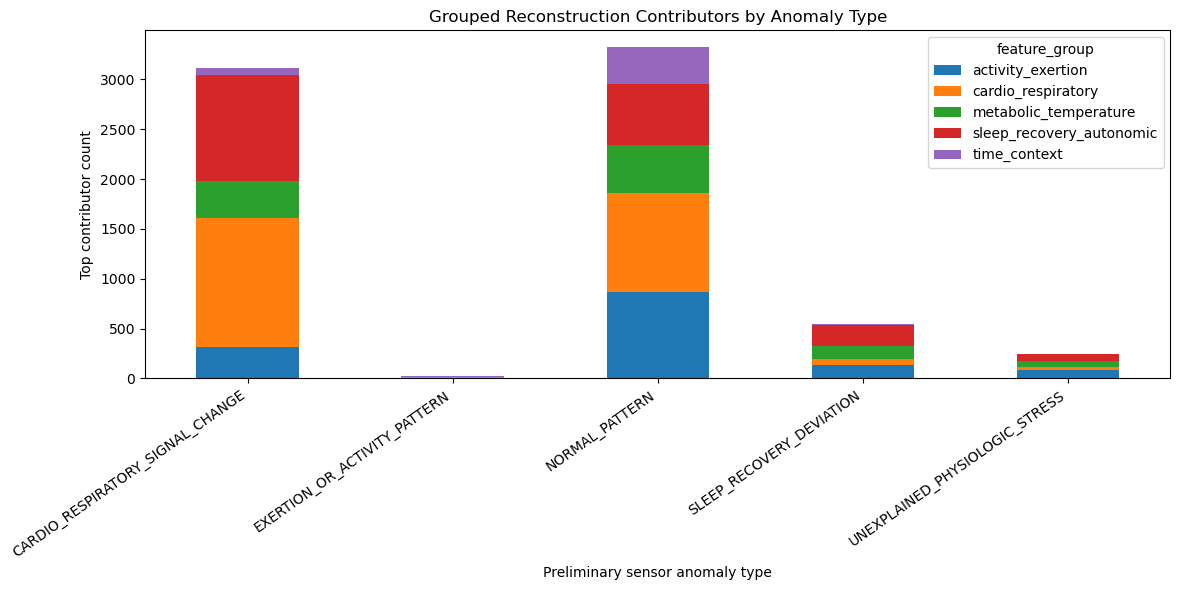

In [10]:

import ast
import json
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

FEATURE_GROUPS = {
    "cardio_respiratory": {
        "heart_rate",
        "blood_oxygen",
        "respiratory_rate",
        "hrv_sdnn",
        "pulse_pressure",
        "mean_arterial_pressure",
        "blood_pressure_systolic",
        "blood_pressure_diastolic",
    },
    "sleep_recovery_autonomic": {
        "sleep_quality",
        "stress_level",
        "hrv_sdnn",
        "is_sleep_window",
    },
    "activity_exertion": {
        "activity_level",
        "steps_count",
        "calories_burned",
    },
    "metabolic_temperature": {
        "glucose_level",
        "body_temperature",
    },
    "time_context": {
        "hour_sin",
        "hour_cos",
        "is_sleep_window",
    },
}

def feature_to_group(feature):
    for group, features in FEATURE_GROUPS.items():
        if feature in features:
            return group
    return "other"

def parse_top_features(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        raw = x
    else:
        s = str(x).strip()
        if not s:
            return []
        try:
            raw = json.loads(s)
        except Exception:
            try:
                raw = ast.literal_eval(s)
            except Exception:
                return [s]

    if isinstance(raw, dict):
        return list(raw.keys())

    if isinstance(raw, list):
        out = []
        for item in raw:
            if isinstance(item, dict):
                out.append(
                    item.get("feature")
                    or item.get("name")
                    or item.get("feature_name")
                    or str(item)
                )
            else:
                out.append(str(item))
        return out

    return [str(raw)]

rows = []

# Focus on non-normal or alerted events
analysis_df = events_df[
    (events_df["sensor_anomaly_type"] != "NORMAL_PATTERN")
    | (events_df["post_hitl_severity"] > 0)
].copy()

for _, row in analysis_df.iterrows():
    anomaly_type = row["sensor_anomaly_type"]
    features = parse_top_features(row["topFeatures"])

    for feature in features:
        rows.append({
            "sensor_anomaly_type": anomaly_type,
            "feature": feature,
            "feature_group": feature_to_group(feature),
        })

group_df = pd.DataFrame(rows)

group_counts = (
    group_df
    .groupby(["sensor_anomaly_type", "feature_group"])
    .size()
    .reset_index(name="count")
    .sort_values(["sensor_anomaly_type", "count"], ascending=[True, False])
)

display(group_counts)

# Pivot table for presentation
pivot = group_counts.pivot_table(
    index="sensor_anomaly_type",
    columns="feature_group",
    values="count",
    fill_value=0
)

display(pivot)

# Stacked bar chart
pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Grouped Reconstruction Contributors by Anomaly Type")
plt.xlabel("Preliminary sensor anomaly type")
plt.ylabel("Top contributor count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Loaded events: (5094, 72)
Figures will be saved to: C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\USE_CASE_2\uc2_enhanced_decision_layer_outputs\figures\patient_pipeline

Detected columns:
  patient_col                 : patient_id
  ae_score_col                : anomalyScore
  pre_sev_col                 : pre_hitl_severity
  obs_floor_col               : observation_severity_floor
  personalized_floor_col      : personalized_threshold_severity_floor
  recurrence_floor_col        : recurrence_severity_floor
  post_sev_col                : post_hitl_severity
  notification_col            : notificationType

Selected patient: PATIENT_0491


## Selected Patient Summary

,patient_id,event_count,alert_count,max_severity,ml_anomaly_count,emergency_count,obs_floor_max,personalized_floor_max,recurrence_floor_max,ae_score_max,interest_score
490,PATIENT_0491,18,11,3,4,2,2,2,2,8.026072,86
146,PATIENT_0147,14,7,3,1,3,2,2,2,5.481882,80
92,PATIENT_0093,15,9,3,5,1,2,2,2,5.574045,78
49,PATIENT_0050,14,9,3,4,1,2,2,2,6.683394,77
398,PATIENT_0399,14,6,3,2,2,2,2,2,7.730448,74
437,PATIENT_0438,13,9,3,3,1,2,2,1,4.564412,73
217,PATIENT_0218,15,5,3,2,2,2,2,2,6.714748,72
216,PATIENT_0217,16,9,3,2,1,2,2,1,4.096120,72
56,PATIENT_0057,10,7,3,3,1,2,2,2,7.844815,72
20,PATIENT_0021,12,6,3,2,2,2,2,1,4.907625,71



Selected event numbers for detailed pipeline:
[1, 9, 7, 6]


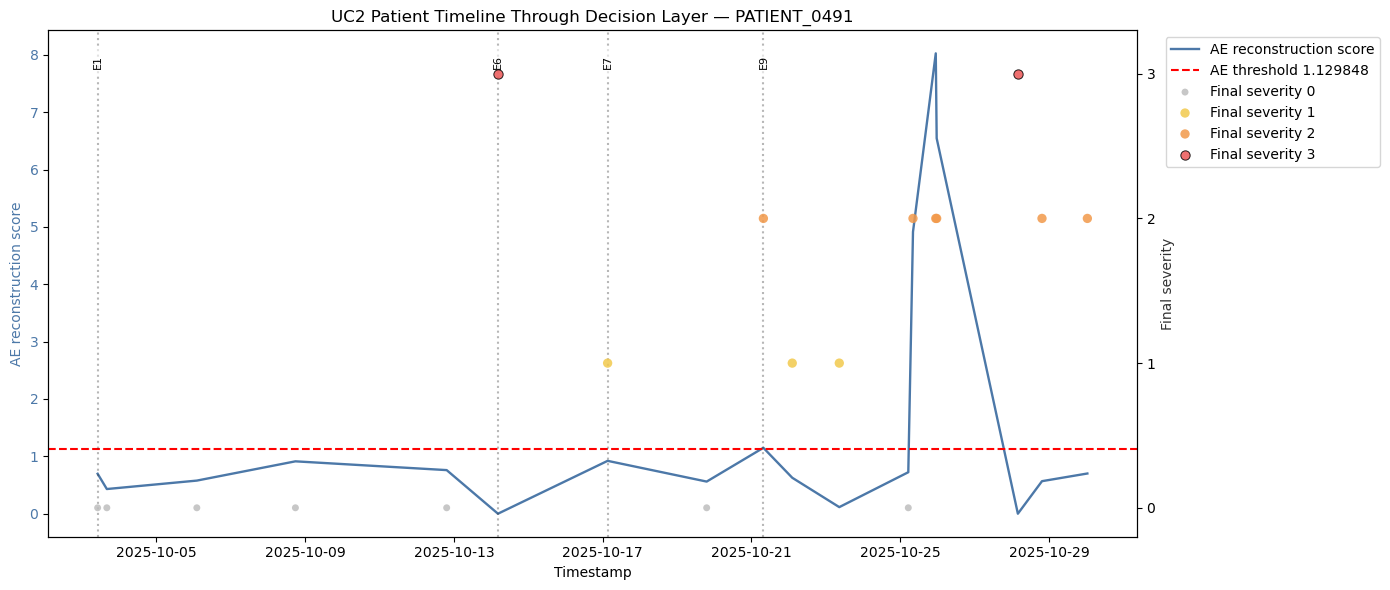

## Detailed Single-Patient Decision Pipeline Events

,event,timestamp,AE_score,ML_anomaly,emergency_rule,sensor_anomaly_type,anomaly_family,pre_HITL_severity,caregiver_responses,observation_floor,personalized_floor,recurrence_floor,final_severity,notification,main_reason,top_features
0,E1,2025-10-03T10:04:45.056387,0.6964,False,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,,0,0,0,0,NO_ALERT,No alert after decision fusion,"{'feature': 'glucose_level', 'contribution': 3..."
1,E9,2025-10-21T07:42:45.056387,1.1488,True,False,CARDIO_RESPIRATORY_SIGNAL_CHANGE,CARDIO_RESPIRATORY,1,NOT_SURE,2,0,0,2,SLM_SUMMARY_AND_PROVIDER_NOTE,Severity raised by caregiver HITL,"{'feature': 'glucose_level', 'contribution': 4..."
2,E7,2025-10-17T03:11:45.056387,0.9216,False,False,NORMAL_PATTERN,NORMAL_OR_UNKNOWN,0,,0,0,1,1,MONITORING_ADVICE,Severity raised by recurrence,"{'feature': 'body_temperature', 'contribution'..."
3,E6,2025-10-14T04:25:45.056387,0.0000,False,True,CRITICAL_VITAL_THRESHOLD,CRITICAL_VITAL,3,,2,2,0,3,CRITICAL_EMERGENCY_ALERT,Hard emergency threshold route,


C:\Users\jaymo\AppData\Local\Temp\ipykernel_47616\1763216688.py:511: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


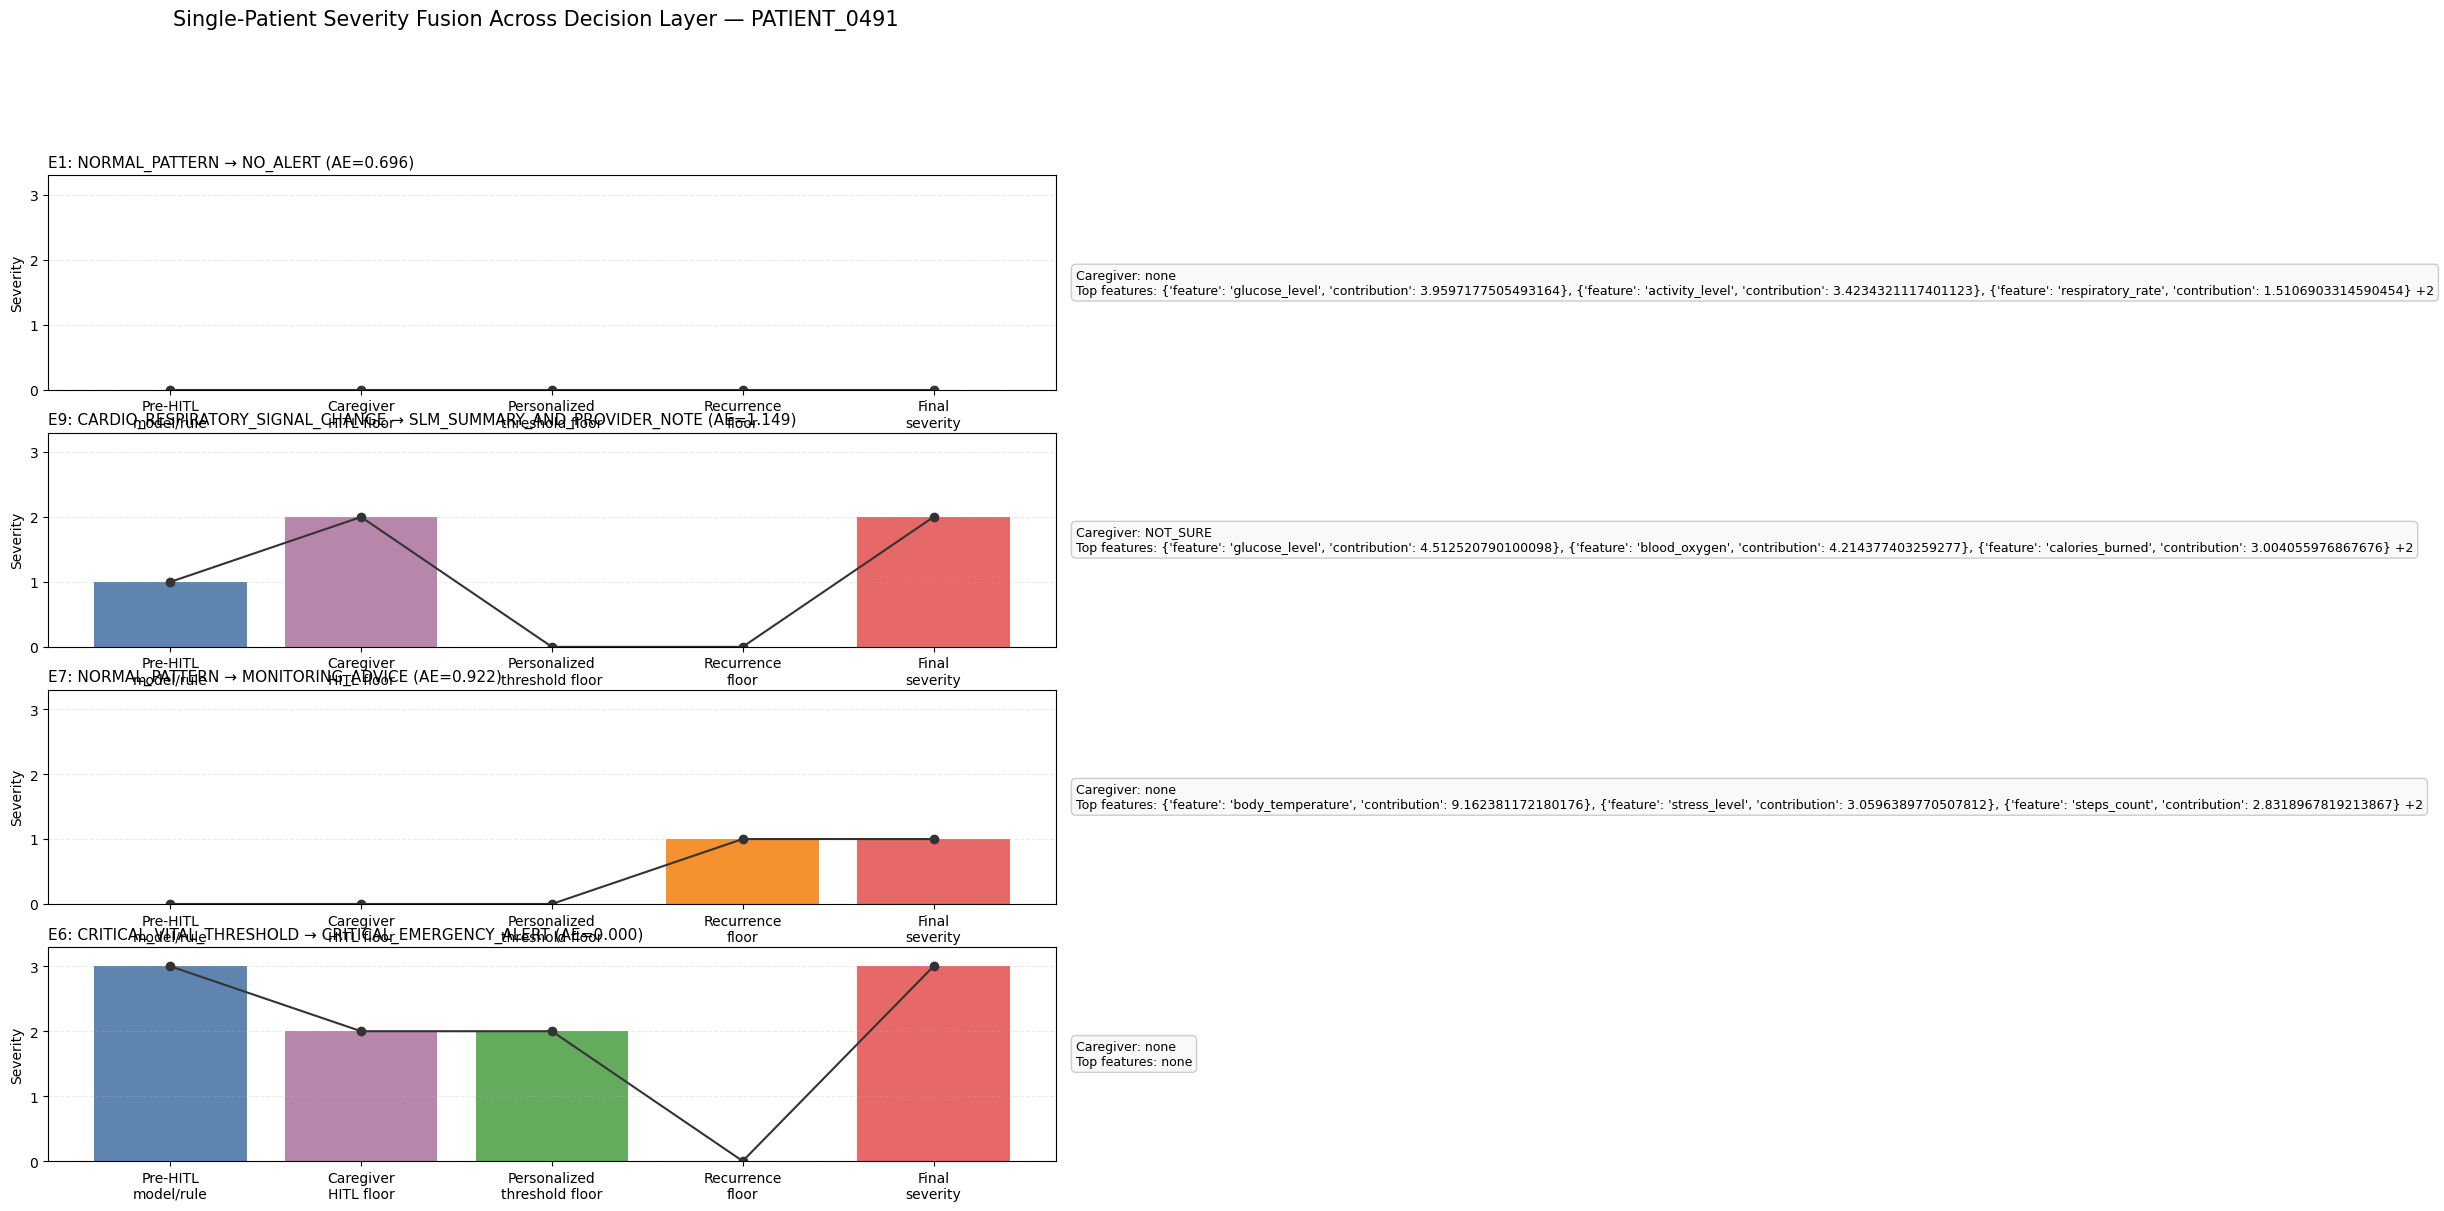

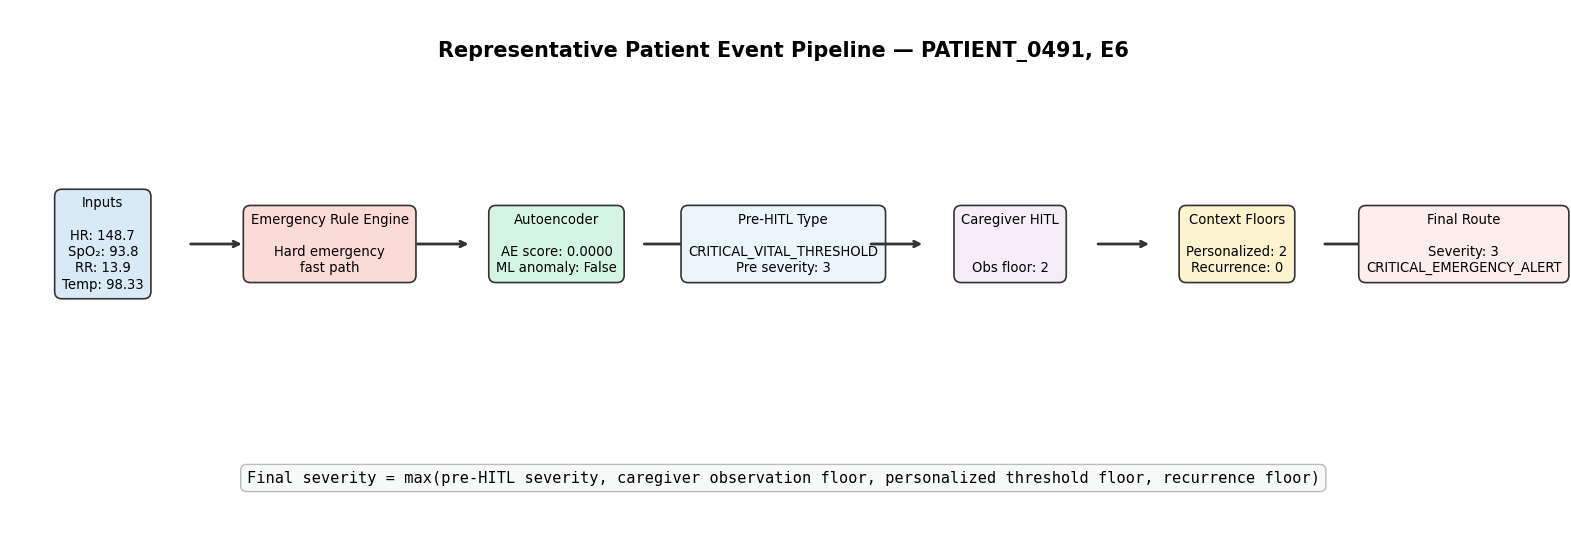

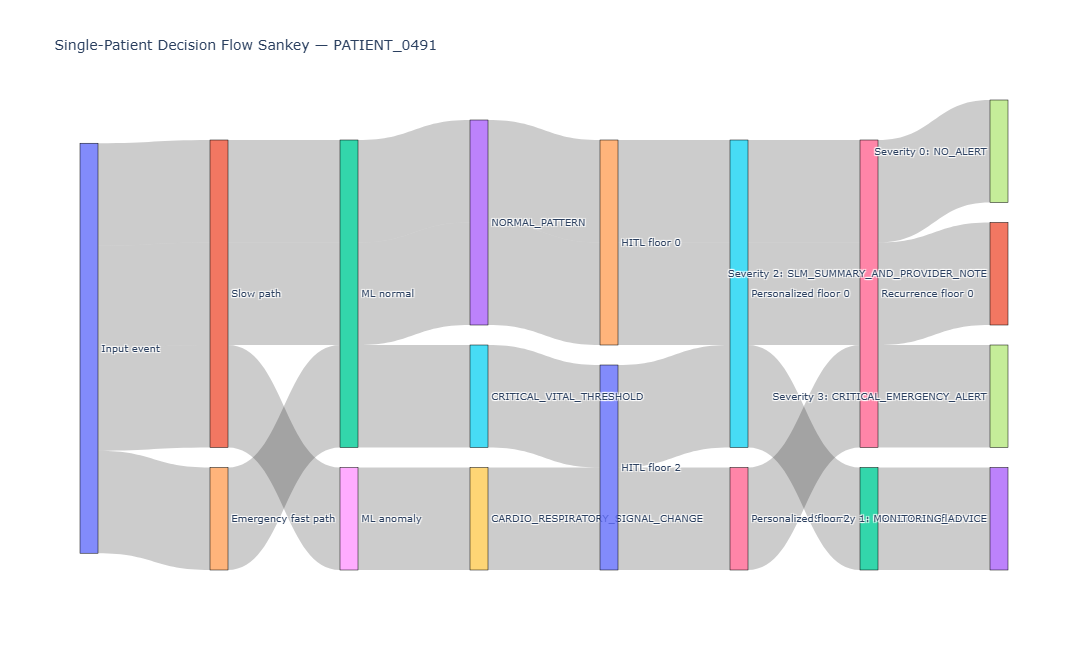

Saved Plotly Sankey HTML.

Done.
Saved:
 - 01_single_patient_timeline_ae_score_and_severity.png
 - 02_single_patient_severity_fusion_ladder.png
 - 03_representative_event_full_pipeline_diagram.png
 - single_patient_pipeline_selected_events.csv
 - single_patient_all_events.csv
 - Optional: 04_single_patient_decision_flow_sankey.html


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ UC2 Single-Patient Full Decision Layer Pipeline Visualization               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
    HAS_IPYTHON = True
except Exception:
    HAS_IPYTHON = False

# 1. Setup

OUTPUT_DIR = Path("uc2_enhanced_decision_layer_outputs")
FIG_DIR = OUTPUT_DIR / "figures" / "patient_pipeline"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if "events_df" not in globals():
    EVENTS_CSV = OUTPUT_DIR / "uc2_enhanced_decision_events.csv"
    events_df = pd.read_csv(EVENTS_CSV)

df = events_df.copy()

print("Loaded events:", df.shape)
print("Figures will be saved to:", FIG_DIR.resolve())

# 2. Helper functions

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def parse_codes(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    if not s:
        return []
    try:
        parsed = json.loads(s)
    except Exception:
        try:
            parsed = ast.literal_eval(s)
        except Exception:
            return [s]

    if isinstance(parsed, list):
        return [str(v) for v in parsed]
    if isinstance(parsed, dict):
        if "codes" in parsed and isinstance(parsed["codes"], list):
            return [str(v) for v in parsed["codes"]]
        if "code" in parsed:
            return [str(parsed["code"])]
        return [str(parsed)]
    return [str(parsed)]

def short_list(x, max_items=3):
    vals = parse_codes(x)
    if not vals:
        return ""
    if len(vals) <= max_items:
        return ", ".join(vals)
    return ", ".join(vals[:max_items]) + f" +{len(vals)-max_items}"

def safe_numeric(series, default=0):
    return pd.to_numeric(series, errors="coerce").fillna(default)

# 3. Detect columns

patient_col = find_col(df, ["patient_id", "patientId", "patient"])
timestamp_col = find_col(df, ["timestamp", "event_time", "created_at", "datetime", "time"])

ae_score_col = find_col(df, ["anomalyScore", "ae_score", "anomaly_score", "reconstruction_error", "mse"])
is_anomaly_col = find_col(df, ["isAnomaly", "is_anomaly", "ml_is_anomaly"])

sensor_type_col = find_col(df, ["sensor_anomaly_type", "anomalyType", "anomaly_type"])
family_col = find_col(df, ["anomaly_family", "family"])

pre_sev_col = find_col(df, ["pre_hitl_severity", "initial_severity"])
obs_floor_col = find_col(df, ["observation_severity_floor", "caregiver_observation_floor"])
personalized_floor_col = find_col(df, ["personalized_threshold_severity_floor", "personalized_floor"])
recurrence_floor_col = find_col(df, ["recurrence_severity_floor", "recurrence_floor"])
post_sev_col = find_col(df, ["post_hitl_severity", "final_severity", "severity"])

notification_col = find_col(df, ["notificationType", "final_route", "notification_type", "notificationLevel"])
caregiver_col = find_col(df, ["caregiverResponses", "caregiver_responses", "caregiver_codes"])
top_features_col = find_col(df, ["topFeatures", "top_reconstruction_features", "top_features"])

emergency_col = find_col(df, ["is_hard_emergency", "hard_emergency", "rule_engine_emergency", "emergency_fast_path"])

vital_cols = [
    c for c in [
        "heart_rate",
        "blood_oxygen",
        "respiratory_rate",
        "body_temperature",
        "blood_pressure_systolic",
        "blood_pressure_diastolic",
        "hrv_sdnn",
        "sleep_quality",
        "stress_level",
        "steps_count",
        "calories_burned",
    ]
    if c in df.columns
]

required = {
    "patient_col": patient_col,
    "ae_score_col": ae_score_col,
    "pre_sev_col": pre_sev_col,
    "obs_floor_col": obs_floor_col,
    "personalized_floor_col": personalized_floor_col,
    "recurrence_floor_col": recurrence_floor_col,
    "post_sev_col": post_sev_col,
    "notification_col": notification_col,
}

print("\nDetected columns:")
for k, v in required.items():
    print(f"  {k:28s}: {v}")

missing_required = [k for k, v in required.items() if v is None]
if missing_required:
    raise ValueError(f"Missing required columns for this visualization: {missing_required}")

# 4. Select one interesting patient
# Strategy:
# Pick patient with the most varied / interesting route history:
#   high count of alerts + high max severity + has ML anomaly + has HITL floors.

if patient_col is None:
    df["_patient_tmp"] = "patient_001"
    patient_col = "_patient_tmp"

# Prepare numeric fields
for c in [ae_score_col, pre_sev_col, obs_floor_col, personalized_floor_col, recurrence_floor_col, post_sev_col]:
    df[c] = safe_numeric(df[c])

if is_anomaly_col and is_anomaly_col in df.columns:
    df["_is_anomaly_bool"] = df[is_anomaly_col].astype(str).str.lower().isin(["true", "1", "yes"])
else:
    # Fallback using threshold
    df["_is_anomaly_bool"] = df[ae_score_col] > 1.129848

if emergency_col and emergency_col in df.columns:
    df["_is_emergency_bool"] = df[emergency_col].astype(str).str.lower().isin(["true", "1", "yes"])
else:
    # Fallback using sensor anomaly type
    if sensor_type_col and sensor_type_col in df.columns:
        df["_is_emergency_bool"] = df[sensor_type_col].astype(str).eq("CRITICAL_VITAL_THRESHOLD")
    else:
        df["_is_emergency_bool"] = df[post_sev_col] >= 3

patient_summary = (
    df.groupby(patient_col)
    .agg(
        event_count=(patient_col, "size"),
        alert_count=(post_sev_col, lambda x: int((x > 0).sum())),
        max_severity=(post_sev_col, "max"),
        ml_anomaly_count=("_is_anomaly_bool", "sum"),
        emergency_count=("_is_emergency_bool", "sum"),
        obs_floor_max=(obs_floor_col, "max"),
        personalized_floor_max=(personalized_floor_col, "max"),
        recurrence_floor_max=(recurrence_floor_col, "max"),
        ae_score_max=(ae_score_col, "max"),
    )
    .reset_index()
)

patient_summary["interest_score"] = (
    patient_summary["alert_count"] * 2
    + patient_summary["max_severity"] * 10
    + patient_summary["ml_anomaly_count"]
    + patient_summary["emergency_count"] * 5
    + patient_summary["obs_floor_max"] * 4
    + patient_summary["personalized_floor_max"] * 3
    + patient_summary["recurrence_floor_max"] * 3
)

patient_summary = patient_summary.sort_values("interest_score", ascending=False)

selected_patient = patient_summary.iloc[0][patient_col]

print("\nSelected patient:", selected_patient)

if HAS_IPYTHON:
    display(Markdown("## Selected Patient Summary"))
    display(patient_summary.head(10))

# 5. Build patient event sequence

pdf = df[df[patient_col] == selected_patient].copy()

if timestamp_col and timestamp_col in pdf.columns:
    pdf["_timestamp_dt"] = pd.to_datetime(pdf[timestamp_col], errors="coerce")
    if pdf["_timestamp_dt"].notna().any():
        pdf = pdf.sort_values("_timestamp_dt")
        pdf["_x"] = pdf["_timestamp_dt"]
        x_label = "Timestamp"
    else:
        pdf = pdf.reset_index(drop=True)
        pdf["_x"] = np.arange(len(pdf))
        x_label = "Event index"
else:
    pdf = pdf.reset_index(drop=True)
    pdf["_x"] = np.arange(len(pdf))
    x_label = "Event index"

pdf = pdf.reset_index(drop=True)
pdf["_event_num"] = np.arange(1, len(pdf) + 1)

# Pick a small set of representative events:
# normal, ML anomaly, personalized/recurrence upgraded, emergency if available.
selected_indices = []

# first normal no alert
normal_candidates = pdf[pdf[post_sev_col] == 0]
if len(normal_candidates):
    selected_indices.append(normal_candidates.index[0])

# first ML anomaly
ml_candidates = pdf[pdf["_is_anomaly_bool"]]
if len(ml_candidates):
    selected_indices.append(ml_candidates.index[0])

# first event where HITL/personalization/recurrence changes severity upward
changed_candidates = pdf[
    pdf[post_sev_col] > pdf[pre_sev_col]
]
if len(changed_candidates):
    selected_indices.append(changed_candidates.index[0])

# first provider note
provider_candidates = pdf[pdf[post_sev_col] == 2]
if len(provider_candidates):
    selected_indices.append(provider_candidates.index[0])

# first emergency
emerg_candidates = pdf[pdf[post_sev_col] == 3]
if len(emerg_candidates):
    selected_indices.append(emerg_candidates.index[0])

# De-duplicate and cap
selected_indices = list(dict.fromkeys(selected_indices))[:6]

selected_events = pdf.loc[selected_indices].copy() if selected_indices else pdf.head(5).copy()

print("\nSelected event numbers for detailed pipeline:")
print(selected_events["_event_num"].tolist())

# 6. Patient timeline chart

fig, ax1 = plt.subplots(figsize=(14, 6))

# AE score
ax1.plot(
    pdf["_x"],
    pdf[ae_score_col],
    color="#4C78A8",
    linewidth=1.7,
    label="AE reconstruction score"
)

ax1.axhline(
    1.129848,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="AE threshold 1.129848"
)

ax1.set_xlabel(x_label)
ax1.set_ylabel("AE reconstruction score", color="#4C78A8")
ax1.tick_params(axis="y", labelcolor="#4C78A8")

# Final severity as scatter on secondary axis
ax2 = ax1.twinx()
severity_colors = {
    0: "#BDBDBD",
    1: "#F2C94C",
    2: "#F2994A",
    3: "#EB5757",
}

for sev in [0, 1, 2, 3]:
    sub = pdf[pdf[post_sev_col] == sev]
    if len(sub):
        ax2.scatter(
            sub["_x"],
            sub[post_sev_col],
            s=45 if sev > 0 else 25,
            color=severity_colors[sev],
            label=f"Final severity {sev}",
            alpha=0.85,
            edgecolor="black" if sev == 3 else "none",
            linewidth=0.7,
        )

ax2.set_ylabel("Final severity", color="#333333")
ax2.set_yticks([0, 1, 2, 3])
ax2.set_ylim(-0.2, 3.3)

# Mark selected detailed events
for _, row in selected_events.iterrows():
    ax1.axvline(row["_x"], color="#333333", linestyle=":", alpha=0.35)
    ax1.text(
        row["_x"],
        ax1.get_ylim()[1] * 0.95,
        f"E{int(row['_event_num'])}",
        ha="center",
        va="top",
        fontsize=8,
        rotation=90,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)
    )

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

plt.title(f"UC2 Patient Timeline Through Decision Layer — {selected_patient}")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_single_patient_timeline_ae_score_and_severity.png", dpi=220, bbox_inches="tight")
plt.show()

# 7. Build detailed pipeline table

pipeline_rows = []

for _, row in selected_events.iterrows():

    caregiver_text = short_list(row[caregiver_col]) if caregiver_col else ""

    top_features_text = short_list(row[top_features_col]) if top_features_col else ""

    sensor_type = row[sensor_type_col] if sensor_type_col else ""
    family = row[family_col] if family_col else ""

    emergency_flag = bool(row["_is_emergency_bool"])
    ml_flag = bool(row["_is_anomaly_bool"])

    pre = int(row[pre_sev_col])
    obs = int(row[obs_floor_col])
    pers = int(row[personalized_floor_col])
    rec = int(row[recurrence_floor_col])
    final = int(row[post_sev_col])

    max_source = max(
        [
            ("pre-HITL/model/rule", pre),
            ("caregiver HITL", obs),
            ("personalized threshold", pers),
            ("recurrence", rec),
        ],
        key=lambda x: x[1]
    )[0]

    if emergency_flag:
        route_reason = "Hard emergency threshold route"
    elif final > pre:
        route_reason = f"Severity raised by {max_source}"
    elif ml_flag:
        route_reason = "ML anomaly retained after HITL/context"
    elif final == 0:
        route_reason = "No alert after decision fusion"
    else:
        route_reason = "Contextual monitoring route"

    pipeline_rows.append({
        "event": f"E{int(row['_event_num'])}",
        "timestamp": row[timestamp_col] if timestamp_col and timestamp_col in row else "",
        "AE_score": round(float(row[ae_score_col]), 4),
        "ML_anomaly": ml_flag,
        "emergency_rule": emergency_flag,
        "sensor_anomaly_type": sensor_type,
        "anomaly_family": family,
        "pre_HITL_severity": pre,
        "caregiver_responses": caregiver_text,
        "observation_floor": obs,
        "personalized_floor": pers,
        "recurrence_floor": rec,
        "final_severity": final,
        "notification": row[notification_col],
        "main_reason": route_reason,
        "top_features": top_features_text,
    })

pipeline_table = pd.DataFrame(pipeline_rows)

if HAS_IPYTHON:
    display(Markdown("## Detailed Single-Patient Decision Pipeline Events"))
    display(pipeline_table)
else:
    print(pipeline_table)

pipeline_table.to_csv(FIG_DIR / "single_patient_pipeline_selected_events.csv", index=False)

# 8. Severity fusion waterfall / ladder chart for selected events

stages = [
    ("Pre-HITL\nmodel/rule", pre_sev_col, "#4C78A8"),
    ("Caregiver\nHITL floor", obs_floor_col, "#B279A2"),
    ("Personalized\nthreshold floor", personalized_floor_col, "#54A24B"),
    ("Recurrence\nfloor", recurrence_floor_col, "#F58518"),
    ("Final\nseverity", post_sev_col, "#E45756"),
]

n_events = len(selected_events)
fig, axes = plt.subplots(
    n_events,
    1,
    figsize=(13, max(3.2 * n_events, 4)),
    sharex=False
)

if n_events == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, selected_events.iterrows()):
    vals = [int(row[col]) for _, col, _ in stages]
    labels = [name for name, _, _ in stages]
    colors = [color for _, _, color in stages]

    ax.bar(labels, vals, color=colors, alpha=0.9)
    ax.plot(labels, vals, color="#333333", marker="o", linewidth=1.5)

    ax.set_ylim(0, 3.3)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel("Severity")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    event_label = f"E{int(row['_event_num'])}"
    sensor_label = row[sensor_type_col] if sensor_type_col else ""
    notification_label = row[notification_col]

    title = (
        f"{event_label}: {sensor_label} → {notification_label} "
        f"(AE={float(row[ae_score_col]):.3f})"
    )

    ax.set_title(title, loc="left", fontsize=11)

    # Annotate caregiver input and top features
    cg = short_list(row[caregiver_col]) if caregiver_col else ""
    tf = short_list(row[top_features_col]) if top_features_col else ""

    annotation = f"Caregiver: {cg or 'none'}\nTop features: {tf or 'none'}"

    ax.text(
        1.02,
        0.5,
        annotation,
        transform=ax.transAxes,
        va="center",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#F8F9F9", edgecolor="#CCCCCC")
    )

plt.suptitle(
    f"Single-Patient Severity Fusion Across Decision Layer — {selected_patient}",
    fontsize=15,
    y=1.01
)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_single_patient_severity_fusion_ladder.png", dpi=220, bbox_inches="tight")
plt.show()

# 9. Full pipeline diagram for one representative event
# Choose the most severe selected event, otherwise highest AE score.

representative = selected_events.sort_values(
    [post_sev_col, ae_score_col],
    ascending=[False, False]
).iloc[0]

event_id = f"E{int(representative['_event_num'])}"

pipeline_nodes = [
    {
        "title": "Inputs",
        "body": "\n".join([
            f"HR: {representative['heart_rate']}" if "heart_rate" in representative.index else "",
            f"SpO₂: {representative['blood_oxygen']}" if "blood_oxygen" in representative.index else "",
            f"RR: {representative['respiratory_rate']}" if "respiratory_rate" in representative.index else "",
            f"Temp: {representative['body_temperature']}" if "body_temperature" in representative.index else "",
        ]).strip() or "18-feature vector",
        "color": "#D9EAF7",
    },
    {
        "title": "Emergency Rule Engine",
        "body": (
            "Hard emergency\nfast path"
            if bool(representative["_is_emergency_bool"])
            else "No hard emergency\ncontinue slow path"
        ),
        "color": "#FADBD8" if bool(representative["_is_emergency_bool"]) else "#E8F8F5",
    },
    {
        "title": "Autoencoder",
        "body": (
            f"AE score: {float(representative[ae_score_col]):.4f}\n"
            f"ML anomaly: {bool(representative['_is_anomaly_bool'])}"
        ),
        "color": "#D5F5E3",
    },
    {
        "title": "Pre-HITL Type",
        "body": (
            f"{representative[sensor_type_col] if sensor_type_col else ''}\n"
            f"Pre severity: {int(representative[pre_sev_col])}"
        ),
        "color": "#EBF5FB",
    },
    {
        "title": "Caregiver HITL",
        "body": (
            f"{short_list(representative[caregiver_col]) if caregiver_col else 'none'}\n"
            f"Obs floor: {int(representative[obs_floor_col])}"
        ),
        "color": "#F5EEF8",
    },
    {
        "title": "Context Floors",
        "body": (
            f"Personalized: {int(representative[personalized_floor_col])}\n"
            f"Recurrence: {int(representative[recurrence_floor_col])}"
        ),
        "color": "#FCF3CF",
    },
    {
        "title": "Final Route",
        "body": (
            f"Severity: {int(representative[post_sev_col])}\n"
            f"{representative[notification_col]}"
        ),
        "color": "#FDEDEC" if int(representative[post_sev_col]) == 3 else "#E8DAEF",
    },
]

fig, ax = plt.subplots(figsize=(16, 5.5))
ax.axis("off")

xs = np.linspace(0.06, 0.94, len(pipeline_nodes))
y = 0.55

for i, node in enumerate(pipeline_nodes):
    ax.text(
        xs[i],
        y,
        f"{node['title']}\n\n{node['body']}",
        ha="center",
        va="center",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor=node["color"],
            edgecolor="#333333",
            linewidth=1.2
        )
    )

    if i < len(pipeline_nodes) - 1:
        ax.annotate(
            "",
            xy=(xs[i + 1] - 0.055, y),
            xytext=(xs[i] + 0.055, y),
            arrowprops=dict(arrowstyle="->", lw=2, color="#333333")
        )

formula_text = (
    "Final severity = max("
    "pre-HITL severity, caregiver observation floor, "
    "personalized threshold floor, recurrence floor)"
)

ax.text(
    0.5,
    0.10,
    formula_text,
    ha="center",
    va="center",
    fontsize=11,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#F8F9F9", edgecolor="#BBBBBB")
)

ax.text(
    0.5,
    0.92,
    f"Representative Patient Event Pipeline — {selected_patient}, {event_id}",
    ha="center",
    va="center",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_representative_event_full_pipeline_diagram.png", dpi=220, bbox_inches="tight")
plt.show()

# 10. Optional Sankey flow chart using Plotly

try:
    import plotly.graph_objects as go

    # Use selected events for readable sankey
    sankey_df = selected_events.copy()

    def stage_label(row, stage):
        if stage == "input":
            return "Input event"
        if stage == "rule":
            return "Emergency fast path" if row["_is_emergency_bool"] else "Slow path"
        if stage == "model":
            return "ML anomaly" if row["_is_anomaly_bool"] else "ML normal"
        if stage == "type":
            return str(row[sensor_type_col]) if sensor_type_col else "Unknown type"
        if stage == "hitl":
            return f"HITL floor {int(row[obs_floor_col])}"
        if stage == "personalized":
            return f"Personalized floor {int(row[personalized_floor_col])}"
        if stage == "recurrence":
            return f"Recurrence floor {int(row[recurrence_floor_col])}"
        if stage == "final":
            return f"Severity {int(row[post_sev_col])}: {row[notification_col]}"
        return ""

    stages_sankey = ["input", "rule", "model", "type", "hitl", "personalized", "recurrence", "final"]

    labels = []
    label_index = {}

    def get_idx(label):
        if label not in label_index:
            label_index[label] = len(labels)
            labels.append(label)
        return label_index[label]

    source = []
    target = []
    value = []

    for _, row in sankey_df.iterrows():
        stage_labels = [stage_label(row, s) for s in stages_sankey]

        for a, b in zip(stage_labels[:-1], stage_labels[1:]):
            source.append(get_idx(a))
            target.append(get_idx(b))
            value.append(1)

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=20,
            thickness=18,
            line=dict(color="black", width=0.5),
            label=labels,
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
        )
    )])

    fig.update_layout(
        title_text=f"Single-Patient Decision Flow Sankey — {selected_patient}",
        font_size=10,
        width=1200,
        height=650,
    )

    fig.write_html(str(FIG_DIR / "04_single_patient_decision_flow_sankey.html"))
    fig.show()

    print("Saved Plotly Sankey HTML.")

except Exception as e:
    print("Plotly Sankey skipped:", e)

# 11. Save patient-specific subset

pdf.to_csv(FIG_DIR / "single_patient_all_events.csv", index=False)

print("\nDone.")
print("Saved:")
print(" - 01_single_patient_timeline_ae_score_and_severity.png")
print(" - 02_single_patient_severity_fusion_ladder.png")
print(" - 03_representative_event_full_pipeline_diagram.png")
print(" - single_patient_pipeline_selected_events.csv")
print(" - single_patient_all_events.csv")
print(" - Optional: 04_single_patient_decision_flow_sankey.html")

Loaded events: (5094, 72)
Saving figures to: C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\USE_CASE_2\uc2_enhanced_decision_layer_outputs\figures\patient_timelines_multi

Detected:
  patient               : patient_id
  timestamp             : timestamp
  AE score              : anomalyScore
  is anomaly            : isAnomaly
  sensor type           : sensor_anomaly_type
  pre severity          : pre_hitl_severity
  observation floor     : observation_severity_floor
  personalized floor    : personalized_threshold_severity_floor
  recurrence floor      : recurrence_severity_floor
  post severity         : post_hitl_severity
  notification          : notificationType
  caregiver             : caregiverResponses
  emergency             : None


## Patient-Level Summary

,patient_id,event_count,alert_count,severity_1_count,severity_2_count,severity_3_count,max_severity,ml_anomaly_count,emergency_count,hitl_upgrade_count,personalized_upgrade_count,recurrence_upgrade_count,any_context_upgrade_count,ae_score_mean,ae_score_max,alert_rate,ml_anomaly_rate
490,PATIENT_0491,18,11,3,6,2,3,4,2,1,0,5,6,1.568067,8.026072,0.611,0.222
92,PATIENT_0093,15,9,2,6,1,3,5,1,1,0,3,4,1.671581,5.574045,0.600,0.333
49,PATIENT_0050,14,9,2,6,1,3,4,1,0,0,4,4,2.016528,6.683394,0.643,0.286
437,PATIENT_0438,13,9,5,3,1,3,3,1,1,0,5,6,1.167467,4.564412,0.692,0.231
216,PATIENT_0217,16,9,6,2,1,3,2,1,0,0,6,6,1.019238,4.096120,0.562,0.125
242,PATIENT_0243,13,8,4,3,1,3,3,1,1,0,4,5,1.060724,4.687936,0.615,0.231
347,PATIENT_0348,16,8,4,3,1,3,3,1,1,0,4,5,1.179283,7.025645,0.500,0.188
56,PATIENT_0057,10,7,1,5,1,3,3,1,0,0,3,3,2.067186,7.844815,0.700,0.300
194,PATIENT_0195,11,7,4,2,1,3,2,1,0,0,4,4,1.286502,5.093889,0.636,0.182
235,PATIENT_0236,11,7,2,4,1,3,2,1,0,0,4,4,1.427739,6.269804,0.636,0.182



Selected patients:
 - PATIENT_0147: Most emergency/severe route history
 - PATIENT_0181: Most ML anomaly-heavy history
 - PATIENT_0344: Most caregiver HITL-upgraded history
 - PATIENT_0357: Most recurrence/personalization-influenced history
 - PATIENT_0388: Mostly normal / low-alert contrast patient


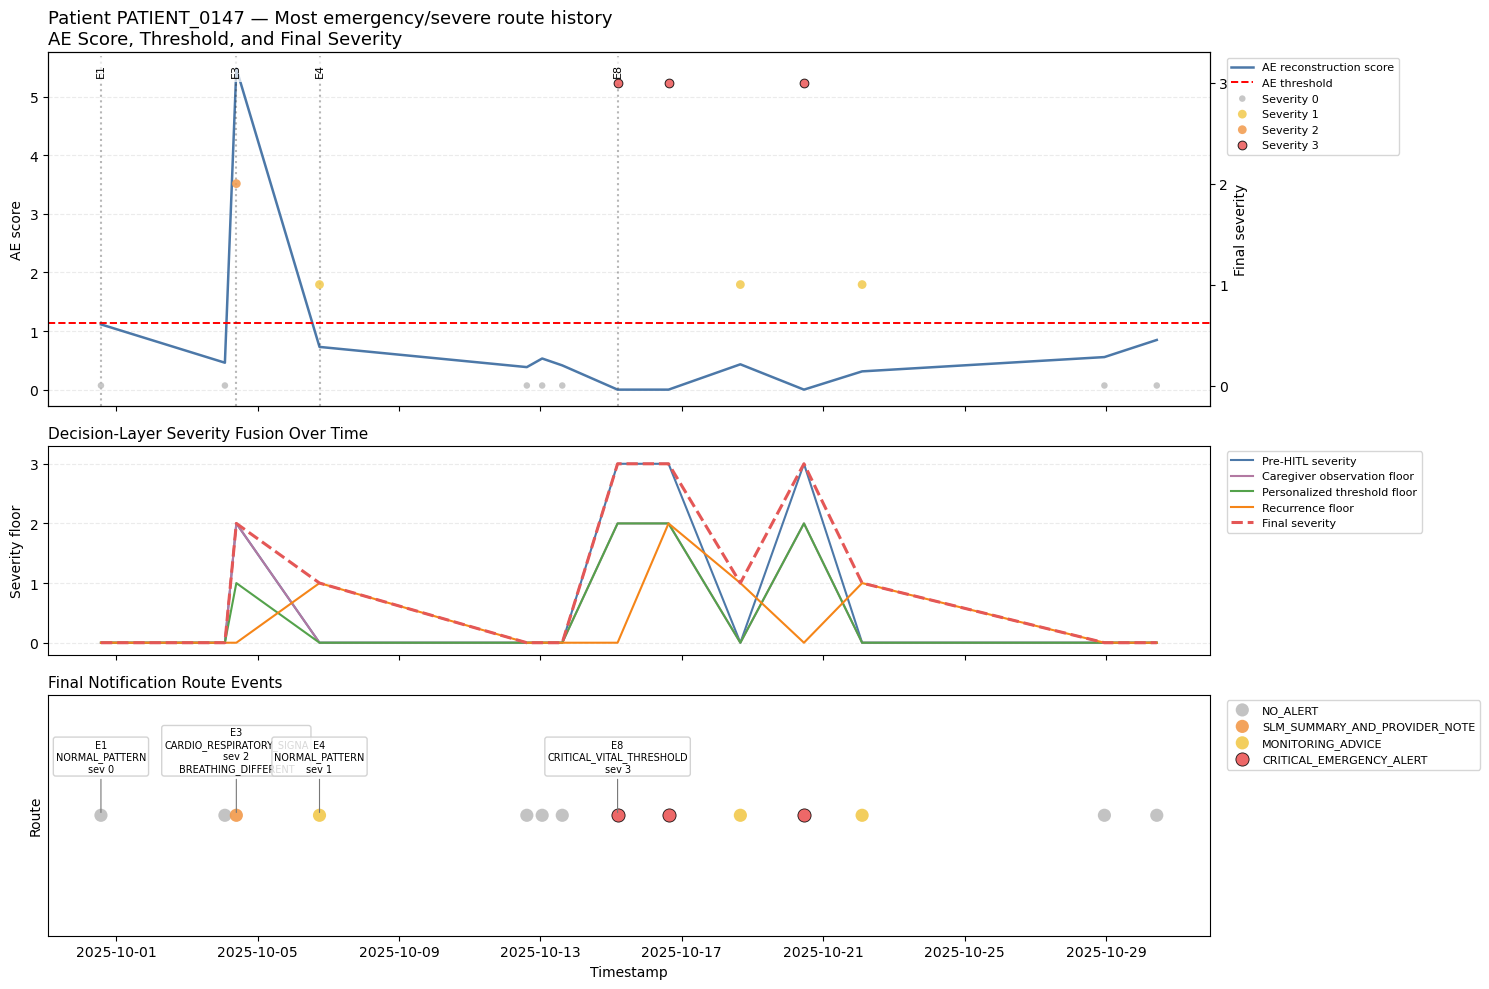

Saved: uc2_enhanced_decision_layer_outputs\figures\patient_timelines_multi\patient_timeline_PATIENT_0147.png


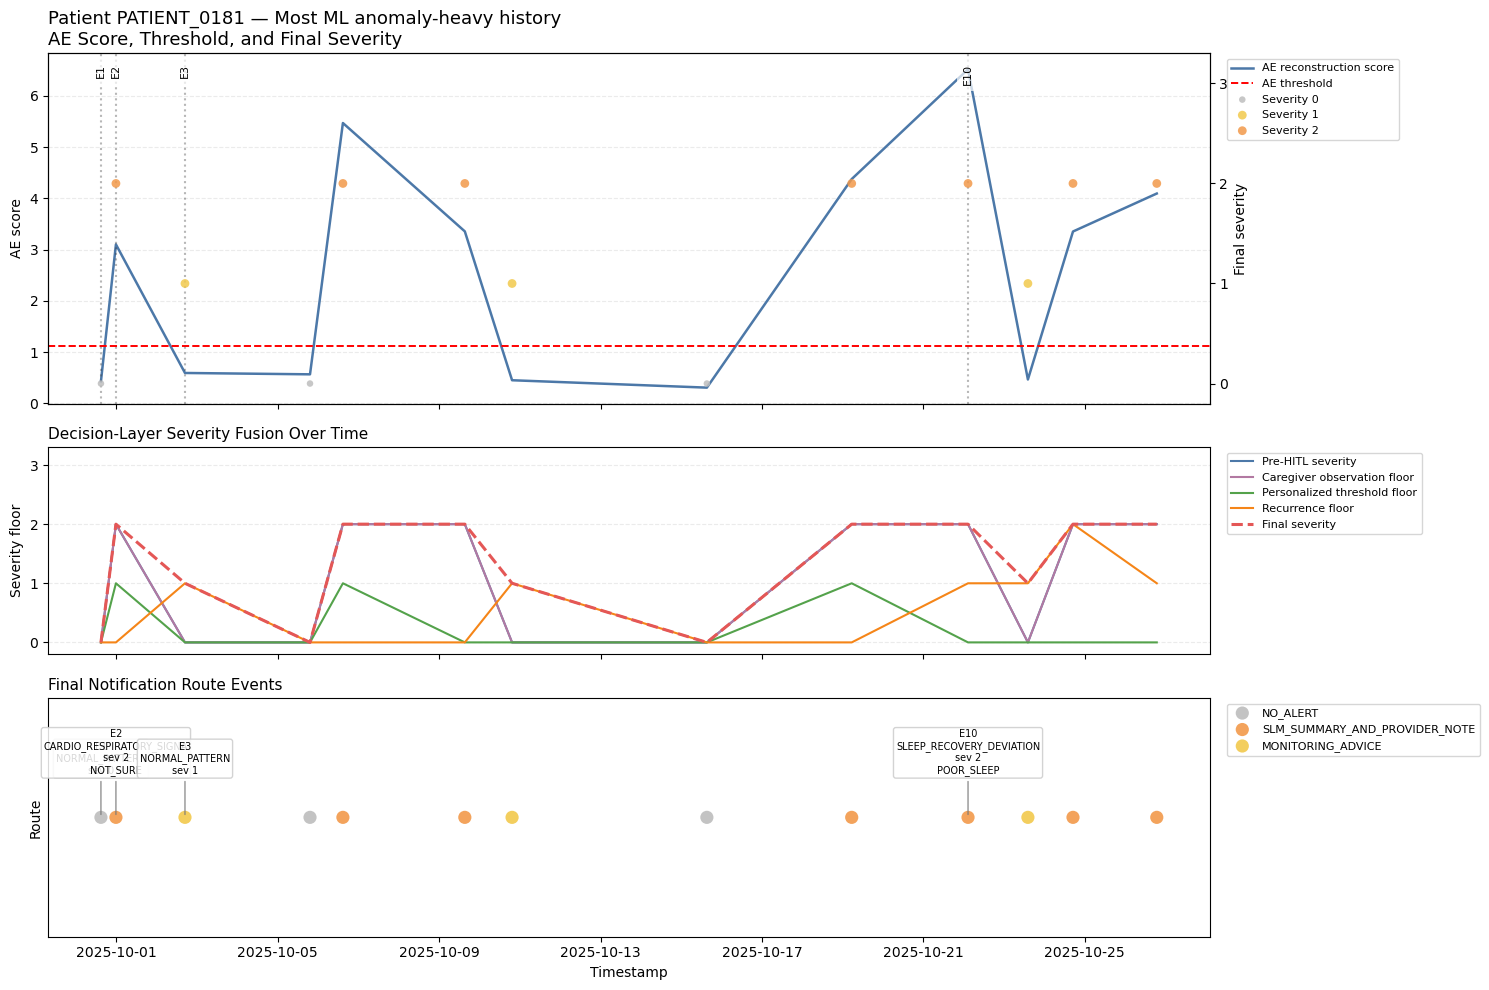

Saved: uc2_enhanced_decision_layer_outputs\figures\patient_timelines_multi\patient_timeline_PATIENT_0181.png


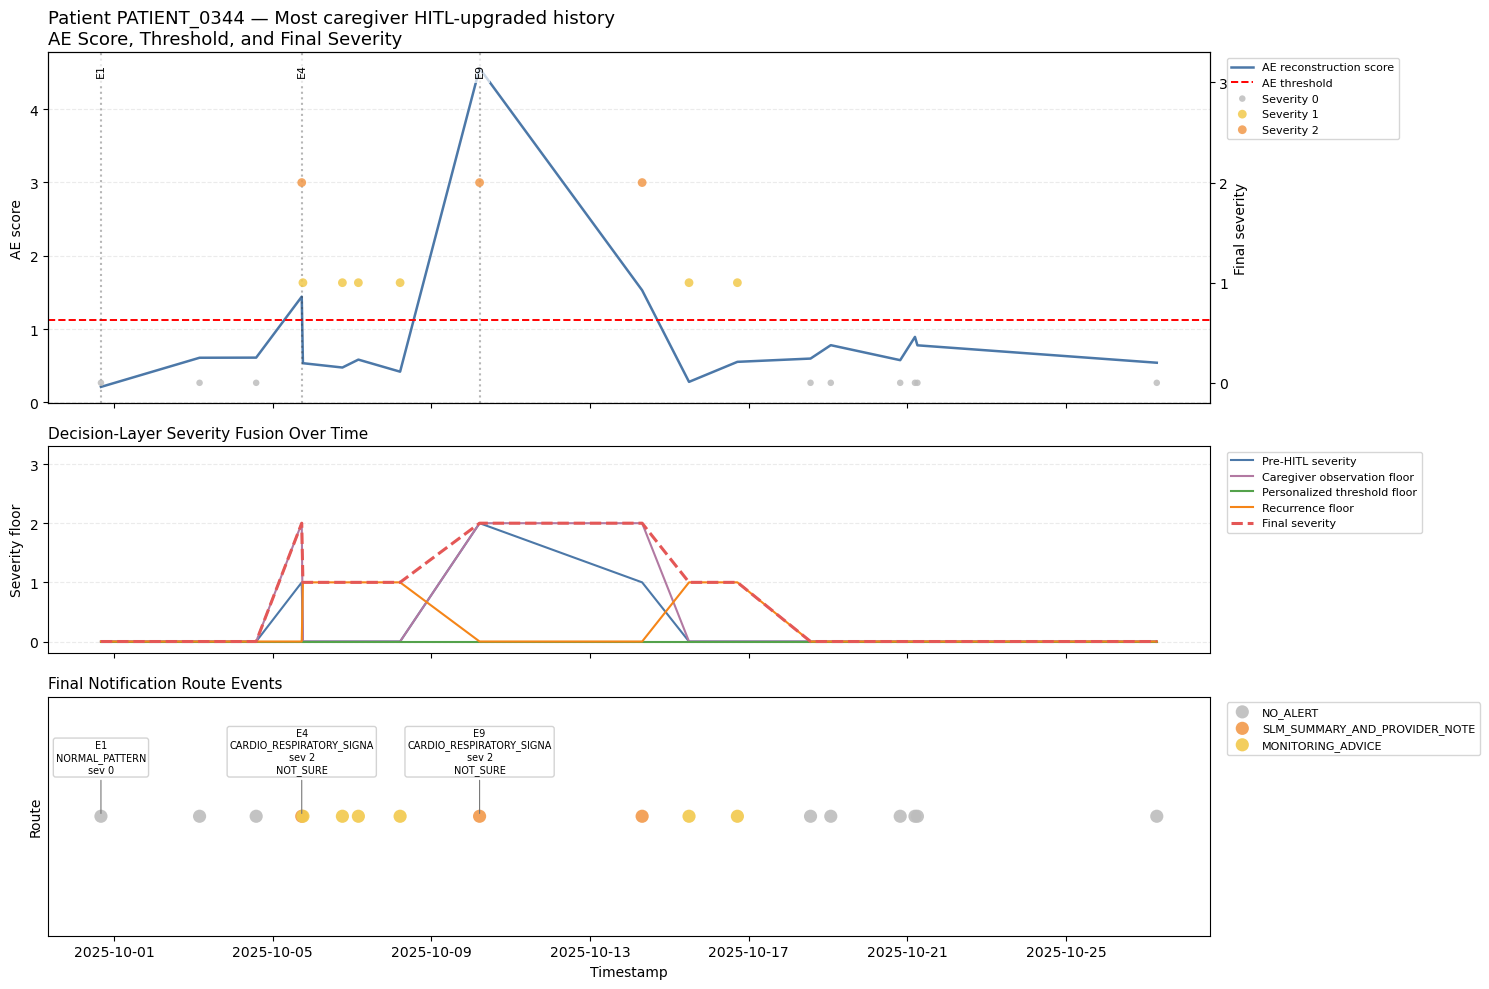

Saved: uc2_enhanced_decision_layer_outputs\figures\patient_timelines_multi\patient_timeline_PATIENT_0344.png


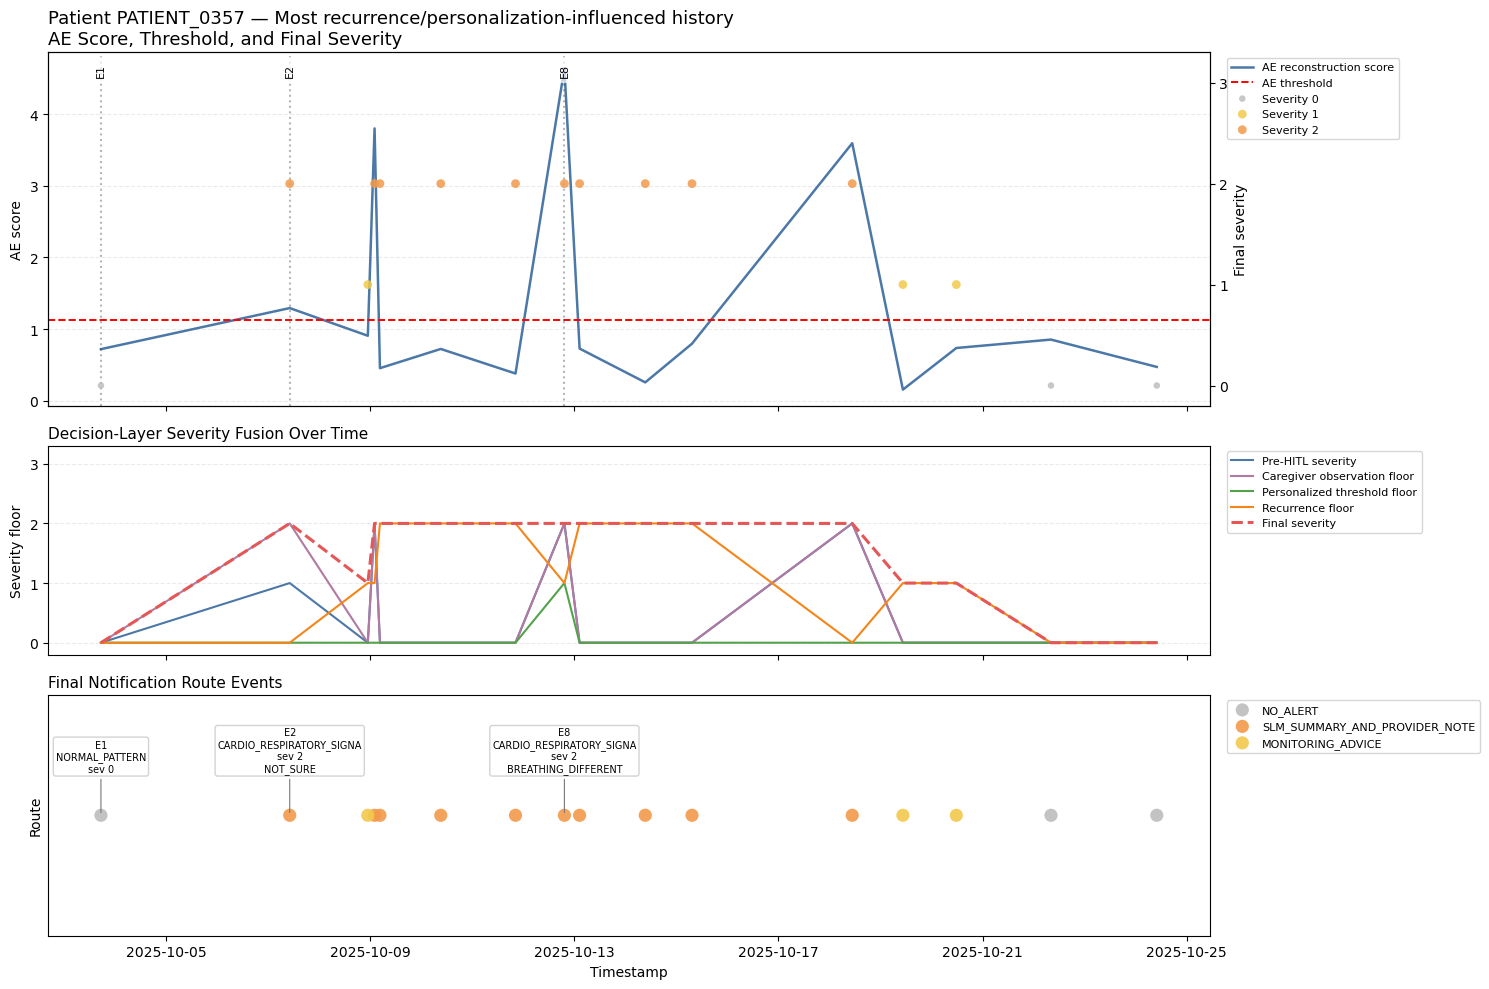

Saved: uc2_enhanced_decision_layer_outputs\figures\patient_timelines_multi\patient_timeline_PATIENT_0357.png


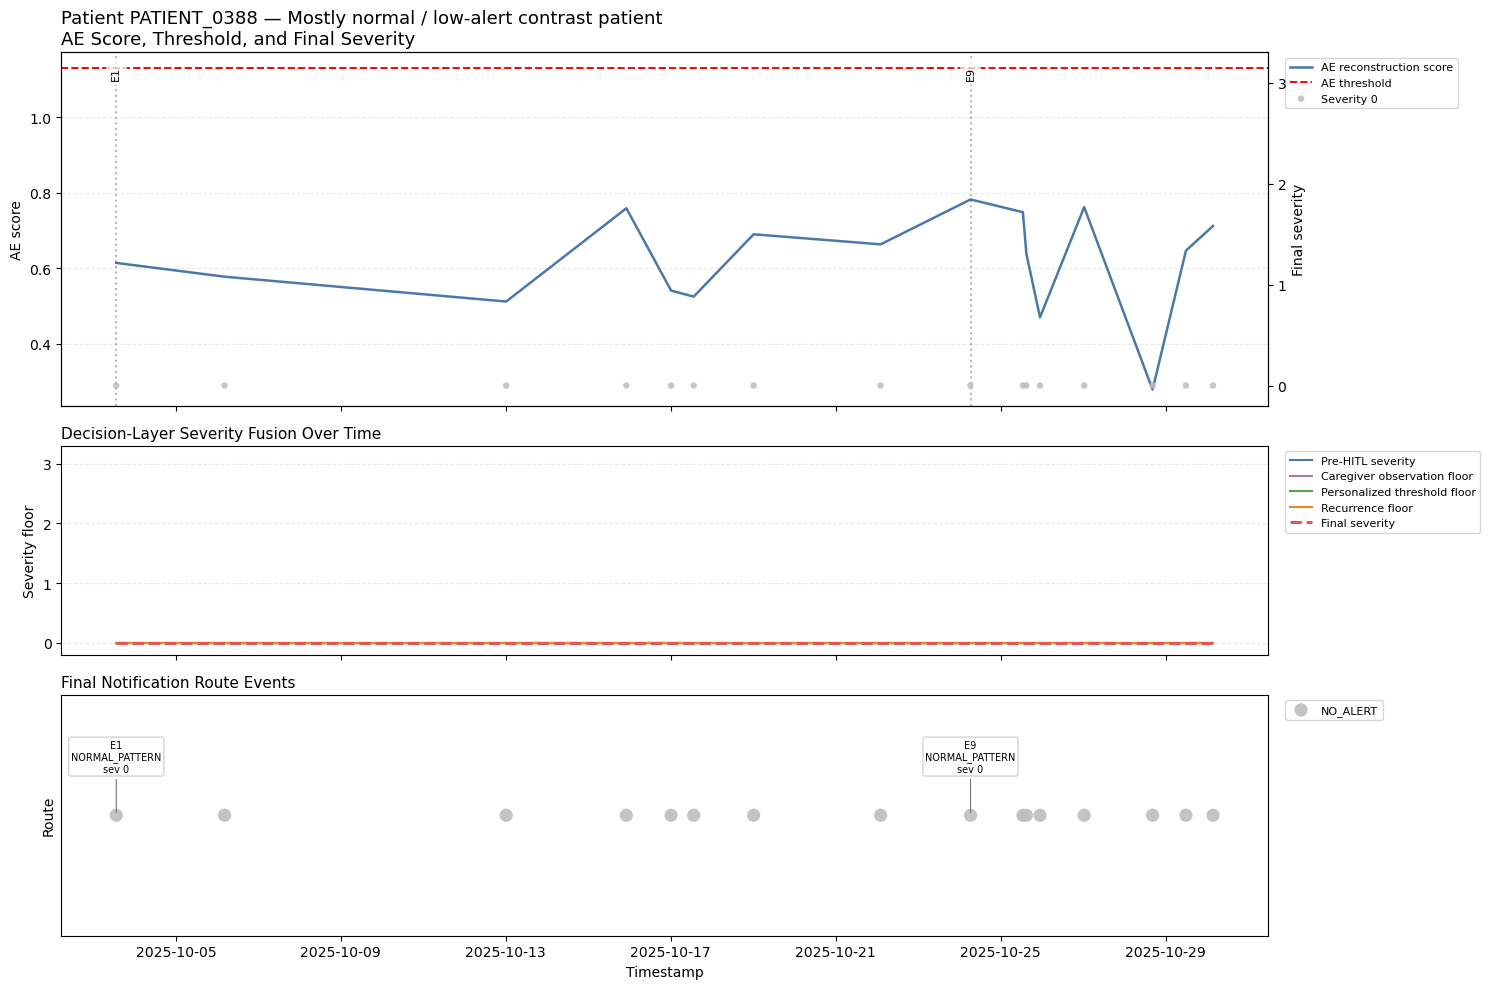

Saved: uc2_enhanced_decision_layer_outputs\figures\patient_timelines_multi\patient_timeline_PATIENT_0388.png


## Key Events Across Selected Patient Timelines

,event,patient_id,timestamp,AE_score,ML_anomaly,emergency,sensor_anomaly_type,pre_HITL_severity,caregiver_responses,observation_floor,personalized_floor,recurrence_floor,final_severity,notification,selection_reason
0,E1,PATIENT_0147,2025-09-30T13:30:45.056387,1.1138,False,False,NORMAL_PATTERN,0,,0,0,0,0,NO_ALERT,Most emergency/severe route history
1,E3,PATIENT_0147,2025-10-04T09:27:45.056387,5.4819,True,False,CARDIO_RESPIRATORY_SIGNAL_CHANGE,2,BREATHING_DIFFERENT,2,1,0,2,SLM_SUMMARY_AND_PROVIDER_NOTE,Most emergency/severe route history
2,E4,PATIENT_0147,2025-10-06T17:56:45.056387,0.7292,False,False,NORMAL_PATTERN,0,,0,0,1,1,MONITORING_ADVICE,Most emergency/severe route history
3,E8,PATIENT_0147,2025-10-15T04:22:45.056387,0.0000,False,True,CRITICAL_VITAL_THRESHOLD,3,,2,2,0,3,CRITICAL_EMERGENCY_ALERT,Most emergency/severe route history
4,E1,PATIENT_0181,2025-09-30T14:46:45.056387,0.4332,False,False,NORMAL_PATTERN,0,,0,0,0,0,NO_ALERT,Most ML anomaly-heavy history
5,E2,PATIENT_0181,2025-09-30T23:41:45.056387,3.1027,True,False,CARDIO_RESPIRATORY_SIGNAL_CHANGE,2,NOT_SURE,2,1,0,2,SLM_SUMMARY_AND_PROVIDER_NOTE,Most ML anomaly-heavy history
6,E3,PATIENT_0181,2025-10-02T16:45:45.056387,0.5949,False,False,NORMAL_PATTERN,0,,0,0,1,1,MONITORING_ADVICE,Most ML anomaly-heavy history
7,E10,PATIENT_0181,2025-10-22T02:30:45.056387,6.5190,True,False,SLEEP_RECOVERY_DEVIATION,2,POOR_SLEEP,2,0,1,2,SLM_SUMMARY_AND_PROVIDER_NOTE,Most ML anomaly-heavy history
8,E1,PATIENT_0344,2025-09-30T16:03:45.056387,0.2111,False,False,NORMAL_PATTERN,0,,0,0,0,0,NO_ALERT,Most caregiver HITL-upgraded history
9,E4,PATIENT_0344,2025-10-05T17:32:45.056387,1.4421,True,False,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,NOT_SURE,2,0,0,2,SLM_SUMMARY_AND_PROVIDER_NOTE,Most caregiver HITL-upgraded history


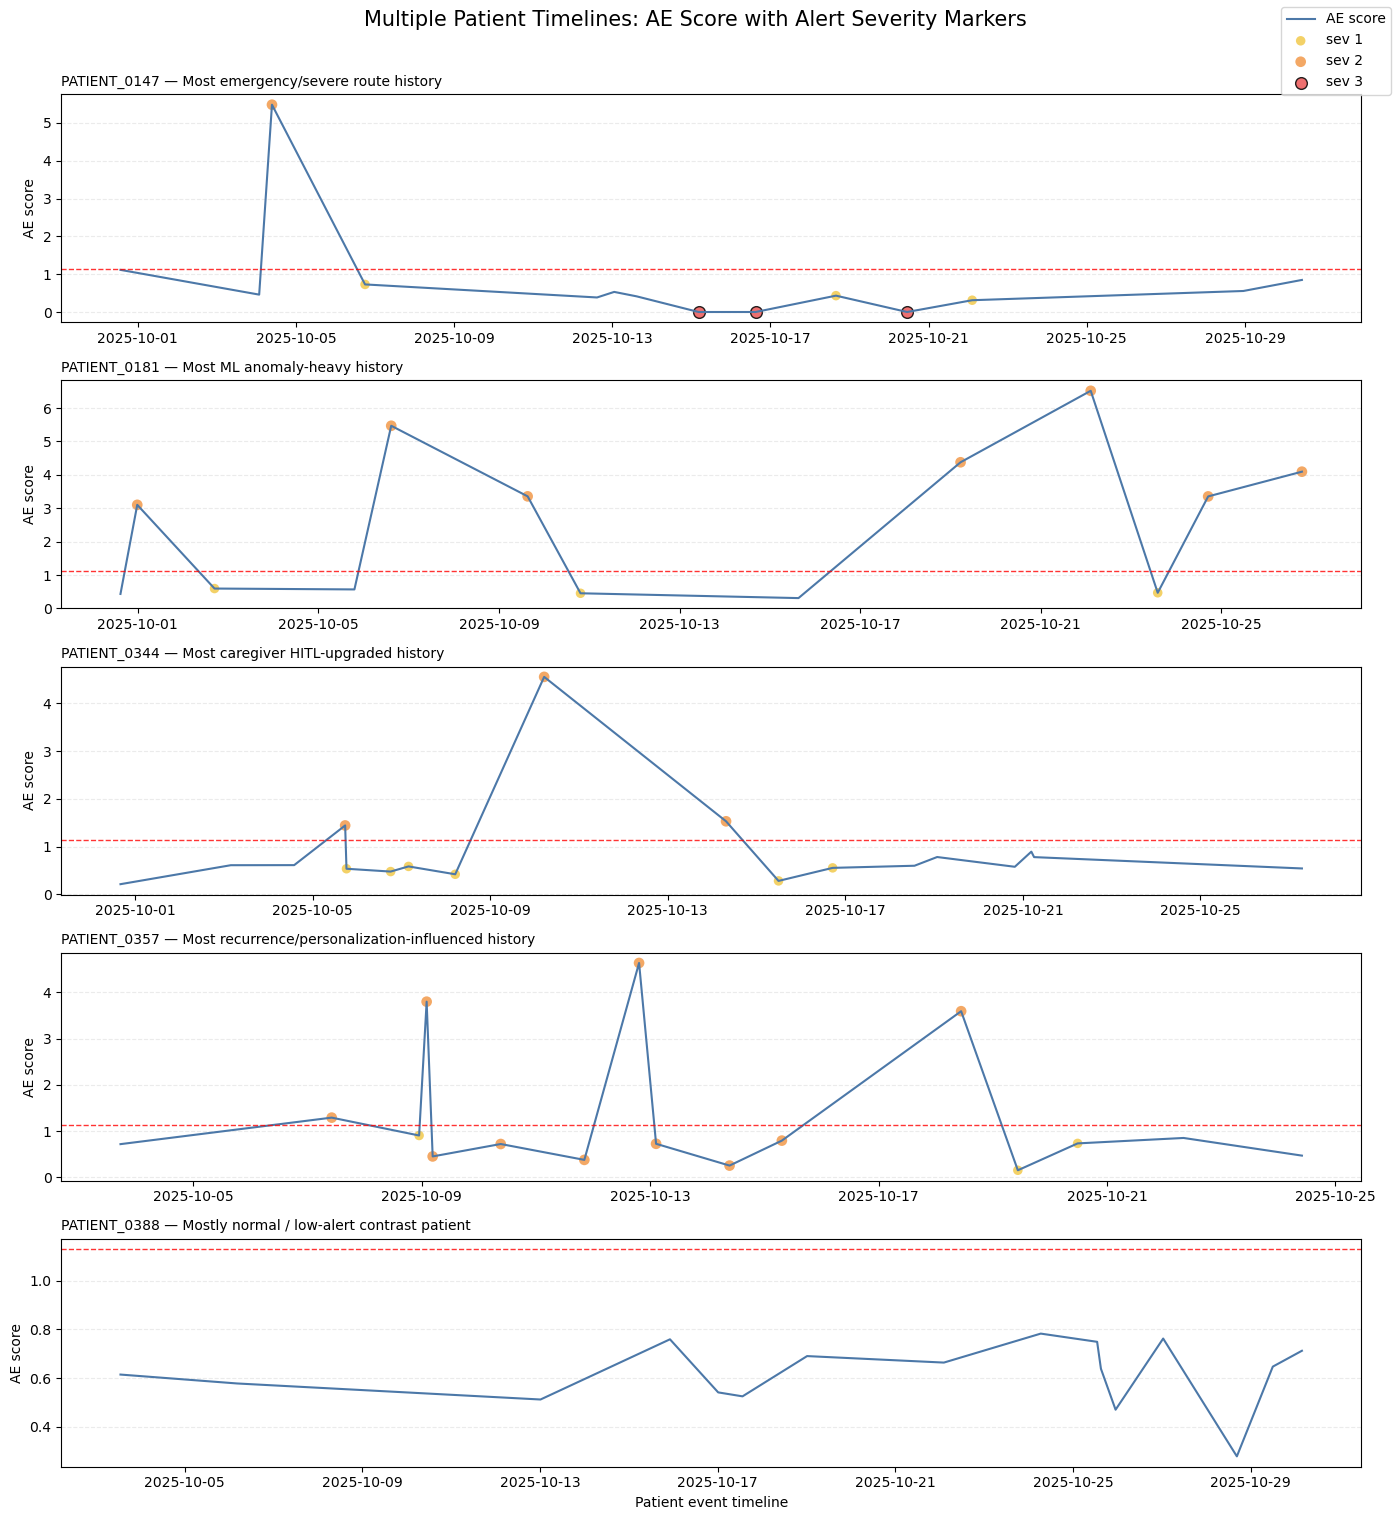


Done.
Saved combined overview: uc2_enhanced_decision_layer_outputs\figures\patient_timelines_multi\combined_selected_patient_timelines.png
All figures/tables saved to: C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\USE_CASE_2\uc2_enhanced_decision_layer_outputs\figures\patient_timelines_multi


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ UC2 Multi-Patient Timeline Visuals                                          ║
# ║ Shows several patients moving through AE score + decision layer severity    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
    HAS_IPYTHON = True
except Exception:
    HAS_IPYTHON = False

# 1. Setup

OUTPUT_DIR = Path("uc2_enhanced_decision_layer_outputs")
FIG_DIR = OUTPUT_DIR / "figures" / "patient_timelines_multi"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if "events_df" not in globals():
    EVENTS_CSV = OUTPUT_DIR / "uc2_enhanced_decision_events.csv"
    events_df = pd.read_csv(EVENTS_CSV)

df = events_df.copy()

print("Loaded events:", df.shape)
print("Saving figures to:", FIG_DIR.resolve())

# 2. Column helpers

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def safe_numeric(series, default=0):
    return pd.to_numeric(series, errors="coerce").fillna(default)

def parse_codes(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x

    s = str(x).strip()
    if not s:
        return []

    try:
        parsed = json.loads(s)
    except Exception:
        try:
            parsed = ast.literal_eval(s)
        except Exception:
            return [s]

    if isinstance(parsed, list):
        return [str(v) for v in parsed]
    if isinstance(parsed, dict):
        if "codes" in parsed and isinstance(parsed["codes"], list):
            return [str(v) for v in parsed["codes"]]
        if "code" in parsed:
            return [str(parsed["code"])]
        return [str(parsed)]
    return [str(parsed)]

def short_codes(x, max_items=2):
    vals = parse_codes(x)
    if not vals:
        return ""
    if len(vals) <= max_items:
        return ", ".join(vals)
    return ", ".join(vals[:max_items]) + f" +{len(vals)-max_items}"

# 3. Detect columns

patient_col = find_col(df, ["patient_id", "patientId", "patient"])
timestamp_col = find_col(df, ["timestamp", "event_time", "created_at", "datetime", "time"])

ae_score_col = find_col(df, ["anomalyScore", "ae_score", "anomaly_score", "reconstruction_error", "mse"])
is_anomaly_col = find_col(df, ["isAnomaly", "is_anomaly", "ml_is_anomaly"])

sensor_type_col = find_col(df, ["sensor_anomaly_type", "anomalyType", "anomaly_type"])
family_col = find_col(df, ["anomaly_family", "family"])

pre_sev_col = find_col(df, ["pre_hitl_severity", "initial_severity"])
obs_floor_col = find_col(df, ["observation_severity_floor", "caregiver_observation_floor"])
personalized_floor_col = find_col(df, ["personalized_threshold_severity_floor", "personalized_floor"])
recurrence_floor_col = find_col(df, ["recurrence_severity_floor", "recurrence_floor"])
post_sev_col = find_col(df, ["post_hitl_severity", "final_severity", "severity"])

notification_col = find_col(df, ["notificationType", "final_route", "notification_type", "notificationLevel"])
caregiver_col = find_col(df, ["caregiverResponses", "caregiver_responses", "caregiver_codes"])
top_features_col = find_col(df, ["topFeatures", "top_reconstruction_features", "top_features"])

emergency_col = find_col(df, ["is_hard_emergency", "hard_emergency", "rule_engine_emergency", "emergency_fast_path"])

if patient_col is None:
    raise ValueError("No patient_id column found.")

required_cols = [
    patient_col,
    ae_score_col,
    pre_sev_col,
    obs_floor_col,
    personalized_floor_col,
    recurrence_floor_col,
    post_sev_col,
    notification_col,
]

missing = [c for c in required_cols if c is None]
if missing:
    raise ValueError(f"Missing required column(s): {missing}")

print("\nDetected:")
for name, col in {
    "patient": patient_col,
    "timestamp": timestamp_col,
    "AE score": ae_score_col,
    "is anomaly": is_anomaly_col,
    "sensor type": sensor_type_col,
    "pre severity": pre_sev_col,
    "observation floor": obs_floor_col,
    "personalized floor": personalized_floor_col,
    "recurrence floor": recurrence_floor_col,
    "post severity": post_sev_col,
    "notification": notification_col,
    "caregiver": caregiver_col,
    "emergency": emergency_col,
}.items():
    print(f"  {name:22s}: {col}")

# 4. Normalize fields

for c in [
    ae_score_col,
    pre_sev_col,
    obs_floor_col,
    personalized_floor_col,
    recurrence_floor_col,
    post_sev_col,
]:
    df[c] = safe_numeric(df[c])

if is_anomaly_col:
    df["_is_anomaly_bool"] = df[is_anomaly_col].astype(str).str.lower().isin(["true", "1", "yes"])
else:
    df["_is_anomaly_bool"] = df[ae_score_col] > 1.129848

if emergency_col:
    df["_is_emergency_bool"] = df[emergency_col].astype(str).str.lower().isin(["true", "1", "yes"])
else:
    if sensor_type_col:
        df["_is_emergency_bool"] = df[sensor_type_col].astype(str).eq("CRITICAL_VITAL_THRESHOLD")
    else:
        df["_is_emergency_bool"] = df[post_sev_col] >= 3

df["_hitl_upgrade"] = df[obs_floor_col] > df[pre_sev_col]
df["_personalized_upgrade"] = df[personalized_floor_col] > df[pre_sev_col]
df["_recurrence_upgrade"] = df[recurrence_floor_col] > df[pre_sev_col]
df["_any_context_upgrade"] = df[post_sev_col] > df[pre_sev_col]

# 5. Patient-level summary and automatic selection

patient_summary = (
    df.groupby(patient_col)
    .agg(
        event_count=(patient_col, "size"),
        alert_count=(post_sev_col, lambda x: int((x > 0).sum())),
        severity_1_count=(post_sev_col, lambda x: int((x == 1).sum())),
        severity_2_count=(post_sev_col, lambda x: int((x == 2).sum())),
        severity_3_count=(post_sev_col, lambda x: int((x == 3).sum())),
        max_severity=(post_sev_col, "max"),
        ml_anomaly_count=("_is_anomaly_bool", "sum"),
        emergency_count=("_is_emergency_bool", "sum"),
        hitl_upgrade_count=("_hitl_upgrade", "sum"),
        personalized_upgrade_count=("_personalized_upgrade", "sum"),
        recurrence_upgrade_count=("_recurrence_upgrade", "sum"),
        any_context_upgrade_count=("_any_context_upgrade", "sum"),
        ae_score_mean=(ae_score_col, "mean"),
        ae_score_max=(ae_score_col, "max"),
    )
    .reset_index()
)

patient_summary["alert_rate"] = (
    patient_summary["alert_count"] / patient_summary["event_count"]
).round(3)

patient_summary["ml_anomaly_rate"] = (
    patient_summary["ml_anomaly_count"] / patient_summary["event_count"]
).round(3)

if HAS_IPYTHON:
    display(Markdown("## Patient-Level Summary"))
    display(patient_summary.sort_values(
        ["max_severity", "alert_count", "ml_anomaly_count"],
        ascending=False
    ).head(15))

patient_summary.to_csv(FIG_DIR / "patient_timeline_selection_summary.csv", index=False)

# Selection buckets
selected_patients = []
selection_reason = {}

def add_patient(row, reason):
    if row is None:
        return
    pid = row[patient_col]
    if pid not in selected_patients:
        selected_patients.append(pid)
        selection_reason[pid] = reason

# 1. Emergency-heavy / most severe
emergency_candidates = patient_summary.sort_values(
    ["severity_3_count", "max_severity", "alert_count"],
    ascending=False
)
if len(emergency_candidates):
    add_patient(emergency_candidates.iloc[0], "Most emergency/severe route history")

# 2. ML anomaly-heavy
ml_candidates = patient_summary.sort_values(
    ["ml_anomaly_count", "ae_score_max"],
    ascending=False
)
if len(ml_candidates):
    add_patient(ml_candidates.iloc[0], "Most ML anomaly-heavy history")

# 3. HITL-upgraded patient
hitl_candidates = patient_summary[patient_summary["hitl_upgrade_count"] > 0].sort_values(
    ["hitl_upgrade_count", "alert_count"],
    ascending=False
)
if len(hitl_candidates):
    add_patient(hitl_candidates.iloc[0], "Most caregiver HITL-upgraded history")

# 4. Recurrence/personalization-influenced patient
context_candidates = patient_summary[
    (patient_summary["recurrence_upgrade_count"] > 0)
    | (patient_summary["personalized_upgrade_count"] > 0)
].sort_values(
    ["recurrence_upgrade_count", "personalized_upgrade_count", "alert_count"],
    ascending=False
)
if len(context_candidates):
    add_patient(context_candidates.iloc[0], "Most recurrence/personalization-influenced history")

# 5. Mostly normal patient for contrast
normal_candidates = patient_summary[
    (patient_summary["max_severity"] == 0)
    | (patient_summary["alert_rate"] < 0.05)
].sort_values(
    ["alert_rate", "ml_anomaly_rate", "event_count"],
    ascending=[True, True, False]
)
if len(normal_candidates):
    add_patient(normal_candidates.iloc[0], "Mostly normal / low-alert contrast patient")

# Limit to 5
selected_patients = selected_patients[:5]

print("\nSelected patients:")
for pid in selected_patients:
    print(f" - {pid}: {selection_reason[pid]}")

# 6. Timeline plotting function

severity_colors = {
    0: "#BDBDBD",
    1: "#F2C94C",
    2: "#F2994A",
    3: "#EB5757",
}

route_colors = {
    "NO_ALERT": "#BDBDBD",
    "MONITORING_ADVICE": "#F2C94C",
    "SLM_SUMMARY_AND_PROVIDER_NOTE": "#F2994A",
    "CRITICAL_EMERGENCY_ALERT": "#EB5757",
}

def prepare_patient_df(pid):
    pdf = df[df[patient_col] == pid].copy()

    if timestamp_col and timestamp_col in pdf.columns:
        pdf["_timestamp_dt"] = pd.to_datetime(pdf[timestamp_col], errors="coerce")
        if pdf["_timestamp_dt"].notna().any():
            pdf = pdf.sort_values("_timestamp_dt")
            pdf["_x"] = pdf["_timestamp_dt"]
            x_label = "Timestamp"
        else:
            pdf = pdf.reset_index(drop=True)
            pdf["_x"] = np.arange(len(pdf))
            x_label = "Event index"
    else:
        pdf = pdf.reset_index(drop=True)
        pdf["_x"] = np.arange(len(pdf))
        x_label = "Event index"

    pdf = pdf.reset_index(drop=True)
    pdf["_event_num"] = np.arange(1, len(pdf) + 1)
    return pdf, x_label

def pick_key_events(pdf, max_events=6):
    indices = []

    # First normal no-alert
    sub = pdf[pdf[post_sev_col] == 0]
    if len(sub):
        indices.append(sub.index[0])

    # First ML anomaly
    sub = pdf[pdf["_is_anomaly_bool"]]
    if len(sub):
        indices.append(sub.index[0])

    # First HITL/context upgrade
    sub = pdf[pdf[post_sev_col] > pdf[pre_sev_col]]
    if len(sub):
        indices.append(sub.index[0])

    # Max AE score
    if len(pdf):
        indices.append(pdf[ae_score_col].idxmax())

    # First severity 2
    sub = pdf[pdf[post_sev_col] == 2]
    if len(sub):
        indices.append(sub.index[0])

    # First severity 3
    sub = pdf[pdf[post_sev_col] == 3]
    if len(sub):
        indices.append(sub.index[0])

    # De-duplicate
    indices = list(dict.fromkeys(indices))
    return pdf.loc[indices[:max_events]].copy()

def plot_patient_timeline(pid, reason):
    pdf, x_label = prepare_patient_df(pid)
    key_events = pick_key_events(pdf)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(15, 10),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.3, 1.5]}
    )

    ax1, ax2, ax3 = axes

    # Panel 1: AE score + threshold + final severity points
    ax1.plot(
        pdf["_x"],
        pdf[ae_score_col],
        color="#4C78A8",
        linewidth=1.8,
        label="AE reconstruction score"
    )

    ax1.axhline(
        1.129848,
        color="red",
        linestyle="--",
        linewidth=1.4,
        label="AE threshold"
    )

    ax1.set_ylabel("AE score")
    ax1.grid(axis="y", linestyle="--", alpha=0.25)

    ax1b = ax1.twinx()

    for sev in [0, 1, 2, 3]:
        sub = pdf[pdf[post_sev_col] == sev]
        if len(sub):
            ax1b.scatter(
                sub["_x"],
                sub[post_sev_col],
                s=40 if sev > 0 else 22,
                color=severity_colors[sev],
                alpha=0.85,
                edgecolor="black" if sev == 3 else "none",
                linewidth=0.7,
                label=f"Severity {sev}"
            )

    ax1b.set_ylabel("Final severity")
    ax1b.set_yticks([0, 1, 2, 3])
    ax1b.set_ylim(-0.2, 3.3)

    # Mark key events
    for _, row in key_events.iterrows():
        ax1.axvline(row["_x"], color="#333333", linestyle=":", alpha=0.35)
        ax1.text(
            row["_x"],
            ax1.get_ylim()[1] * 0.97,
            f"E{int(row['_event_num'])}",
            ha="center",
            va="top",
            fontsize=8,
            rotation=90,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
        )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        fontsize=8
    )

    ax1.set_title(
        f"Patient {pid} — {reason}\nAE Score, Threshold, and Final Severity",
        fontsize=13,
        loc="left"
    )

    # Panel 2: Severity components over time
    ax2.plot(
        pdf["_x"],
        pdf[pre_sev_col],
        label="Pre-HITL severity",
        color="#4C78A8",
        linewidth=1.5
    )
    ax2.plot(
        pdf["_x"],
        pdf[obs_floor_col],
        label="Caregiver observation floor",
        color="#B279A2",
        linewidth=1.5
    )
    ax2.plot(
        pdf["_x"],
        pdf[personalized_floor_col],
        label="Personalized threshold floor",
        color="#54A24B",
        linewidth=1.5
    )
    ax2.plot(
        pdf["_x"],
        pdf[recurrence_floor_col],
        label="Recurrence floor",
        color="#F58518",
        linewidth=1.5
    )
    ax2.plot(
        pdf["_x"],
        pdf[post_sev_col],
        label="Final severity",
        color="#E45756",
        linewidth=2.2,
        linestyle="--"
    )

    ax2.set_ylabel("Severity floor")
    ax2.set_yticks([0, 1, 2, 3])
    ax2.set_ylim(-0.2, 3.3)
    ax2.grid(axis="y", linestyle="--", alpha=0.25)
    ax2.legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        fontsize=8
    )
    ax2.set_title("Decision-Layer Severity Fusion Over Time", fontsize=11, loc="left")

    # Panel 3: Notification route strip
    route_y = np.zeros(len(pdf))

    for route in pdf[notification_col].dropna().unique():
        sub = pdf[pdf[notification_col] == route]
        color = route_colors.get(str(route), "#999999")
        ax3.scatter(
            sub["_x"],
            np.zeros(len(sub)),
            s=90,
            color=color,
            label=str(route),
            alpha=0.9,
            edgecolor="black" if str(route) == "CRITICAL_EMERGENCY_ALERT" else "none",
            linewidth=0.6
        )

    # Annotate selected key events with compact details
    for _, row in key_events.iterrows():
        cg = short_codes(row[caregiver_col]) if caregiver_col else ""
        stype = str(row[sensor_type_col]) if sensor_type_col else ""
        note = (
            f"E{int(row['_event_num'])}\n"
            f"{stype[:24]}\n"
            f"sev {int(row[post_sev_col])}"
        )
        if cg:
            note += f"\n{cg[:24]}"

        ax3.annotate(
            note,
            xy=(row["_x"], 0),
            xytext=(0, 30),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7,
            arrowprops=dict(arrowstyle="-", color="#777777", lw=0.8),
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#CCCCCC", alpha=0.85)
        )

    ax3.set_yticks([])
    ax3.set_ylabel("Route")
    ax3.set_xlabel(x_label)
    ax3.set_title("Final Notification Route Events", fontsize=11, loc="left")
    ax3.legend(
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        fontsize=8
    )

    plt.tight_layout()

    safe_pid = str(pid).replace("/", "_").replace("\\", "_").replace(" ", "_")
    fig_path = FIG_DIR / f"patient_timeline_{safe_pid}.png"
    plt.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()

    key_rows = []

    for _, row in key_events.iterrows():
        key_rows.append({
            "event": f"E{int(row['_event_num'])}",
            "patient_id": pid,
            "timestamp": row[timestamp_col] if timestamp_col else "",
            "AE_score": round(float(row[ae_score_col]), 4),
            "ML_anomaly": bool(row["_is_anomaly_bool"]),
            "emergency": bool(row["_is_emergency_bool"]),
            "sensor_anomaly_type": row[sensor_type_col] if sensor_type_col else "",
            "pre_HITL_severity": int(row[pre_sev_col]),
            "caregiver_responses": short_codes(row[caregiver_col]) if caregiver_col else "",
            "observation_floor": int(row[obs_floor_col]),
            "personalized_floor": int(row[personalized_floor_col]),
            "recurrence_floor": int(row[recurrence_floor_col]),
            "final_severity": int(row[post_sev_col]),
            "notification": row[notification_col],
        })

    key_table = pd.DataFrame(key_rows)
    key_table.to_csv(FIG_DIR / f"patient_timeline_{safe_pid}_key_events.csv", index=False)

    return fig_path, key_table

# 7. Generate individual patient timelines

all_key_tables = []

for pid in selected_patients:
    reason = selection_reason[pid]
    fig_path, key_table = plot_patient_timeline(pid, reason)
    print("Saved:", fig_path)
    key_table["selection_reason"] = reason
    all_key_tables.append(key_table)

if all_key_tables:
    all_key_events = pd.concat(all_key_tables, ignore_index=True)
    all_key_events.to_csv(FIG_DIR / "all_selected_patient_key_events.csv", index=False)

    if HAS_IPYTHON:
        display(Markdown("## Key Events Across Selected Patient Timelines"))
        display(all_key_events)

# 8. Combined small-multiples overview

n = len(selected_patients)

fig, axes = plt.subplots(
    n,
    1,
    figsize=(14, max(3.0 * n, 5)),
    sharex=False
)

if n == 1:
    axes = [axes]

for ax, pid in zip(axes, selected_patients):
    pdf, x_label = prepare_patient_df(pid)

    ax.plot(
        pdf["_x"],
        pdf[ae_score_col],
        color="#4C78A8",
        linewidth=1.5,
        label="AE score"
    )

    ax.axhline(
        1.129848,
        color="red",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8
    )

    # Shade alert severity points
    for sev in [1, 2, 3]:
        sub = pdf[pdf[post_sev_col] == sev]
        if len(sub):
            ax.scatter(
                sub["_x"],
                sub[ae_score_col],
                s=35 + sev * 12,
                color=severity_colors[sev],
                alpha=0.85,
                edgecolor="black" if sev == 3 else "none",
                label=f"sev {sev}" if pid == selected_patients[0] else None
            )

    ax.set_title(
        f"{pid} — {selection_reason[pid]}",
        loc="left",
        fontsize=10
    )
    ax.set_ylabel("AE score")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

axes[-1].set_xlabel("Patient event timeline")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right")

plt.suptitle(
    "Multiple Patient Timelines: AE Score with Alert Severity Markers",
    fontsize=15,
    y=1.01
)
plt.tight_layout()
combined_path = FIG_DIR / "combined_selected_patient_timelines.png"
plt.savefig(combined_path, dpi=220, bbox_inches="tight")
plt.show()

print("\nDone.")
print("Saved combined overview:", combined_path)
print("All figures/tables saved to:", FIG_DIR.resolve())

Loaded: (5094, 72)
Detected columns:
  patient: patient_id
  timestamp: timestamp
  pre_hitl_severity: pre_hitl_severity
  observation_floor: observation_severity_floor
  personalized_floor: personalized_threshold_severity_floor
  recurrence_floor: recurrence_severity_floor
  post_hitl_severity: post_hitl_severity

Selection mode: STRICT: recurrence floor raised severity and determined final severity
Candidate recurrence-driven events: 656

Selected patient: PATIENT_0357
Patient total events: 16
Patient recurrence-driven events: 9


,patient_id,recurrence_driven_events,max_recurrence_floor,max_post_severity,mean_severity_gain,max_severity_gain
208,PATIENT_0357,9,2,2,1.666667,2
91,PATIENT_0151,7,2,2,1.285714,2
263,PATIENT_0461,6,2,2,1.166667,2
86,PATIENT_0141,5,2,2,1.200000,2
248,PATIENT_0431,5,2,2,1.800000,2
284,PATIENT_0491,5,2,2,1.400000,2
23,PATIENT_0040,4,2,2,1.750000,2
30,PATIENT_0050,4,2,2,1.500000,2
41,PATIENT_0063,4,2,2,2.000000,2
137,PATIENT_0236,4,2,2,1.500000,2



Representative recurrence-driven event:


,patient_id,timestamp,anomalyScore,isAnomaly,sensor_anomaly_type,pre_hitl_severity,observation_severity_floor,personalized_threshold_severity_floor,recurrence_severity_floor,post_hitl_severity,notificationType,caregiverResponses,topFeatures
1,PATIENT_0357,2025-10-09 04:34:45.056387,0.455261,False,NORMAL_PATTERN,0,0,0,2,2,SLM_SUMMARY_AND_PROVIDER_NOTE,[],"[{""feature"": ""body_temperature"", ""contribution..."



Saved:
  uc2_enhanced_decision_layer_outputs/figures/recurrence_patient\selected_patient_recurrence_driven_events.csv
  uc2_enhanced_decision_layer_outputs/figures/recurrence_patient\selected_patient_all_events.csv


Saved: uc2_enhanced_decision_layer_outputs/figures/recurrence_patient\01_recurrence_patient_timeline.png


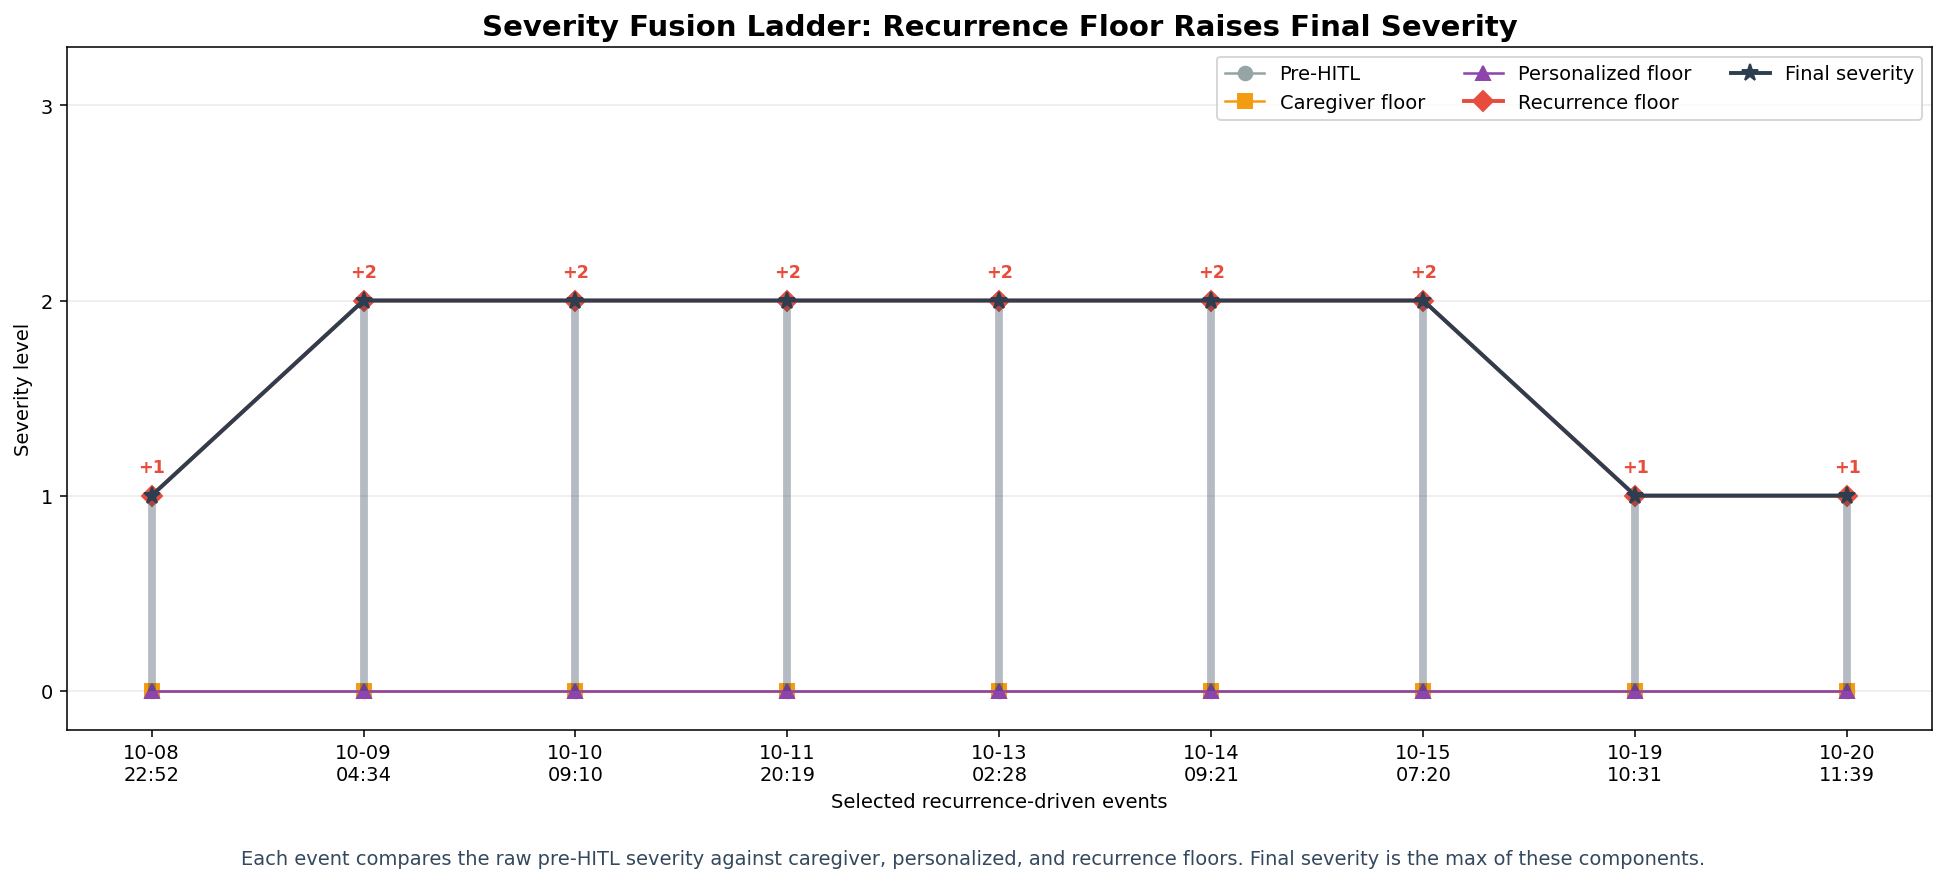

Saved: uc2_enhanced_decision_layer_outputs/figures/recurrence_patient\02_recurrence_severity_fusion_ladder.png


Saved: uc2_enhanced_decision_layer_outputs/figures/recurrence_patient\03_representative_recurrence_event_waterfall.png

Saved summary: uc2_enhanced_decision_layer_outputs/figures/recurrence_patient\recurrence_patient_summary.json

Slide takeaway:
For patient PATIENT_0357, recurrence history raised the final severity above the pre-HITL level. This demonstrates that repeated lower-level patterns can escalate the route even when a single event is not a hard emergency.


In [16]:
# RECURRENCE-DRIVEN SEVERITY VISUAL
# Goal: show one patient where recurrence clearly increased final severity
# Outputs saved under:
#   uc2_enhanced_decision_layer_outputs/figures/recurrence_patient/

import os
import json
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional prettier defaults
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.size"] = 10

# 1. Load enhanced decision-layer events

EVENTS_PATH = "uc2_enhanced_decision_layer_outputs/uc2_enhanced_decision_events.csv"
OUT_DIR = "uc2_enhanced_decision_layer_outputs/figures/recurrence_patient"
os.makedirs(OUT_DIR, exist_ok=True)

events_df = pd.read_csv(EVENTS_PATH)
print("Loaded:", events_df.shape)

# 2. Robust column detection

def first_existing_col(df, candidates, required=False):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"Missing required column. Tried: {candidates}")
    return None

COL_PATIENT = first_existing_col(events_df, ["patient_id", "patientId", "patient"], required=True)
COL_TIME = first_existing_col(events_df, ["timestamp", "event_time", "time", "datetime"], required=True)

COL_AE_SCORE = first_existing_col(events_df, ["anomalyScore", "ae_score", "mse", "reconstruction_error"])
COL_IS_ANOM = first_existing_col(events_df, ["isAnomaly", "is_anomaly", "ml_anomaly"])
COL_SENSOR_TYPE = first_existing_col(events_df, ["sensor_anomaly_type", "anomalyType", "pre_hitl_anomaly_type"])
COL_PRE = first_existing_col(events_df, ["pre_hitl_severity", "preSeverity", "pre_severity"])
COL_OBS = first_existing_col(events_df, ["observation_severity_floor", "caregiver_severity_floor", "hitl_severity_floor"])
COL_PERSONAL = first_existing_col(events_df, ["personalized_threshold_severity_floor", "personalized_severity_floor"])
COL_REC = first_existing_col(events_df, ["recurrence_severity_floor", "recurrence_floor"])
COL_POST = first_existing_col(events_df, ["post_hitl_severity", "severity", "final_severity"])
COL_ROUTE = first_existing_col(events_df, ["notificationType", "notification_type", "route", "final_route"])
COL_CAREGIVER = first_existing_col(events_df, ["caregiverResponses", "caregiver_responses", "caregiver_codes"])
COL_TOP = first_existing_col(events_df, ["topFeatures", "top_features"])

needed = {
    "patient": COL_PATIENT,
    "timestamp": COL_TIME,
    "pre_hitl_severity": COL_PRE,
    "observation_floor": COL_OBS,
    "personalized_floor": COL_PERSONAL,
    "recurrence_floor": COL_REC,
    "post_hitl_severity": COL_POST,
}

print("Detected columns:")
for k, v in needed.items():
    print(f"  {k}: {v}")

missing_core = [k for k, v in needed.items() if v is None]
if missing_core:
    raise ValueError(f"Missing core columns for recurrence visual: {missing_core}")

df = events_df.copy()

# Parse timestamp
df[COL_TIME] = pd.to_datetime(df[COL_TIME], errors="coerce")

# Numeric severity/floor columns
for c in [COL_PRE, COL_OBS, COL_PERSONAL, COL_REC, COL_POST, COL_AE_SCORE]:
    if c is not None:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Fill floor/severity NaNs conservatively
for c in [COL_PRE, COL_OBS, COL_PERSONAL, COL_REC, COL_POST]:
    df[c] = df[c].fillna(0).astype(int)

if COL_AE_SCORE is not None:
    df[COL_AE_SCORE] = df[COL_AE_SCORE].fillna(0.0)

# 3. Identify recurrence-driven events
# Strict definition:
# recurrence floor alone is higher than pre-HITL severity AND determines final severity.
#
# This is the cleanest slide example:
#   pre-HITL severity was lower,
#   observation/personalized floors did not exceed recurrence,
#   recurrence floor became the final post-HITL severity.

strict_mask = (
    (df[COL_REC] > df[COL_PRE]) &
    (df[COL_REC] >= df[COL_OBS]) &
    (df[COL_REC] >= df[COL_PERSONAL]) &
    (df[COL_POST] == df[COL_REC])
)

strict_events = df[strict_mask].copy()

# Relaxed definition:
# recurrence contributed to an increase, even if another floor tied it.
relaxed_mask = (
    (df[COL_REC] > df[COL_PRE]) &
    (df[COL_POST] > df[COL_PRE]) &
    (df[COL_POST] >= df[COL_REC])
)

relaxed_events = df[relaxed_mask].copy()

# Fallback:
# recurrence was active and final severity increased from pre-HITL.
fallback_mask = (
    (df[COL_REC] > 0) &
    (df[COL_POST] > df[COL_PRE])
)

fallback_events = df[fallback_mask].copy()

if len(strict_events) > 0:
    recurrence_events = strict_events
    selection_mode = "STRICT: recurrence floor raised severity and determined final severity"
elif len(relaxed_events) > 0:
    recurrence_events = relaxed_events
    selection_mode = "RELAXED: recurrence floor contributed to post-HITL severity increase"
elif len(fallback_events) > 0:
    recurrence_events = fallback_events
    selection_mode = "FALLBACK: recurrence floor active during a post-HITL severity increase"
else:
    recurrence_events = df[df[COL_REC] > 0].copy()
    selection_mode = "LAST RESORT: recurrence floor active, but no clear severity increase found"

print("\nSelection mode:", selection_mode)
print("Candidate recurrence-driven events:", len(recurrence_events))

if len(recurrence_events) == 0:
    raise ValueError("No events with recurrence_severity_floor > 0 were found.")

# 4. Select the clearest patient

patient_rank = (
    recurrence_events
    .groupby(COL_PATIENT)
    .agg(
        recurrence_driven_events=(COL_REC, "count"),
        max_recurrence_floor=(COL_REC, "max"),
        max_post_severity=(COL_POST, "max"),
        mean_severity_gain=(COL_POST, lambda x: np.nan),
    )
    .reset_index()
)

# Add average severity gain manually
gains = []
for pid, g in recurrence_events.groupby(COL_PATIENT):
    gains.append({
        COL_PATIENT: pid,
        "mean_severity_gain": float((g[COL_POST] - g[COL_PRE]).mean()),
        "max_severity_gain": int((g[COL_POST] - g[COL_PRE]).max()),
    })
gain_df = pd.DataFrame(gains)

patient_rank = patient_rank.drop(columns=["mean_severity_gain"], errors="ignore")
patient_rank = patient_rank.merge(gain_df, on=COL_PATIENT, how="left")

patient_rank = patient_rank.sort_values(
    by=["max_recurrence_floor", "max_severity_gain", "recurrence_driven_events", "max_post_severity"],
    ascending=[False, False, False, False]
)

selected_patient = patient_rank.iloc[0][COL_PATIENT]

patient_df = df[df[COL_PATIENT] == selected_patient].copy()
patient_df = patient_df.sort_values(COL_TIME).reset_index(drop=True)

patient_recur_df = recurrence_events[recurrence_events[COL_PATIENT] == selected_patient].copy()
patient_recur_df = patient_recur_df.sort_values(COL_TIME).reset_index(drop=True)

print("\nSelected patient:", selected_patient)
print("Patient total events:", len(patient_df))
print("Patient recurrence-driven events:", len(patient_recur_df))
display(patient_rank.head(10))

# 5. Pick representative recurrence-driven event

patient_recur_df["severity_gain"] = patient_recur_df[COL_POST] - patient_recur_df[COL_PRE]

rep_event = (
    patient_recur_df
    .sort_values(
        by=["severity_gain", COL_REC, COL_POST],
        ascending=[False, False, False]
    )
    .iloc[0]
)

rep_time = rep_event[COL_TIME]

print("\nRepresentative recurrence-driven event:")
display_cols = [
    COL_PATIENT, COL_TIME, COL_AE_SCORE, COL_IS_ANOM, COL_SENSOR_TYPE,
    COL_PRE, COL_OBS, COL_PERSONAL, COL_REC, COL_POST, COL_ROUTE,
    COL_CAREGIVER, COL_TOP
]
display_cols = [c for c in display_cols if c is not None and c in patient_recur_df.columns]
display(pd.DataFrame([rep_event[display_cols]]))

# 6. Export recurrence event table for the selected patient

export_cols = [
    COL_PATIENT,
    COL_TIME,
    COL_AE_SCORE,
    COL_IS_ANOM,
    COL_SENSOR_TYPE,
    COL_PRE,
    COL_OBS,
    COL_PERSONAL,
    COL_REC,
    COL_POST,
    COL_ROUTE,
    COL_CAREGIVER,
    COL_TOP,
]
export_cols = [c for c in export_cols if c is not None and c in patient_recur_df.columns]

patient_recur_export = patient_recur_df[export_cols].copy()
patient_recur_export["severity_gain_from_recurrence_context"] = (
    patient_recur_df[COL_POST] - patient_recur_df[COL_PRE]
)

patient_recur_csv = os.path.join(OUT_DIR, "selected_patient_recurrence_driven_events.csv")
patient_recur_export.to_csv(patient_recur_csv, index=False)

patient_all_csv = os.path.join(OUT_DIR, "selected_patient_all_events.csv")
patient_df.to_csv(patient_all_csv, index=False)

print("\nSaved:")
print(" ", patient_recur_csv)
print(" ", patient_all_csv)

# 7. Figure 1: Timeline showing AE score, severity, and recurrence-driven events

fig, axes = plt.subplots(
    3, 1,
    figsize=(15, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1.3, 1.1]}
)

fig.suptitle(
    "Recurrence Floor Raising Final Severity for One Patient",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# Panel 1: AE score
ax = axes[0]

if COL_AE_SCORE is not None:
    ax.plot(
        patient_df[COL_TIME],
        patient_df[COL_AE_SCORE],
        color="#34495e",
        linewidth=1.5,
        label="AE anomaly score"
    )
    ax.scatter(
        patient_recur_df[COL_TIME],
        patient_recur_df[COL_AE_SCORE],
        color="#e74c3c",
        edgecolor="black",
        s=55,
        zorder=5,
        label="Recurrence-driven event"
    )

    # Use expected threshold if threshold column is missing
    AE_THRESHOLD_EXPECTED = 1.129848
    ax.axhline(
        AE_THRESHOLD_EXPECTED,
        color="#7f8c8d",
        linestyle="--",
        linewidth=1,
        label=f"AE threshold ≈ {AE_THRESHOLD_EXPECTED}"
    )

    ax.set_ylabel("AE score")
else:
    ax.text(0.5, 0.5, "No AE score column found", ha="center", va="center")
    ax.set_ylabel("AE score")

ax.set_title("1) Model signal over time, with recurrence-driven events highlighted", loc="left")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")

# Panel 2: Severity components
ax = axes[1]

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_PRE],
    where="post",
    color="#95a5a6",
    linewidth=1.8,
    label="Pre-HITL severity"
)

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_OBS],
    where="post",
    color="#f39c12",
    linewidth=1.4,
    alpha=0.9,
    label="Caregiver observation floor"
)

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_PERSONAL],
    where="post",
    color="#8e44ad",
    linewidth=1.4,
    alpha=0.9,
    label="Personalized threshold floor"
)

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_REC],
    where="post",
    color="#e74c3c",
    linewidth=2.4,
    label="Recurrence severity floor"
)

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_POST],
    where="post",
    color="#2c3e50",
    linewidth=2.8,
    label="Final post-HITL severity"
)

ax.scatter(
    patient_recur_df[COL_TIME],
    patient_recur_df[COL_REC],
    color="#e74c3c",
    edgecolor="black",
    s=70,
    zorder=6,
)

ax.set_ylim(-0.2, 3.3)
ax.set_yticks([0, 1, 2, 3])
ax.set_ylabel("Severity")
ax.set_title("2) Recurrence floor crossing above pre-HITL severity", loc="left")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", ncol=2)

# Panel 3: Final route/severity strip
ax = axes[2]

severity_colors = {
    0: "#bdc3c7",
    1: "#3498db",
    2: "#f39c12",
    3: "#e74c3c",
}

for sev in [0, 1, 2, 3]:
    sub = patient_df[patient_df[COL_POST] == sev]
    if len(sub) > 0:
        ax.scatter(
            sub[COL_TIME],
            sub[COL_POST],
            color=severity_colors.get(sev, "#7f8c8d"),
            s=26,
            label=f"Final severity {sev}"
        )

ax.scatter(
    patient_recur_df[COL_TIME],
    patient_recur_df[COL_POST],
    facecolor="none",
    edgecolor="black",
    s=130,
    linewidth=1.8,
    label="Recurrence-raised final severity"
)

# Annotate representative event
ax.axvline(rep_time, color="black", linestyle=":", linewidth=1.2)
ax.annotate(
    "Representative\nrecurrence event",
    xy=(rep_time, rep_event[COL_POST]),
    xytext=(rep_time, min(3.1, rep_event[COL_POST] + 0.7)),
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
    fontsize=9,
    ha="center"
)

ax.set_ylim(-0.3, 3.4)
ax.set_yticks([0, 1, 2, 3])
ax.set_ylabel("Final severity")
ax.set_title("3) Final severity route after recurrence fusion", loc="left")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", ncol=3)

axes[-1].set_xlabel("Time")

subtitle = (
    f"Patient: {selected_patient} | Selection: {selection_mode} | "
    f"Representative event: pre={int(rep_event[COL_PRE])}, "
    f"recurrence={int(rep_event[COL_REC])}, final={int(rep_event[COL_POST])}"
)

fig.text(
    0.5,
    0.925,
    subtitle,
    ha="center",
    va="center",
    fontsize=10,
    color="#2c3e50"
)

plt.tight_layout(rect=[0, 0, 1, 0.91])

fig1_path = os.path.join(OUT_DIR, "01_recurrence_patient_timeline.png")
plt.savefig(fig1_path, bbox_inches="tight")
plt.show()

print("Saved:", fig1_path)

# 8. Figure 2: Recurrence-driven event ladder / lollipop chart

# Use up to 10 clearest recurrence-driven events for readability
ladder_df = patient_recur_df.copy()
ladder_df["severity_gain"] = ladder_df[COL_POST] - ladder_df[COL_PRE]
ladder_df = ladder_df.sort_values(
    by=["severity_gain", COL_REC, COL_POST],
    ascending=[False, False, False]
).head(10)

# Then sort chronologically for plotting
ladder_df = ladder_df.sort_values(COL_TIME).reset_index(drop=True)

event_labels = []
for i, row in ladder_df.iterrows():
    if pd.notna(row[COL_TIME]):
        label_time = row[COL_TIME].strftime("%m-%d\n%H:%M")
    else:
        label_time = f"Event\n{i+1}"
    event_labels.append(label_time)

x = np.arange(len(ladder_df))

fig, ax = plt.subplots(figsize=(14, 6))

component_cols = [
    ("Pre-HITL", COL_PRE, "#95a5a6", "o"),
    ("Caregiver floor", COL_OBS, "#f39c12", "s"),
    ("Personalized floor", COL_PERSONAL, "#8e44ad", "^"),
    ("Recurrence floor", COL_REC, "#e74c3c", "D"),
    ("Final severity", COL_POST, "#2c3e50", "*"),
]

for label, col, color, marker in component_cols:
    ax.plot(
        x,
        ladder_df[col],
        marker=marker,
        color=color,
        linewidth=2.0 if label in ["Recurrence floor", "Final severity"] else 1.3,
        markersize=9 if label == "Final severity" else 7,
        label=label
    )

# Draw vertical ladders from pre-HITL to final severity
for i, row in ladder_df.iterrows():
    pre = row[COL_PRE]
    final = row[COL_POST]
    rec = row[COL_REC]

    ax.vlines(
        i,
        ymin=min(pre, final),
        ymax=max(pre, final),
        color="#2c3e50",
        alpha=0.35,
        linewidth=4
    )

    if rec > pre:
        ax.annotate(
            f"+{int(final - pre)}",
            xy=(i, final),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
            color="#e74c3c"
        )

ax.set_title(
    "Severity Fusion Ladder: Recurrence Floor Raises Final Severity",
    fontsize=15,
    fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels(event_labels)
ax.set_ylim(-0.2, 3.3)
ax.set_yticks([0, 1, 2, 3])
ax.set_ylabel("Severity level")
ax.set_xlabel("Selected recurrence-driven events")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right", ncol=3)

caption = (
    "Each event compares the raw pre-HITL severity against caregiver, personalized, "
    "and recurrence floors. Final severity is the max of these components."
)

fig.text(
    0.5,
    -0.02,
    caption,
    ha="center",
    va="top",
    fontsize=10,
    color="#34495e"
)

plt.tight_layout()

fig2_path = os.path.join(OUT_DIR, "02_recurrence_severity_fusion_ladder.png")
plt.savefig(fig2_path, bbox_inches="tight")
plt.show()

print("Saved:", fig2_path)

# 9. Figure 3: One representative event as a clean slide waterfall

components = pd.DataFrame({
    "component": [
        "Pre-HITL\nseverity",
        "Caregiver\nfloor",
        "Personalized\nfloor",
        "Recurrence\nfloor",
        "Final\nseverity"
    ],
    "value": [
        int(rep_event[COL_PRE]),
        int(rep_event[COL_OBS]),
        int(rep_event[COL_PERSONAL]),
        int(rep_event[COL_REC]),
        int(rep_event[COL_POST])
    ],
    "color": [
        "#95a5a6",
        "#f39c12",
        "#8e44ad",
        "#e74c3c",
        "#2c3e50"
    ]
})

fig, ax = plt.subplots(figsize=(10.5, 5.8))

bars = ax.bar(
    components["component"],
    components["value"],
    color=components["color"],
    edgecolor="black",
    linewidth=0.8
)

for bar, val in zip(bars, components["value"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.06,
        str(val),
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

# Highlight recurrence
rec_idx = components.index[components["component"].str.contains("Recurrence")][0]
ax.annotate(
    "Recurrence floor is the key escalation signal",
    xy=(rec_idx, components.loc[rec_idx, "value"]),
    xytext=(rec_idx, min(3.15, components.loc[rec_idx, "value"] + 0.8)),
    arrowprops=dict(arrowstyle="->", lw=1.4, color="#e74c3c"),
    ha="center",
    color="#e74c3c",
    fontsize=11,
    fontweight="bold"
)

ax.set_ylim(0, 3.4)
ax.set_yticks([0, 1, 2, 3])
ax.set_ylabel("Severity")
ax.set_title(
    "Representative Event: Recurrence Raises the Final Route",
    fontsize=15,
    fontweight="bold"
)
ax.grid(axis="y", alpha=0.25)

# Add event metadata as text box
route_text = str(rep_event[COL_ROUTE]) if COL_ROUTE is not None and COL_ROUTE in rep_event.index else "N/A"
anom_text = str(rep_event[COL_SENSOR_TYPE]) if COL_SENSOR_TYPE is not None and COL_SENSOR_TYPE in rep_event.index else "N/A"
score_text = (
    f"{float(rep_event[COL_AE_SCORE]):.3f}"
    if COL_AE_SCORE is not None and COL_AE_SCORE in rep_event.index
    else "N/A"
)

event_text = (
    f"Patient: {selected_patient}\n"
    f"Time: {rep_time}\n"
    f"Sensor type: {anom_text}\n"
    f"AE score: {score_text}\n"
    f"Final route: {route_text}"
)

ax.text(
    1.02,
    0.5,
    event_text,
    transform=ax.transAxes,
    va="center",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="#f8f9f9", edgecolor="#bdc3c7")
)

plt.tight_layout()

fig3_path = os.path.join(OUT_DIR, "03_representative_recurrence_event_waterfall.png")
plt.savefig(fig3_path, bbox_inches="tight")
plt.show()

print("Saved:", fig3_path)

# 10. Save a small JSON summary for slide/report reference

summary = {
    "selected_patient": str(selected_patient),
    "selection_mode": selection_mode,
    "patient_total_events": int(len(patient_df)),
    "patient_recurrence_driven_events": int(len(patient_recur_df)),
    "representative_event": {
        "timestamp": str(rep_time),
        "pre_hitl_severity": int(rep_event[COL_PRE]),
        "observation_severity_floor": int(rep_event[COL_OBS]),
        "personalized_threshold_severity_floor": int(rep_event[COL_PERSONAL]),
        "recurrence_severity_floor": int(rep_event[COL_REC]),
        "post_hitl_severity": int(rep_event[COL_POST]),
        "notificationType": str(rep_event[COL_ROUTE]) if COL_ROUTE is not None and COL_ROUTE in rep_event.index else None,
        "sensor_anomaly_type": str(rep_event[COL_SENSOR_TYPE]) if COL_SENSOR_TYPE is not None and COL_SENSOR_TYPE in rep_event.index else None,
        "anomalyScore": float(rep_event[COL_AE_SCORE]) if COL_AE_SCORE is not None and COL_AE_SCORE in rep_event.index else None,
    },
    "outputs": {
        "timeline": fig1_path,
        "ladder": fig2_path,
        "waterfall": fig3_path,
        "recurrence_events_csv": patient_recur_csv,
        "all_patient_events_csv": patient_all_csv,
    }
}

summary_path = os.path.join(OUT_DIR, "recurrence_patient_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved summary:", summary_path)
print("\nSlide takeaway:")
print(
    f"For patient {selected_patient}, recurrence history raised the final severity "
    f"above the pre-HITL level. This demonstrates that repeated lower-level patterns "
    f"can escalate the route even when a single event is not a hard emergency."
)

Selected patient: PATIENT_0357
Patient events: 16
Recurrence-increased events: 9


,patient_id,timestamp,anomalyScore,sensor_anomaly_type,pre_hitl_severity,recurrence_severity_floor,post_hitl_severity,severity_gain,cumulative_recurrence_escalations,recurrence_accumulation_index,notificationType,caregiverResponses
2,PATIENT_0357,2025-10-08 22:52:45.056387,0.907557,NORMAL_PATTERN,0,1,1,1,1,2,MONITORING_ADVICE,[]
4,PATIENT_0357,2025-10-09 04:34:45.056387,0.455261,NORMAL_PATTERN,0,2,2,2,2,4,SLM_SUMMARY_AND_PROVIDER_NOTE,[]
5,PATIENT_0357,2025-10-10 09:10:45.056387,0.723469,NORMAL_PATTERN,0,2,2,2,3,6,SLM_SUMMARY_AND_PROVIDER_NOTE,[]
6,PATIENT_0357,2025-10-11 20:19:45.056387,0.380646,NORMAL_PATTERN,0,2,2,2,4,8,SLM_SUMMARY_AND_PROVIDER_NOTE,[]
8,PATIENT_0357,2025-10-13 02:28:45.056387,0.728566,NORMAL_PATTERN,0,2,2,2,5,10,SLM_SUMMARY_AND_PROVIDER_NOTE,[]
9,PATIENT_0357,2025-10-14 09:21:45.056387,0.257264,NORMAL_PATTERN,0,2,2,2,6,12,SLM_SUMMARY_AND_PROVIDER_NOTE,[]
10,PATIENT_0357,2025-10-15 07:20:45.056387,0.797110,NORMAL_PATTERN,0,2,2,2,7,14,SLM_SUMMARY_AND_PROVIDER_NOTE,[]
12,PATIENT_0357,2025-10-19 10:31:45.056387,0.155992,NORMAL_PATTERN,0,1,1,1,8,16,MONITORING_ADVICE,[]
13,PATIENT_0357,2025-10-20 11:39:45.056387,0.736752,NORMAL_PATTERN,0,1,1,1,9,18,MONITORING_ADVICE,[]


Saved table: uc2_enhanced_decision_layer_outputs/figures/recurrence_patient_better\patient_0357_recurrence_accumulation_events.csv


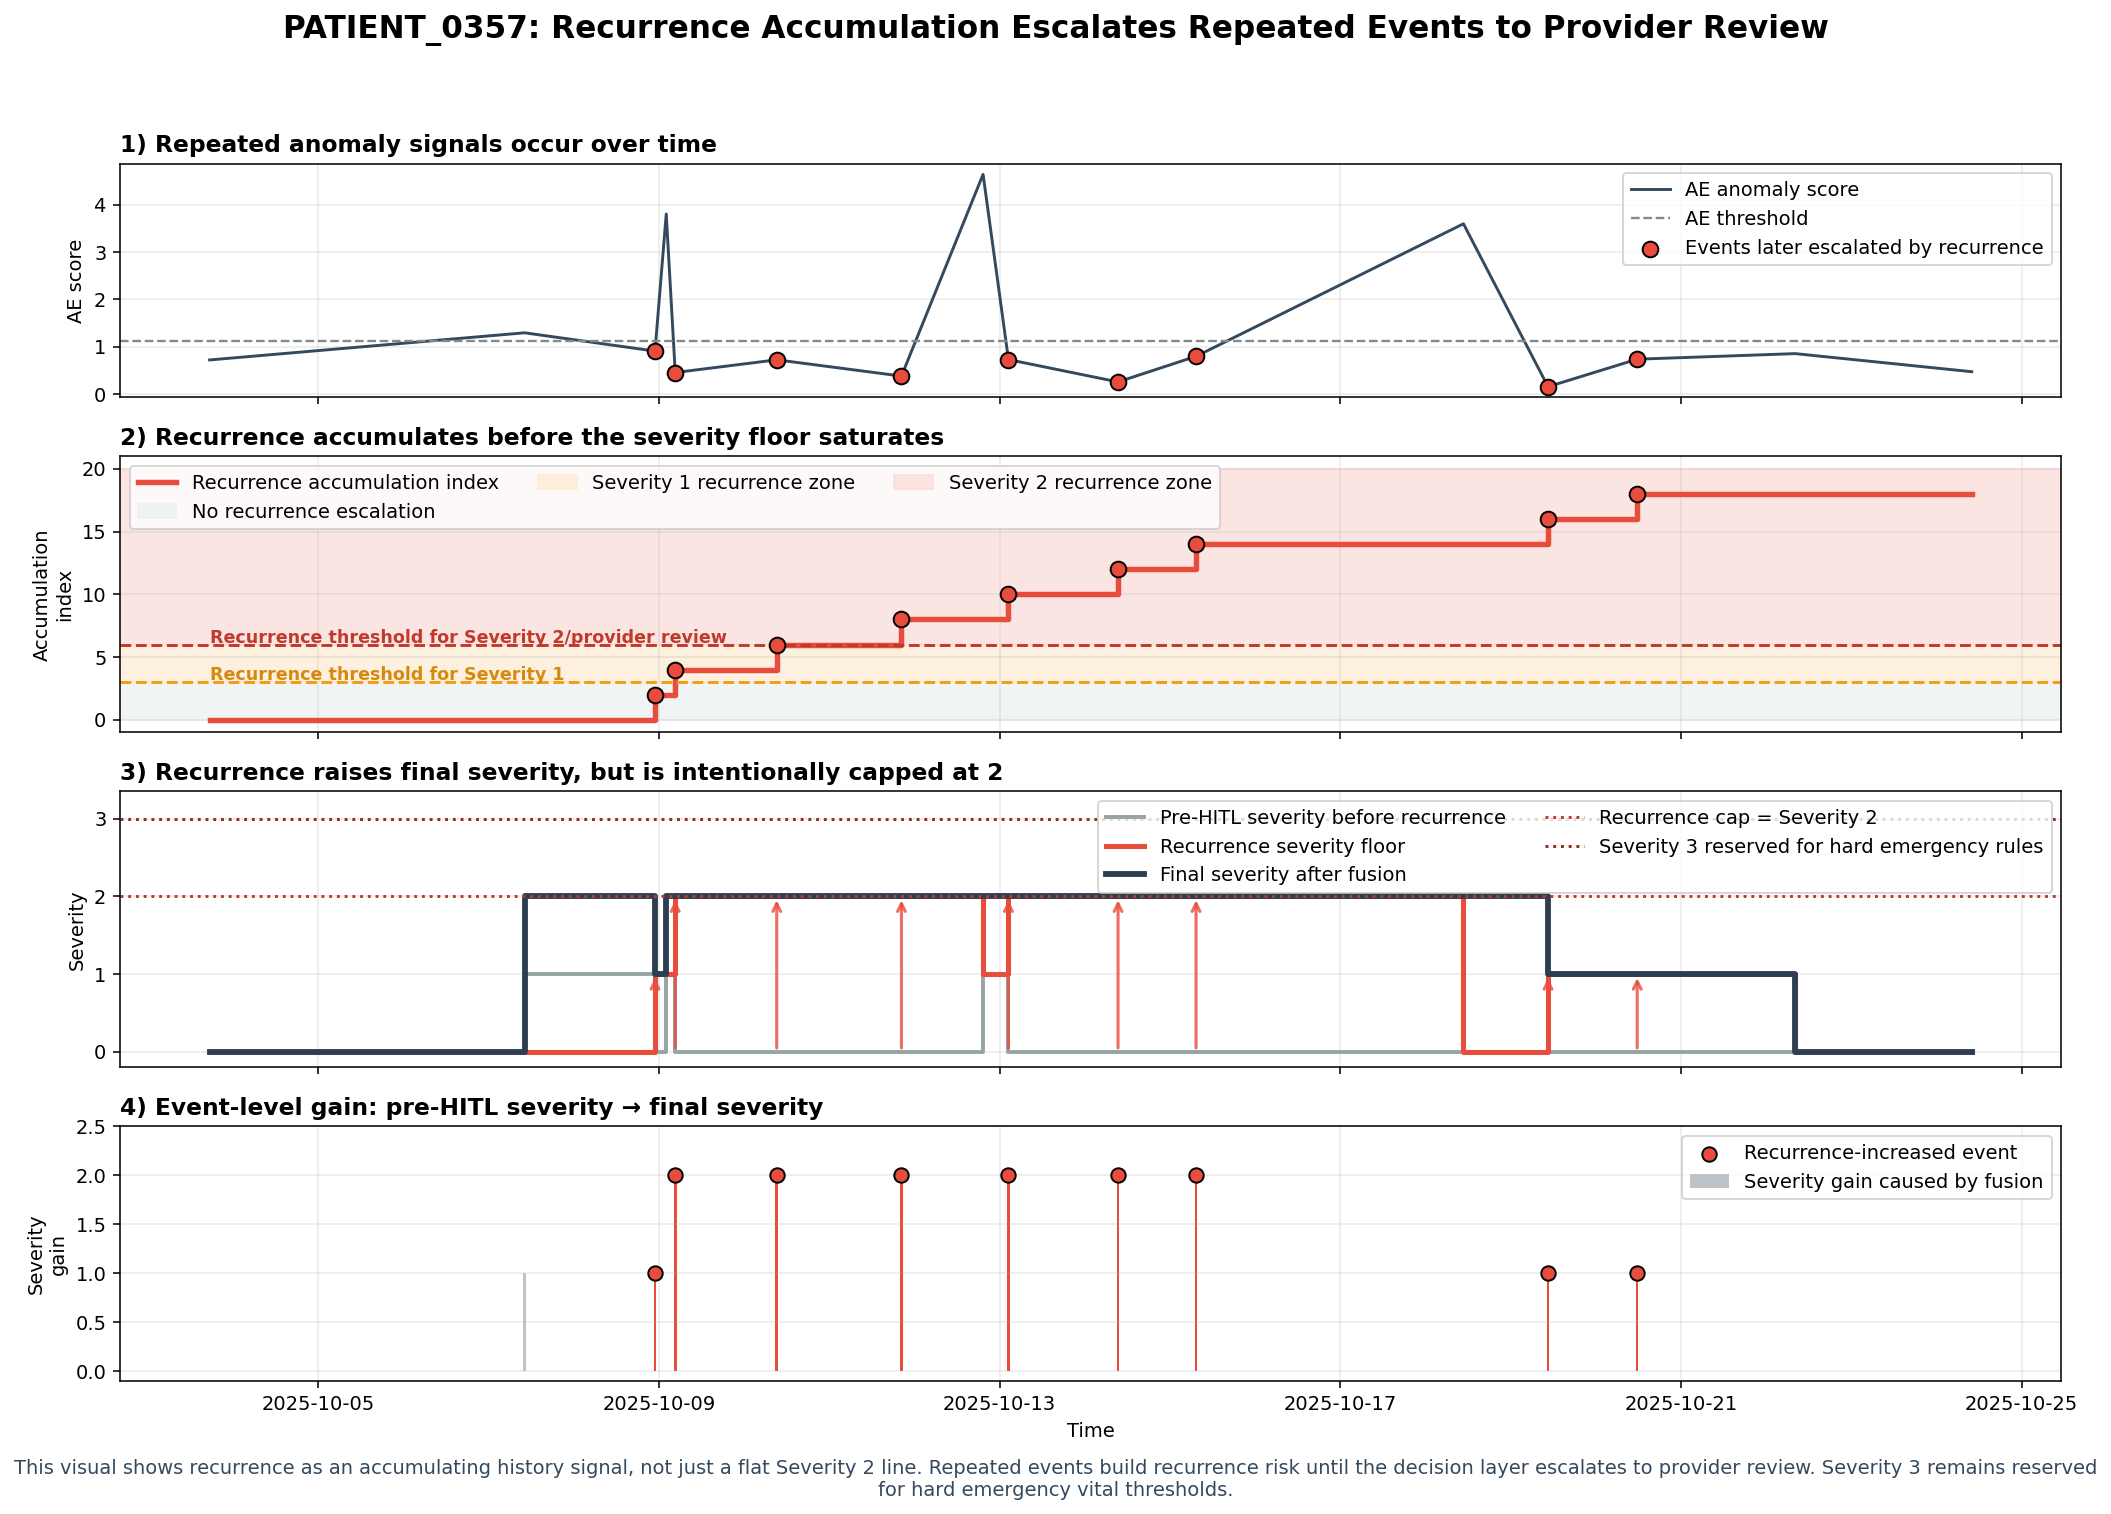

Saved: uc2_enhanced_decision_layer_outputs/figures/recurrence_patient_better\patient_0357_recurrence_accumulation_story.png


In [18]:
# BETTER RECURRENCE VISUAL
# Shows recurrence accumulation BEFORE the severity floor saturates at 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.size"] = 10

EVENTS_PATH = "uc2_enhanced_decision_layer_outputs/uc2_enhanced_decision_events.csv"
OUT_DIR = "uc2_enhanced_decision_layer_outputs/figures/recurrence_patient_better"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(EVENTS_PATH)

# Column setup

COL_PATIENT = "patient_id"
COL_TIME = "timestamp"
COL_PRE = "pre_hitl_severity"
COL_OBS = "observation_severity_floor"
COL_PERSONAL = "personalized_threshold_severity_floor"
COL_REC = "recurrence_severity_floor"
COL_POST = "post_hitl_severity"
COL_ROUTE = "notificationType"
COL_TYPE = "sensor_anomaly_type"
COL_SCORE = "anomalyScore"
COL_CAREGIVER = "caregiverResponses"

df[COL_TIME] = pd.to_datetime(df[COL_TIME], errors="coerce")

for c in [COL_PRE, COL_OBS, COL_PERSONAL, COL_REC, COL_POST, COL_SCORE]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

# Pick patient

selected_patient = "PATIENT_0357"

patient_df = (
    df[df[COL_PATIENT] == selected_patient]
    .copy()
    .sort_values(COL_TIME)
    .reset_index(drop=True)
)

print("Selected patient:", selected_patient)
print("Patient events:", len(patient_df))

# Identify recurrence-influenced events
# Clear recurrence impact:
# recurrence floor is above pre-HITL severity
# and final severity is higher than pre-HITL severity.

patient_df["recurrence_increased_severity"] = (
    (patient_df[COL_REC] > patient_df[COL_PRE]) &
    (patient_df[COL_POST] > patient_df[COL_PRE])
)

patient_df["severity_gain"] = patient_df[COL_POST] - patient_df[COL_PRE]

# Cumulative count of events where recurrence increased severity
patient_df["cumulative_recurrence_escalations"] = (
    patient_df["recurrence_increased_severity"].astype(int).cumsum()
)

# Approximate recurrence accumulation score for visualization.
# This is NOT replacing your real decision logic.
# It is just a visualization proxy to show accumulation over time.
#
# Your design says:
#   0-2   no change
#   3-5   floor 1
#   6-9   floor 2
#   >=10  floor 2 unless hard emergency/seizure urgent criteria
#
# Since the output file may only have the floor, not the raw recurrence score,
# this creates an interpretable "accumulation index" from repeated escalations.
patient_df["recurrence_accumulation_index"] = (
    patient_df["cumulative_recurrence_escalations"] * 2
)

# Determine threshold crossings for the visual
floor1_threshold = 3
floor2_threshold = 6

patient_df["visual_recurrence_floor_from_index"] = np.select(
    [
        patient_df["recurrence_accumulation_index"] >= floor2_threshold,
        patient_df["recurrence_accumulation_index"] >= floor1_threshold,
    ],
    [2, 1],
    default=0
)

recur_events = patient_df[patient_df["recurrence_increased_severity"]].copy()

print("Recurrence-increased events:", len(recur_events))

display_cols = [
    COL_PATIENT,
    COL_TIME,
    COL_SCORE,
    COL_TYPE,
    COL_PRE,
    COL_REC,
    COL_POST,
    "severity_gain",
    "cumulative_recurrence_escalations",
    "recurrence_accumulation_index",
    COL_ROUTE,
    COL_CAREGIVER,
]

display_cols = [c for c in display_cols if c in patient_df.columns]
display(recur_events[display_cols].head(15))

table_path = os.path.join(OUT_DIR, "patient_0357_recurrence_accumulation_events.csv")
recur_events[display_cols].to_csv(table_path, index=False)
print("Saved table:", table_path)

# FIGURE 1: Convincing recurrence accumulation story

fig, axes = plt.subplots(
    4, 1,
    figsize=(15, 11),
    sharex=True,
    gridspec_kw={"height_ratios": [1.1, 1.3, 1.3, 1.2]}
)

fig.suptitle(
    "PATIENT_0357: Recurrence Accumulation Escalates Repeated Events to Provider Review",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# Panel 1: AE score/event signal

ax = axes[0]

ax.plot(
    patient_df[COL_TIME],
    patient_df[COL_SCORE],
    color="#34495e",
    linewidth=1.5,
    label="AE anomaly score"
)

ax.axhline(
    1.129848,
    color="#7f8c8d",
    linestyle="--",
    linewidth=1.2,
    label="AE threshold"
)

ax.scatter(
    recur_events[COL_TIME],
    recur_events[COL_SCORE],
    color="#e74c3c",
    edgecolor="black",
    s=65,
    zorder=5,
    label="Events later escalated by recurrence"
)

ax.set_ylabel("AE score")
ax.set_title("1) Repeated anomaly signals occur over time", loc="left", fontweight="bold")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")

# Panel 2: Recurrence accumulation index

ax = axes[1]

ax.step(
    patient_df[COL_TIME],
    patient_df["recurrence_accumulation_index"],
    where="post",
    color="#e74c3c",
    linewidth=2.8,
    label="Recurrence accumulation index"
)

ax.axhspan(
    0,
    floor1_threshold,
    color="#ecf0f1",
    alpha=0.7,
    label="No recurrence escalation"
)

ax.axhspan(
    floor1_threshold,
    floor2_threshold,
    color="#fdebd0",
    alpha=0.7,
    label="Severity 1 recurrence zone"
)

ax.axhspan(
    floor2_threshold,
    max(patient_df["recurrence_accumulation_index"].max() + 2, floor2_threshold + 2),
    color="#fadbd8",
    alpha=0.7,
    label="Severity 2 recurrence zone"
)

ax.axhline(
    floor1_threshold,
    color="#f39c12",
    linestyle="--",
    linewidth=1.5
)

ax.axhline(
    floor2_threshold,
    color="#c0392b",
    linestyle="--",
    linewidth=1.5
)

ax.text(
    patient_df[COL_TIME].min(),
    floor1_threshold + 0.15,
    "Recurrence threshold for Severity 1",
    color="#d68910",
    fontsize=9,
    fontweight="bold"
)

ax.text(
    patient_df[COL_TIME].min(),
    floor2_threshold + 0.15,
    "Recurrence threshold for Severity 2/provider review",
    color="#c0392b",
    fontsize=9,
    fontweight="bold"
)

ax.scatter(
    recur_events[COL_TIME],
    recur_events["recurrence_accumulation_index"],
    color="#e74c3c",
    edgecolor="black",
    s=65,
    zorder=5
)

ax.set_ylabel("Accumulation\nindex")
ax.set_title(
    "2) Recurrence accumulates before the severity floor saturates",
    loc="left",
    fontweight="bold"
)
ax.grid(alpha=0.25)
ax.legend(loc="upper left", ncol=3)

# Panel 3: Severity before and after recurrence

ax = axes[2]

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_PRE],
    where="post",
    color="#95a5a6",
    linewidth=2,
    label="Pre-HITL severity before recurrence"
)

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_REC],
    where="post",
    color="#e74c3c",
    linewidth=2.6,
    label="Recurrence severity floor"
)

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_POST],
    where="post",
    color="#2c3e50",
    linewidth=3,
    label="Final severity after fusion"
)

# Draw escalation arrows for recurrence-increased events
for _, row in recur_events.iterrows():
    ax.annotate(
        "",
        xy=(row[COL_TIME], row[COL_POST]),
        xytext=(row[COL_TIME], row[COL_PRE]),
        arrowprops=dict(
            arrowstyle="->",
            color="#e74c3c",
            lw=1.6,
            alpha=0.8
        )
    )

ax.axhline(
    2,
    color="#c0392b",
    linestyle=":",
    linewidth=1.5,
    label="Recurrence cap = Severity 2"
)

ax.axhline(
    3,
    color="#922b21",
    linestyle=":",
    linewidth=1.5,
    label="Severity 3 reserved for hard emergency rules"
)

ax.set_ylim(-0.2, 3.35)
ax.set_yticks([0, 1, 2, 3])
ax.set_ylabel("Severity")
ax.set_title(
    "3) Recurrence raises final severity, but is intentionally capped at 2",
    loc="left",
    fontweight="bold"
)
ax.grid(alpha=0.25)
ax.legend(loc="upper right", ncol=2)

# Panel 4: Event-by-event severity gain

ax = axes[3]

gain_df = patient_df.copy()
gain_df["severity_gain_positive"] = gain_df["severity_gain"].clip(lower=0)

colors = np.where(
    gain_df["recurrence_increased_severity"],
    "#e74c3c",
    "#bdc3c7"
)

ax.bar(
    gain_df[COL_TIME],
    gain_df["severity_gain_positive"],
    color=colors,
    width=0.03,
    align="center",
    label="Severity gain caused by fusion"
)

ax.scatter(
    recur_events[COL_TIME],
    recur_events["severity_gain"],
    color="#e74c3c",
    edgecolor="black",
    s=55,
    zorder=5,
    label="Recurrence-increased event"
)

ax.set_ylim(-0.1, max(2.3, patient_df["severity_gain"].max() + 0.5))
ax.set_ylabel("Severity\ngain")
ax.set_title(
    "4) Event-level gain: pre-HITL severity → final severity",
    loc="left",
    fontweight="bold"
)
ax.grid(alpha=0.25)
ax.legend(loc="upper right")

axes[-1].set_xlabel("Time")

caption = (
    "This visual shows recurrence as an accumulating history signal, not just a flat Severity 2 line. "
    "Repeated events build recurrence risk until the decision layer escalates to provider review. "
    "Severity 3 remains reserved for hard emergency vital thresholds."
)

fig.text(
    0.5,
    0.015,
    caption,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#34495e",
    wrap=True
)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])

fig_path = os.path.join(
    OUT_DIR,
    "patient_0357_recurrence_accumulation_story.png"
)

plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [20]:
# FIND A MORE CONVINCING RECURRENCE EXAMPLE
# Criteria:
#   - recurrence increased final severity
#   - preferably not NORMAL_PATTERN
#   - preferably AE score above threshold
#   - preferably pre severity 1 -> final severity 2

import pandas as pd
import numpy as np

EVENTS_PATH = "uc2_enhanced_decision_layer_outputs/uc2_enhanced_decision_events.csv"

df = pd.read_csv(EVENTS_PATH)

# Column names
COL_PATIENT = "patient_id"
COL_TIME = "timestamp"
COL_SCORE = "anomalyScore"
COL_TYPE = "sensor_anomaly_type"
COL_PRE = "pre_hitl_severity"
COL_REC = "recurrence_severity_floor"
COL_POST = "post_hitl_severity"
COL_ROUTE = "notificationType"
COL_CAREGIVER = "caregiverResponses"

AE_THRESHOLD = 1.129848

df[COL_TIME] = pd.to_datetime(df[COL_TIME], errors="coerce")

for c in [COL_SCORE, COL_PRE, COL_REC, COL_POST]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

# Core recurrence-increased condition
df["recurrence_increased_severity"] = (
    (df[COL_REC] > df[COL_PRE]) &
    (df[COL_POST] > df[COL_PRE])
)

df["severity_gain"] = df[COL_POST] - df[COL_PRE]
df["ae_above_threshold"] = df[COL_SCORE] >= AE_THRESHOLD
df["non_normal_type"] = df[COL_TYPE] != "NORMAL_PATTERN"
df["ideal_1_to_2"] = (df[COL_PRE] == 1) & (df[COL_POST] == 2)
df["zero_to_two"] = (df[COL_PRE] == 0) & (df[COL_POST] == 2)

# Score each event for presentation usefulness
df["presentation_score"] = 0

df.loc[df["recurrence_increased_severity"], "presentation_score"] += 3
df.loc[df["non_normal_type"], "presentation_score"] += 4
df.loc[df["ae_above_threshold"], "presentation_score"] += 3
df.loc[df["ideal_1_to_2"], "presentation_score"] += 4
df.loc[df["zero_to_two"], "presentation_score"] += 1
df.loc[df[COL_ROUTE] == "SLM_SUMMARY_AND_PROVIDER_NOTE", "presentation_score"] += 2

# Penalize weak examples
df.loc[df[COL_TYPE] == "NORMAL_PATTERN", "presentation_score"] -= 3
df.loc[df[COL_SCORE] < AE_THRESHOLD, "presentation_score"] -= 1
df.loc[df[COL_CAREGIVER].astype(str).isin(["[]", "", "nan", "None"]), "presentation_score"] -= 1

candidates = df[df["recurrence_increased_severity"]].copy()

print("Total recurrence-increased events:", len(candidates))

# Show strongest individual events
strong_events = candidates.sort_values(
    by=[
        "presentation_score",
        "non_normal_type",
        "ae_above_threshold",
        "ideal_1_to_2",
        "severity_gain",
        COL_SCORE
    ],
    ascending=[False, False, False, False, False, False]
)

display_cols = [
    COL_PATIENT,
    COL_TIME,
    COL_SCORE,
    "ae_above_threshold",
    COL_TYPE,
    COL_PRE,
    COL_REC,
    COL_POST,
    "severity_gain",
    COL_ROUTE,
    COL_CAREGIVER,
    "presentation_score"
]

display(strong_events[display_cols].head(30))

# Rank patients by convincing recurrence examples
patient_rank = (
    candidates
    .groupby(COL_PATIENT)
    .agg(
        recurrence_increased_events=(COL_PATIENT, "count"),
        non_normal_recurrence_events=("non_normal_type", "sum"),
        ae_above_threshold_events=("ae_above_threshold", "sum"),
        ideal_1_to_2_events=("ideal_1_to_2", "sum"),
        max_presentation_score=("presentation_score", "max"),
        mean_presentation_score=("presentation_score", "mean"),
        max_severity_gain=("severity_gain", "max"),
        max_recurrence_floor=(COL_REC, "max"),
        max_post_severity=(COL_POST, "max"),
    )
    .reset_index()
    .sort_values(
        by=[
            "max_presentation_score",
            "non_normal_recurrence_events",
            "ae_above_threshold_events",
            "ideal_1_to_2_events",
            "recurrence_increased_events"
        ],
        ascending=[False, False, False, False, False]
    )
)

print("\nBest recurrence patients for presentation:")
display(patient_rank.head(20))

Total recurrence-increased events: 656


,patient_id,timestamp,anomalyScore,ae_above_threshold,sensor_anomaly_type,pre_hitl_severity,recurrence_severity_floor,post_hitl_severity,severity_gain,notificationType,caregiverResponses,presentation_score
3330,PATIENT_0151,2025-10-20 10:56:45.056387,1.402695,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""NOT_SURE""]",16
4964,PATIENT_0018,2025-10-29 22:00:45.056387,1.369177,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""BREATHING_DIFFERENT""]",16
3972,PATIENT_0003,2025-10-24 07:36:45.056387,1.286789,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""NOT_SURE""]",16
2963,PATIENT_0481,2025-10-18 11:35:45.056387,1.229272,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""BREATHING_DIFFERENT""]",16
4503,PATIENT_0045,2025-10-27 06:25:45.056387,1.221672,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""NOT_SURE""]",16
3045,PATIENT_0003,2025-10-18 22:17:45.056387,1.216943,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""BREATHING_DIFFERENT""]",16
4826,PATIENT_0045,2025-10-29 04:04:45.056387,1.159779,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""NOT_SURE""]",16
2920,PATIENT_0201,2025-10-18 05:33:45.056387,1.153837,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""NOT_SURE""]",16
1112,PATIENT_0072,2025-10-07 01:07:45.056387,1.152110,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""NOT_SURE""]",16
3591,PATIENT_0184,2025-10-22 00:16:45.056387,1.129900,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""BREATHING_DIFFERENT""]",16



Best recurrence patients for presentation:


,patient_id,recurrence_increased_events,non_normal_recurrence_events,ae_above_threshold_events,ideal_1_to_2_events,max_presentation_score,mean_presentation_score,max_severity_gain,max_recurrence_floor,max_post_severity
26,PATIENT_0045,4,2,2,2,16,7.000000,1,2,2
1,PATIENT_0003,3,2,2,2,16,11.000000,2,2,2
47,PATIENT_0072,7,1,1,1,16,0.571429,1,2,2
91,PATIENT_0151,7,1,1,1,16,1.428571,2,2,2
275,PATIENT_0481,4,1,1,1,16,2.500000,1,2,2
11,PATIENT_0018,2,1,1,1,16,7.000000,1,2,2
107,PATIENT_0184,2,1,1,1,16,7.000000,1,2,2
115,PATIENT_0201,2,1,1,1,16,7.000000,1,2,2
208,PATIENT_0357,9,0,0,0,1,0.000000,2,2,2
263,PATIENT_0461,6,0,0,0,1,-1.500000,2,2,2


Selected patient: PATIENT_0045
Total patient events: 14
Any recurrence-increased events: 4
Ideal recurrence escalation events: 2


,patient_id,timestamp,anomalyScore,ae_above_threshold,sensor_anomaly_type,pre_hitl_severity,recurrence_severity_floor,post_hitl_severity,severity_gain,notificationType,caregiverResponses,topFeatures
11,PATIENT_0045,2025-10-27 06:25:45.056387,1.221672,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""NOT_SURE""]","[{""feature"": ""body_temperature"", ""contribution..."
13,PATIENT_0045,2025-10-29 04:04:45.056387,1.159779,True,CARDIO_RESPIRATORY_SIGNAL_CHANGE,1,2,2,1,SLM_SUMMARY_AND_PROVIDER_NOTE,"[""NOT_SURE""]","[{""feature"": ""hrv_sdnn"", ""contribution"": 7.661..."


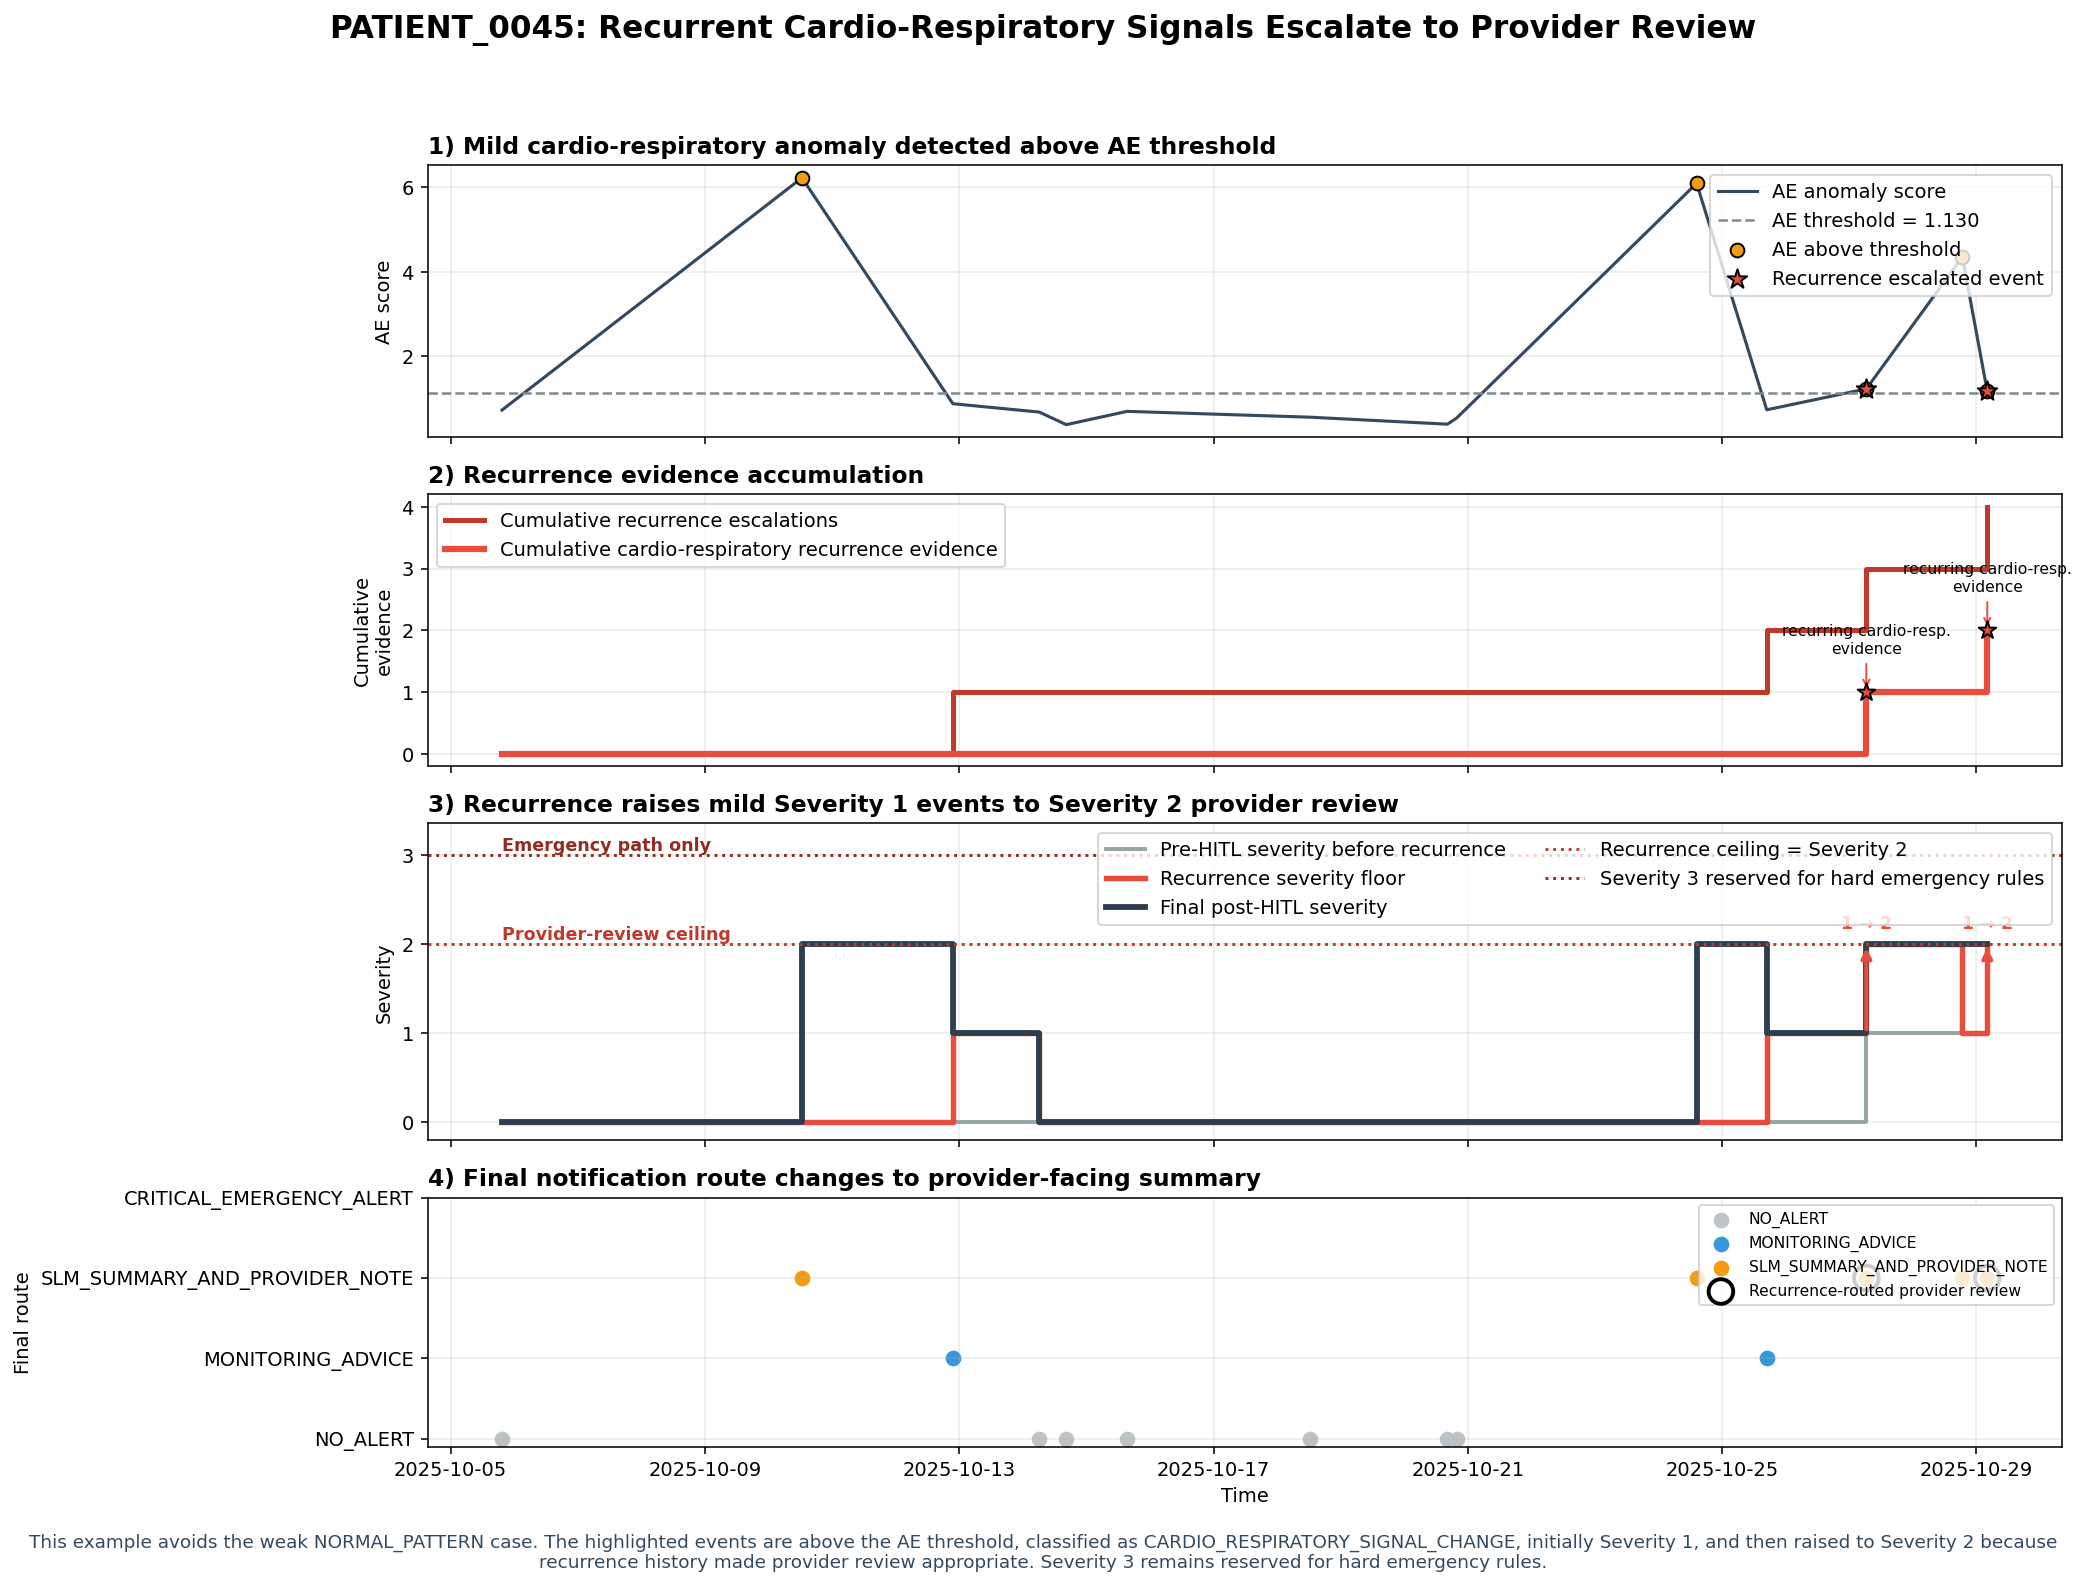

Saved figure: uc2_enhanced_decision_layer_outputs/figures/recurrence_patient_0045\patient_0045_recurrence_cardiorespiratory_escalation.png
Saved table: uc2_enhanced_decision_layer_outputs/figures/recurrence_patient_0045\patient_0045_ideal_recurrence_events.csv


In [24]:
# PRESENTATION-QUALITY RECURRENCE VISUAL
# Patient: PATIENT_0045
# Story: recurrent cardio-respiratory signals escalate from Severity 1 to 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.size"] = 10

EVENTS_PATH = "uc2_enhanced_decision_layer_outputs/uc2_enhanced_decision_events.csv"
OUT_DIR = "uc2_enhanced_decision_layer_outputs/figures/recurrence_patient_0045"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(EVENTS_PATH)

COL_PATIENT = "patient_id"
COL_TIME = "timestamp"
COL_SCORE = "anomalyScore"
COL_TYPE = "sensor_anomaly_type"
COL_PRE = "pre_hitl_severity"
COL_OBS = "observation_severity_floor"
COL_PERSONAL = "personalized_threshold_severity_floor"
COL_REC = "recurrence_severity_floor"
COL_POST = "post_hitl_severity"
COL_ROUTE = "notificationType"
COL_CAREGIVER = "caregiverResponses"
COL_TOP = "topFeatures"

AE_THRESHOLD = 1.129848
selected_patient = "PATIENT_0045"

df[COL_TIME] = pd.to_datetime(df[COL_TIME], errors="coerce")

for c in [COL_SCORE, COL_PRE, COL_OBS, COL_PERSONAL, COL_REC, COL_POST]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

patient_df = (
    df[df[COL_PATIENT] == selected_patient]
    .copy()
    .sort_values(COL_TIME)
    .reset_index(drop=True)
)

# Recurrence impact conditions
patient_df["ae_above_threshold"] = patient_df[COL_SCORE] >= AE_THRESHOLD
patient_df["non_normal_type"] = patient_df[COL_TYPE] != "NORMAL_PATTERN"

patient_df["recurrence_increased_severity"] = (
    (patient_df[COL_REC] > patient_df[COL_PRE]) &
    (patient_df[COL_POST] > patient_df[COL_PRE])
)

patient_df["ideal_recurrence_escalation"] = (
    patient_df["recurrence_increased_severity"] &
    patient_df["non_normal_type"] &
    patient_df["ae_above_threshold"] &
    (patient_df[COL_PRE] == 1) &
    (patient_df[COL_REC] == 2) &
    (patient_df[COL_POST] == 2)
)

patient_df["severity_gain"] = patient_df[COL_POST] - patient_df[COL_PRE]

# For visual accumulation, count the presentation-quality recurrence events
patient_df["cumulative_recurrence_evidence"] = (
    patient_df["ideal_recurrence_escalation"].astype(int).cumsum()
)

# Also count any recurrence-increased event
patient_df["cumulative_any_recurrence_escalation"] = (
    patient_df["recurrence_increased_severity"].astype(int).cumsum()
)

ideal_events = patient_df[patient_df["ideal_recurrence_escalation"]].copy()
recur_events = patient_df[patient_df["recurrence_increased_severity"]].copy()

print("Selected patient:", selected_patient)
print("Total patient events:", len(patient_df))
print("Any recurrence-increased events:", len(recur_events))
print("Ideal recurrence escalation events:", len(ideal_events))

display_cols = [
    COL_PATIENT,
    COL_TIME,
    COL_SCORE,
    "ae_above_threshold",
    COL_TYPE,
    COL_PRE,
    COL_REC,
    COL_POST,
    "severity_gain",
    COL_ROUTE,
    COL_CAREGIVER,
    COL_TOP
]

display_cols = [c for c in display_cols if c in patient_df.columns]
display(ideal_events[display_cols])

table_path = os.path.join(OUT_DIR, "patient_0045_ideal_recurrence_events.csv")
ideal_events[display_cols].to_csv(table_path, index=False)

# FIGURE: recurrence effect without misleading flatline

fig, axes = plt.subplots(
    4, 1,
    figsize=(15, 11.5),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1.2, 1.4, 1.1]}
)

fig.suptitle(
    "PATIENT_0045: Recurrent Cardio-Respiratory Signals Escalate to Provider Review",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# Panel 1: AE score with threshold and highlighted recurrence events

ax = axes[0]

ax.plot(
    patient_df[COL_TIME],
    patient_df[COL_SCORE],
    color="#34495e",
    linewidth=1.6,
    label="AE anomaly score"
)

ax.axhline(
    AE_THRESHOLD,
    color="#7f8c8d",
    linestyle="--",
    linewidth=1.3,
    label=f"AE threshold = {AE_THRESHOLD:.3f}"
)

# Mark all above-threshold points
above_df = patient_df[patient_df["ae_above_threshold"]]
ax.scatter(
    above_df[COL_TIME],
    above_df[COL_SCORE],
    color="#f39c12",
    edgecolor="black",
    s=50,
    zorder=4,
    label="AE above threshold"
)

# Highlight ideal recurrence events
ax.scatter(
    ideal_events[COL_TIME],
    ideal_events[COL_SCORE],
    color="#e74c3c",
    edgecolor="black",
    s=110,
    marker="*",
    zorder=6,
    label="Recurrence escalated event"
)

ax.set_ylabel("AE score")
ax.set_title(
    "1) Mild cardio-respiratory anomaly detected above AE threshold",
    loc="left",
    fontweight="bold"
)
ax.grid(alpha=0.25)
ax.legend(loc="upper right")

# Panel 2: Recurrence evidence accumulation

ax = axes[1]

ax.step(
    patient_df[COL_TIME],
    patient_df["cumulative_any_recurrence_escalation"],
    where="post",
    color="#c0392b",
    linewidth=2.6,
    label="Cumulative recurrence escalations"
)

ax.step(
    patient_df[COL_TIME],
    patient_df["cumulative_recurrence_evidence"],
    where="post",
    color="#e74c3c",
    linewidth=3.2,
    label="Cumulative cardio-respiratory recurrence evidence"
)

ax.scatter(
    ideal_events[COL_TIME],
    ideal_events["cumulative_recurrence_evidence"],
    color="#e74c3c",
    edgecolor="black",
    s=90,
    marker="*",
    zorder=5
)

for _, row in ideal_events.iterrows():
    ax.annotate(
        "recurring cardio-resp.\nevidence",
        xy=(row[COL_TIME], row["cumulative_recurrence_evidence"]),
        xytext=(0, 20),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1)
    )

ax.set_ylabel("Cumulative\nevidence")
ax.set_title(
    "2) Recurrence evidence accumulation",
    loc="left",
    fontweight="bold"
)
ax.grid(alpha=0.25)
ax.legend(loc="upper left")

# Panel 3: Severity before recurrence vs after recurrence

ax = axes[2]

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_PRE],
    where="post",
    color="#95a5a6",
    linewidth=2,
    label="Pre-HITL severity before recurrence"
)

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_REC],
    where="post",
    color="#e74c3c",
    linewidth=2.8,
    label="Recurrence severity floor"
)

ax.step(
    patient_df[COL_TIME],
    patient_df[COL_POST],
    where="post",
    color="#2c3e50",
    linewidth=3,
    label="Final post-HITL severity"
)

# Draw arrows specifically on ideal recurrence events: 1 -> 2
for _, row in ideal_events.iterrows():
    ax.annotate(
        "",
        xy=(row[COL_TIME], row[COL_POST]),
        xytext=(row[COL_TIME], row[COL_PRE]),
        arrowprops=dict(
            arrowstyle="->",
            color="#e74c3c",
            lw=2.2
        )
    )
    ax.text(
        row[COL_TIME],
        2.13,
        "1 → 2",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#e74c3c",
        fontweight="bold"
    )

ax.axhline(
    2,
    color="#c0392b",
    linestyle=":",
    linewidth=1.5,
    label="Recurrence ceiling = Severity 2"
)

ax.axhline(
    3,
    color="#922b21",
    linestyle=":",
    linewidth=1.5,
    label="Severity 3 reserved for hard emergency rules"
)

ax.text(
    patient_df[COL_TIME].min(),
    2.05,
    "Provider-review ceiling",
    color="#c0392b",
    fontsize=9,
    fontweight="bold"
)

ax.text(
    patient_df[COL_TIME].min(),
    3.05,
    "Emergency path only",
    color="#922b21",
    fontsize=9,
    fontweight="bold"
)

ax.set_ylim(-0.2, 3.35)
ax.set_yticks([0, 1, 2, 3])
ax.set_ylabel("Severity")
ax.set_title(
    "3) Recurrence raises mild Severity 1 events to Severity 2 provider review",
    loc="left",
    fontweight="bold"
)
ax.grid(alpha=0.25)
ax.legend(loc="upper right", ncol=2)

# Panel 4: Final route strip

ax = axes[3]

route_colors = {
    "NO_ALERT": "#bdc3c7",
    "MONITORING_ADVICE": "#3498db",
    "SLM_SUMMARY_AND_PROVIDER_NOTE": "#f39c12",
    "CRITICAL_EMERGENCY_ALERT": "#e74c3c",
}

if COL_ROUTE in patient_df.columns:
    route_order = [
        "NO_ALERT",
        "MONITORING_ADVICE",
        "SLM_SUMMARY_AND_PROVIDER_NOTE",
        "CRITICAL_EMERGENCY_ALERT",
    ]
    route_to_y = {r: i for i, r in enumerate(route_order)}

    patient_df["_route_y"] = patient_df[COL_ROUTE].map(route_to_y).fillna(-1)

    for route in route_order:
        sub = patient_df[patient_df[COL_ROUTE] == route]
        if len(sub) > 0:
            ax.scatter(
                sub[COL_TIME],
                sub["_route_y"],
                color=route_colors.get(route, "#7f8c8d"),
                s=50,
                label=route
            )

    ax.scatter(
        ideal_events[COL_TIME],
        ideal_events[COL_ROUTE].map(route_to_y),
        facecolor="none",
        edgecolor="black",
        s=160,
        linewidth=2,
        label="Recurrence-routed provider review"
    )

    ax.set_yticks(list(route_to_y.values()))
    ax.set_yticklabels(route_order)
    ax.set_ylabel("Final route")

else:
    ax.scatter(
        patient_df[COL_TIME],
        patient_df[COL_POST],
        color="#2c3e50"
    )
    ax.set_ylabel("Final severity")

ax.set_title(
    "4) Final notification route changes to provider-facing summary",
    loc="left",
    fontweight="bold"
)
ax.grid(alpha=0.25)
ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time")

caption = (
    "This example avoids the weak NORMAL_PATTERN case. The highlighted events are above the AE threshold, "
    "classified as CARDIO_RESPIRATORY_SIGNAL_CHANGE, initially Severity 1, and then raised to Severity 2 "
    "because recurrence history made provider review appropriate. Severity 3 remains reserved for hard emergency rules."
)

fig.text(
    0.5,
    0.012,
    caption,
    ha="center",
    va="bottom",
    fontsize=9.5,
    color="#34495e",
    wrap=True
)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])

fig_path = os.path.join(
    OUT_DIR,
    "patient_0045_recurrence_cardiorespiratory_escalation.png"
)

plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)
print("Saved table:", table_path)

In [28]:
# Synthetic FHIR R4 EHR Generator — More Realistic Visit Spacing
# Patients:
#   1. James Okafor, 67, Post-stroke rehabilitation
#   2. Sofia Reyes, 22, Spina Bifida
#
# Generates:
#   - 30 clinical visits per patient
#   - More realistic timestamps:
#       James: ~15-18 months, frequent rehab early, then spaced follow-ups
#       Sofia: ~24-30 months, routine chronic-care visits + flare clusters
#   - FHIR R4 Bundle JSON files
#   - Visit summary CSVs
#
# Output folder:
#   synthetic_fhir_ehr_realistic/

import os
import json
import uuid
import random
from datetime import datetime, timedelta, timezone
from typing import Dict, List, Any

import pandas as pd

# CONFIG

random.seed(42)

OUT_DIR = "synthetic_fhir_ehr_realistic"
CSV_DIR = os.path.join(OUT_DIR, "visit_summary_tables")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

NOW = datetime.now(timezone.utc)

FHIR_VERSION = "4.0.1"

ORGANIZATION_ID = "org-access-dp-demo"
PRACTITIONER_REHAB_ID = "practitioner-rehab-001"
PRACTITIONER_PRIMARY_ID = "practitioner-primary-001"
PRACTITIONER_NEURO_ID = "practitioner-neuro-001"
PRACTITIONER_URO_ID = "practitioner-uro-001"

def new_id(prefix: str) -> str:
    return f"{prefix}-{uuid.uuid4().hex[:12]}"

def iso(dt: datetime) -> str:
    return dt.isoformat()

def date_only(dt: datetime) -> str:
    return dt.date().isoformat()

def ref(resource_type: str, resource_id: str) -> str:
    return f"{resource_type}/{resource_id}"

def coding(system: str, code: str, display: str) -> Dict[str, str]:
    return {
        "system": system,
        "code": code,
        "display": display
    }

def codeable_concept(system: str, code: str, display: str, text: str = None) -> Dict[str, Any]:
    return {
        "coding": [coding(system, code, display)],
        "text": text or display
    }

def make_quantity(value, unit, system="http://unitsofmeasure.org", code=None):
    return {
        "value": round(float(value), 2),
        "unit": unit,
        "system": system,
        "code": code or unit
    }

def make_bundle(bundle_id: str, resources: List[Dict[str, Any]]) -> Dict[str, Any]:
    return {
        "resourceType": "Bundle",
        "id": bundle_id,
        "meta": {
            "profile": [
                "http://hl7.org/fhir/StructureDefinition/Bundle"
            ],
            "tag": [
                {
                    "system": "https://access-dp.local/fhir/tags",
                    "code": "synthetic-demo-data",
                    "display": "Synthetic demo data - not real PHI"
                }
            ]
        },
        "type": "collection",
        "timestamp": iso(NOW),
        "entry": [
            {
                "fullUrl": f"urn:uuid:{r['id']}",
                "resource": r
            }
            for r in resources
        ]
    }

def make_observation(
    obs_id: str,
    patient_id: str,
    encounter_id: str,
    code: str,
    display: str,
    value,
    unit: str,
    effective_dt: datetime,
    category: str = "vital-signs",
    loinc: bool = True,
    interpretation: str = None
) -> Dict[str, Any]:

    obs = {
        "resourceType": "Observation",
        "id": obs_id,
        "status": "final",
        "category": [
            {
                "coding": [
                    coding(
                        "http://terminology.hl7.org/CodeSystem/observation-category",
                        category,
                        category.replace("-", " ").title()
                    )
                ]
            }
        ],
        "code": codeable_concept(
            "http://loinc.org" if loinc else "https://access-dp.local/fhir/CodeSystem/custom-observations",
            code,
            display
        ),
        "subject": {
            "reference": ref("Patient", patient_id)
        },
        "encounter": {
            "reference": ref("Encounter", encounter_id)
        },
        "effectiveDateTime": iso(effective_dt),
        "issued": iso(effective_dt + timedelta(minutes=5)),
        "valueQuantity": make_quantity(value, unit)
    }

    if interpretation:
        obs["interpretation"] = [
            codeable_concept(
                "http://terminology.hl7.org/CodeSystem/v3-ObservationInterpretation",
                interpretation,
                interpretation
            )
        ]

    return obs

def make_string_observation(
    obs_id: str,
    patient_id: str,
    encounter_id: str,
    code: str,
    display: str,
    value: str,
    effective_dt: datetime,
    category: str = "survey"
) -> Dict[str, Any]:

    return {
        "resourceType": "Observation",
        "id": obs_id,
        "status": "final",
        "category": [
            {
                "coding": [
                    coding(
                        "http://terminology.hl7.org/CodeSystem/observation-category",
                        category,
                        category.title()
                    )
                ]
            }
        ],
        "code": codeable_concept(
            "https://access-dp.local/fhir/CodeSystem/custom-observations",
            code,
            display
        ),
        "subject": {
            "reference": ref("Patient", patient_id)
        },
        "encounter": {
            "reference": ref("Encounter", encounter_id)
        },
        "effectiveDateTime": iso(effective_dt),
        "valueString": value
    }

def make_document_reference(
    doc_id: str,
    patient_id: str,
    encounter_id: str,
    authored_dt: datetime,
    title: str,
    note_text: str
) -> Dict[str, Any]:

    return {
        "resourceType": "DocumentReference",
        "id": doc_id,
        "status": "current",
        "docStatus": "final",
        "type": codeable_concept(
            "http://loinc.org",
            "11506-3",
            "Progress note",
            "Clinical progress note"
        ),
        "subject": {
            "reference": ref("Patient", patient_id)
        },
        "date": iso(authored_dt),
        "author": [
            {
                "reference": ref("Practitioner", PRACTITIONER_PRIMARY_ID),
                "display": "Dr. Primary Demo"
            }
        ],
        "context": {
            "encounter": [
                {
                    "reference": ref("Encounter", encounter_id)
                }
            ]
        },
        "content": [
            {
                "attachment": {
                    "contentType": "text/plain",
                    "title": title,
                    "data": note_text
                }
            }
        ],
        "description": title
    }

# REALISTIC VISIT DATE GENERATION

def generate_james_visit_dates(n_visits: int = 30, end_date: datetime = NOW):
    """
    Realistic post-stroke rehab timeline.

    Produces 30 visits spread over roughly 15-18 months:
      - early phase: more frequent rehab
      - middle phase: every 2-4 weeks
      - later phase: monthly/quarterly follow-up
    """

    intervals_days = []

    for i in range(n_visits - 1):
        if i < 8:
            # Early post-stroke rehab period
            intervals_days.append(random.randint(7, 14))
        elif i < 18:
            # Subacute rehab / care management
            intervals_days.append(random.randint(14, 30))
        else:
            # Longer-term maintenance, PCP, neurology follow-ups
            intervals_days.append(random.randint(30, 75))

    total_days = sum(intervals_days)
    start_date = end_date - timedelta(days=total_days)

    dates = [start_date]

    for interval in intervals_days:
        dates.append(dates[-1] + timedelta(days=interval))

    adjusted_dates = []
    for dt in dates:
        adjusted_dates.append(
            dt.replace(
                hour=random.choice([8, 9, 10, 11, 13, 14, 15]),
                minute=random.choice([0, 15, 30, 45]),
                second=0,
                microsecond=0
            )
        )

    return adjusted_dates

def generate_sofia_visit_dates(n_visits: int = 30, end_date: datetime = NOW):
    """
    Realistic Spina Bifida timeline.

    Produces 30 visits spread over roughly 24-30 months:
      - routine chronic care/urology/primary visits every 1.5-4 months
      - occasional symptom flare clusters 3-12 days apart
    """

    dates = []

    # Start around 2.2-2.6 years ago
    current = end_date - timedelta(days=random.randint(800, 950))

    # Flare clusters: visit pairs close together
    flare_indices = set([6, 7, 15, 16, 23, 24])

    for i in range(n_visits):
        if i == 0:
            dates.append(current)
            continue

        if i in flare_indices:
            # Clustered follow-up after possible UTI/GI/mobility flare
            delta_days = random.randint(3, 12)
        else:
            # Routine chronic care spacing
            delta_days = random.randint(45, 120)

        current = current + timedelta(days=delta_days)

        # Ensure timeline does not go into future
        if current > end_date:
            current = end_date - timedelta(days=random.randint(1, 25))

        dates.append(current)

    dates = sorted(dates)

    adjusted_dates = []
    for dt in dates:
        adjusted_dates.append(
            dt.replace(
                hour=random.choice([8, 9, 10, 11, 13, 14, 15]),
                minute=random.choice([0, 15, 30, 45]),
                second=0,
                microsecond=0
            )
        )

    return adjusted_dates

# SHARED FHIR RESOURCES

def make_organization() -> Dict[str, Any]:
    return {
        "resourceType": "Organization",
        "id": ORGANIZATION_ID,
        "active": True,
        "name": "ACCESS-DP Synthetic Rural Health Clinic",
        "type": [
            codeable_concept(
                "http://terminology.hl7.org/CodeSystem/organization-type",
                "prov",
                "Healthcare Provider"
            )
        ],
        "address": [
            {
                "line": ["100 Demo Care Way"],
                "city": "Frederick",
                "state": "MD",
                "postalCode": "21701",
                "country": "US"
            }
        ]
    }

def make_practitioner(practitioner_id: str, name: str, specialty: str) -> Dict[str, Any]:
    return {
        "resourceType": "Practitioner",
        "id": practitioner_id,
        "active": True,
        "name": [
            {
                "use": "official",
                "text": name,
                "family": name.split()[-1],
                "given": name.split()[:-1]
            }
        ],
        "qualification": [
            {
                "code": {
                    "text": specialty
                }
            }
        ]
    }

def shared_resources() -> List[Dict[str, Any]]:
    return [
        make_organization(),
        make_practitioner(PRACTITIONER_PRIMARY_ID, "Ethan Patel MD", "Primary Care"),
        make_practitioner(PRACTITIONER_REHAB_ID, "Maya Brooks DPT", "Physical Therapy"),
        make_practitioner(PRACTITIONER_NEURO_ID, "Priya Shah MD", "Neurology"),
        make_practitioner(PRACTITIONER_URO_ID, "Laura Kim MD", "Urology")
    ]

# PATIENT RESOURCES

def make_patient_james() -> Dict[str, Any]:
    return {
        "resourceType": "Patient",
        "id": "patient-james-okafor",
        "identifier": [
            {
                "system": "https://access-dp.local/patient-id",
                "value": "ACCESS-JAMES-OKAFOR-001"
            }
        ],
        "active": True,
        "name": [
            {
                "use": "official",
                "family": "Okafor",
                "given": ["James"],
                "text": "James Okafor"
            }
        ],
        "gender": "male",
        "birthDate": "1958-04-12",
        "address": [
            {
                "line": ["Synthetic rural home address"],
                "city": "Frederick",
                "state": "MD",
                "postalCode": "21702",
                "country": "US"
            }
        ],
        "telecom": [
            {
                "system": "phone",
                "value": "555-0101",
                "use": "home"
            }
        ],
        "contact": [
            {
                "relationship": [
                    codeable_concept(
                        "http://terminology.hl7.org/CodeSystem/v2-0131",
                        "C",
                        "Emergency Contact",
                        "Wife / caregiver"
                    )
                ],
                "name": {
                    "family": "Okafor",
                    "given": ["Diane"],
                    "text": "Diane Okafor"
                },
                "telecom": [
                    {
                        "system": "phone",
                        "value": "555-0102"
                    }
                ]
            }
        ]
    }

def make_patient_sofia() -> Dict[str, Any]:
    return {
        "resourceType": "Patient",
        "id": "patient-sofia-reyes",
        "identifier": [
            {
                "system": "https://access-dp.local/patient-id",
                "value": "ACCESS-SOFIA-REYES-001"
            }
        ],
        "active": True,
        "name": [
            {
                "use": "official",
                "family": "Reyes",
                "given": ["Sofia"],
                "text": "Sofia Reyes"
            }
        ],
        "gender": "female",
        "birthDate": "2003-09-18",
        "address": [
            {
                "line": ["Synthetic home address"],
                "city": "Frederick",
                "state": "MD",
                "postalCode": "21703",
                "country": "US"
            }
        ],
        "telecom": [
            {
                "system": "phone",
                "value": "555-0201",
                "use": "mobile"
            }
        ],
        "contact": [
            {
                "relationship": [
                    codeable_concept(
                        "http://terminology.hl7.org/CodeSystem/v2-0131",
                        "C",
                        "Emergency Contact",
                        "Family caregiver"
                    )
                ],
                "name": {
                    "family": "Reyes",
                    "given": ["Marco"],
                    "text": "Marco Reyes"
                },
                "telecom": [
                    {
                        "system": "phone",
                        "value": "555-0202"
                    }
                ]
            }
        ]
    }

# CONDITIONS

def make_condition(
    condition_id: str,
    patient_id: str,
    code: str,
    display: str,
    onset_date: str,
    clinical_status: str = "active",
    verification_status: str = "confirmed",
    system: str = "http://snomed.info/sct"
) -> Dict[str, Any]:

    return {
        "resourceType": "Condition",
        "id": condition_id,
        "clinicalStatus": codeable_concept(
            "http://terminology.hl7.org/CodeSystem/condition-clinical",
            clinical_status,
            clinical_status.title()
        ),
        "verificationStatus": codeable_concept(
            "http://terminology.hl7.org/CodeSystem/condition-ver-status",
            verification_status,
            verification_status.title()
        ),
        "category": [
            codeable_concept(
                "http://terminology.hl7.org/CodeSystem/condition-category",
                "problem-list-item",
                "Problem List Item"
            )
        ],
        "code": codeable_concept(system, code, display),
        "subject": {
            "reference": ref("Patient", patient_id)
        },
        "onsetDateTime": onset_date,
        "recordedDate": onset_date
    }

def james_conditions(patient_id: str) -> List[Dict[str, Any]]:
    return [
        make_condition(
            "condition-james-stroke-history",
            patient_id,
            "230690007",
            "Cerebrovascular accident",
            "2024-12-14"
        ),
        make_condition(
            "condition-james-hemiparesis",
            patient_id,
            "278286009",
            "Hemiparesis as late effect of cerebrovascular accident",
            "2024-12-15"
        ),
        make_condition(
            "condition-james-hypertension",
            patient_id,
            "38341003",
            "Hypertensive disorder",
            "2018-03-01"
        ),
        make_condition(
            "condition-james-hyperlipidemia",
            patient_id,
            "55822004",
            "Hyperlipidemia",
            "2019-06-10"
        ),
        make_condition(
            "condition-james-gait-abnormality",
            patient_id,
            "22325002",
            "Abnormal gait",
            "2025-01-02"
        )
    ]

def sofia_conditions(patient_id: str) -> List[Dict[str, Any]]:
    return [
        make_condition(
            "condition-sofia-spina-bifida",
            patient_id,
            "67531005",
            "Spina bifida",
            "2003-09-18"
        ),
        make_condition(
            "condition-sofia-neurogenic-bladder",
            patient_id,
            "398064005",
            "Neurogenic bladder",
            "2006-04-12"
        ),
        make_condition(
            "condition-sofia-neurogenic-bowel",
            patient_id,
            "425671009",
            "Neurogenic bowel",
            "2007-01-20"
        ),
        make_condition(
            "condition-sofia-mobility-impairment",
            patient_id,
            "82971005",
            "Impaired mobility",
            "2011-05-01"
        ),
        make_condition(
            "condition-sofia-recurrent-uti-risk",
            patient_id,
            "197927001",
            "Recurrent urinary tract infection",
            "2018-08-12"
        )
    ]

# MEDICATIONS

def make_medication_request(
    med_id: str,
    patient_id: str,
    authored_on: str,
    medication_text: str,
    dose_text: str,
    status: str = "active",
    intent: str = "order"
) -> Dict[str, Any]:

    return {
        "resourceType": "MedicationRequest",
        "id": med_id,
        "status": status,
        "intent": intent,
        "medicationCodeableConcept": {
            "text": medication_text
        },
        "subject": {
            "reference": ref("Patient", patient_id)
        },
        "authoredOn": authored_on,
        "requester": {
            "reference": ref("Practitioner", PRACTITIONER_PRIMARY_ID)
        },
        "dosageInstruction": [
            {
                "text": dose_text
            }
        ]
    }

def james_medications(patient_id: str) -> List[Dict[str, Any]]:
    return [
        make_medication_request(
            "med-james-aspirin",
            patient_id,
            "2025-01-03",
            "Aspirin 81 mg oral tablet",
            "Take 1 tablet by mouth once daily"
        ),
        make_medication_request(
            "med-james-atorvastatin",
            patient_id,
            "2025-01-03",
            "Atorvastatin 40 mg oral tablet",
            "Take 1 tablet by mouth nightly"
        ),
        make_medication_request(
            "med-james-lisinopril",
            patient_id,
            "2025-01-03",
            "Lisinopril 10 mg oral tablet",
            "Take 1 tablet by mouth once daily"
        ),
        make_medication_request(
            "med-james-baclofen-prn",
            patient_id,
            "2025-02-01",
            "Baclofen 5 mg oral tablet",
            "Take 1 tablet up to twice daily as needed for spasticity"
        )
    ]

def sofia_medications(patient_id: str) -> List[Dict[str, Any]]:
    return [
        make_medication_request(
            "med-sofia-oxybutynin",
            patient_id,
            "2025-01-05",
            "Oxybutynin extended release 10 mg oral tablet",
            "Take 1 tablet by mouth once daily for bladder spasticity"
        ),
        make_medication_request(
            "med-sofia-polyethylene-glycol",
            patient_id,
            "2025-01-05",
            "Polyethylene glycol 17 gram oral powder",
            "Take 17 grams by mouth daily as needed for bowel regimen"
        ),
        make_medication_request(
            "med-sofia-nitrofurantoin-standby",
            patient_id,
            "2025-03-15",
            "Nitrofurantoin 100 mg oral capsule",
            "Use only if prescribed for suspected UTI after clinician contact",
            status="active"
        )
    ]

# CARE PLANS

def make_care_plan(
    care_plan_id: str,
    patient_id: str,
    title: str,
    description: str,
    activities: List[str]
) -> Dict[str, Any]:

    return {
        "resourceType": "CarePlan",
        "id": care_plan_id,
        "status": "active",
        "intent": "plan",
        "title": title,
        "description": description,
        "subject": {
            "reference": ref("Patient", patient_id)
        },
        "period": {
            "start": "2025-01-01"
        },
        "careTeam": [
            {
                "reference": ref("Practitioner", PRACTITIONER_PRIMARY_ID)
            }
        ],
        "activity": [
            {
                "detail": {
                    "kind": "ServiceRequest",
                    "status": "in-progress",
                    "description": activity
                }
            }
            for activity in activities
        ]
    }

def james_care_plan(patient_id: str) -> Dict[str, Any]:
    return make_care_plan(
        "careplan-james-post-stroke-rehab",
        patient_id,
        "Post-stroke rehabilitation plan",
        "Home-assisted post-stroke rehabilitation plan focused on gait, shoulder range of motion, grip strength, fall prevention, and blood pressure control.",
        [
            "Physical therapy with daily home exercise logging during active rehab periods",
            "Monitor gait speed, shoulder range of motion, grip strength, balance, and fatigue",
            "Blood pressure monitoring at home at least 3 times weekly",
            "Assess for new weakness, speech change, confusion, falls, or worsening spasticity",
            "Caregiver-assisted fall-risk mitigation and medication adherence review"
        ]
    )

def sofia_care_plan(patient_id: str) -> Dict[str, Any]:
    return make_care_plan(
        "careplan-sofia-spina-bifida-support",
        patient_id,
        "Spina Bifida home monitoring and autonomic/GI/GU support plan",
        "Home-assisted monitoring plan for Spina Bifida with neurogenic bladder/bowel, mobility support, hydration, GI symptoms, and UTI risk surveillance.",
        [
            "Track vomiting, reduced intake, bowel routine changes, urinary symptoms, fever, and fatigue",
            "Monitor heart rate, mobility, sleep, hydration, pain, and caregiver observations",
            "Maintain bladder catheterization schedule as directed by urology",
            "Continue bowel regimen and monitor constipation or diarrhea",
            "Escalate to clinician for persistent vomiting, fever, urinary symptoms, confusion, breathing changes, or decreased urine output"
        ]
    )

# ENCOUNTER / PROCEDURE

def make_encounter(
    encounter_id: str,
    patient_id: str,
    start_dt: datetime,
    end_dt: datetime,
    encounter_type: str,
    reason: str,
    practitioner_id: str
) -> Dict[str, Any]:

    return {
        "resourceType": "Encounter",
        "id": encounter_id,
        "status": "finished",
        "class": coding(
            "http://terminology.hl7.org/CodeSystem/v3-ActCode",
            "AMB",
            "ambulatory"
        ),
        "type": [
            {
                "text": encounter_type
            }
        ],
        "subject": {
            "reference": ref("Patient", patient_id)
        },
        "participant": [
            {
                "individual": {
                    "reference": ref("Practitioner", practitioner_id)
                }
            }
        ],
        "period": {
            "start": iso(start_dt),
            "end": iso(end_dt)
        },
        "serviceProvider": {
            "reference": ref("Organization", ORGANIZATION_ID)
        },
        "reasonCode": [
            {
                "text": reason
            }
        ]
    }

def make_procedure(
    procedure_id: str,
    patient_id: str,
    encounter_id: str,
    performed_dt: datetime,
    code_text: str,
    note_text: str
) -> Dict[str, Any]:

    return {
        "resourceType": "Procedure",
        "id": procedure_id,
        "status": "completed",
        "code": {
            "text": code_text
        },
        "subject": {
            "reference": ref("Patient", patient_id)
        },
        "encounter": {
            "reference": ref("Encounter", encounter_id)
        },
        "performedDateTime": iso(performed_dt),
        "note": [
            {
                "text": note_text
            }
        ]
    }

def james_practitioner_for_encounter(encounter_type: str) -> str:
    if "Neurology" in encounter_type:
        return PRACTITIONER_NEURO_ID
    if "Physical therapy" in encounter_type or "Rehabilitation" in encounter_type:
        return PRACTITIONER_REHAB_ID
    return PRACTITIONER_PRIMARY_ID

def sofia_practitioner_for_encounter(encounter_type: str) -> str:
    if "Urology" in encounter_type:
        return PRACTITIONER_URO_ID
    return PRACTITIONER_PRIMARY_ID

# JAMES VISITS

def generate_james_visits(patient_id: str, n_visits: int = 30):
    resources = []
    rows = []

    visit_dates = generate_james_visit_dates(n_visits=n_visits, end_date=NOW)

    # Trajectory values
    gait_speed = 0.42
    shoulder_rom = 62
    grip_strength = 18
    berg_balance = 31
    fatigue = 6.2
    systolic_base = 138
    diastolic_base = 82

    for i in range(n_visits):
        visit_dt = visit_dates[i]
        end_dt = visit_dt + timedelta(minutes=random.choice([30, 45, 60]))
        encounter_id = f"enc-james-{i+1:02d}"

        # Realistic improvement then plateau
        if i < 10:
            gait_speed += random.uniform(0.010, 0.025)
            shoulder_rom += random.uniform(1.0, 2.2)
            grip_strength += random.uniform(0.25, 0.55)
            berg_balance += random.uniform(0.35, 0.8)
            fatigue += random.uniform(-0.15, 0.05)
            progress_phase = "early improvement"
        elif i < 22:
            gait_speed += random.uniform(0.002, 0.012)
            shoulder_rom += random.uniform(0.1, 0.8)
            grip_strength += random.uniform(0.05, 0.25)
            berg_balance += random.uniform(0.1, 0.45)
            fatigue += random.uniform(-0.05, 0.08)
            progress_phase = "slower improvement / plateau emerging"
        else:
            gait_speed += random.uniform(-0.005, 0.006)
            shoulder_rom += random.uniform(-0.4, 0.3)
            grip_strength += random.uniform(-0.05, 0.15)
            berg_balance += random.uniform(-0.1, 0.25)
            fatigue += random.uniform(-0.02, 0.12)
            progress_phase = "plateau / concern for trajectory failure"

        gait_speed = max(0.35, min(gait_speed, 0.95))
        shoulder_rom = max(55, min(shoulder_rom, 110))
        grip_strength = max(15, min(grip_strength, 32))
        berg_balance = max(25, min(berg_balance, 48))
        fatigue = max(2, min(fatigue, 8))

        systolic = systolic_base + random.uniform(-10, 10)
        diastolic = diastolic_base + random.uniform(-6, 6)
        hr = random.uniform(68, 88)
        spo2 = random.uniform(95, 99)
        weight = random.uniform(184, 191)
        temp = random.uniform(97.5, 98.8)

        # More PT early, more PCP/neuro later
        if i < 10:
            encounter_type = random.choices(
                ["Physical therapy follow-up", "Rehabilitation care management visit", "Primary care follow-up"],
                weights=[0.65, 0.25, 0.10],
                k=1
            )[0]
        elif i < 22:
            encounter_type = random.choices(
                ["Physical therapy follow-up", "Rehabilitation care management visit", "Neurology follow-up", "Primary care follow-up"],
                weights=[0.40, 0.30, 0.15, 0.15],
                k=1
            )[0]
        else:
            encounter_type = random.choices(
                ["Rehabilitation care management visit", "Neurology follow-up", "Primary care follow-up"],
                weights=[0.35, 0.30, 0.35],
                k=1
            )[0]

        practitioner_id = james_practitioner_for_encounter(encounter_type)

        if "Physical therapy" in encounter_type:
            reason = "Post-stroke rehabilitation progression assessment"
        elif "Neurology" in encounter_type:
            reason = "Post-stroke neurologic recovery and spasticity review"
        elif "Primary care" in encounter_type:
            reason = "Hypertension, stroke prevention, and medication review"
        else:
            reason = "Rehab metric review and home exercise plan adjustment"

        resources.append(
            make_encounter(
                encounter_id,
                patient_id,
                visit_dt,
                end_dt,
                encounter_type,
                reason,
                practitioner_id
            )
        )

        # Standard vitals
        obs_specs = [
            ("8867-4", "Heart rate", hr, "beats/min"),
            ("2708-6", "Oxygen saturation in Arterial blood", spo2, "%"),
            ("8480-6", "Systolic blood pressure", systolic, "mmHg"),
            ("8462-4", "Diastolic blood pressure", diastolic, "mmHg"),
            ("29463-7", "Body weight", weight, "lb"),
            ("8310-5", "Body temperature", temp, "degF"),
        ]

        for code, display, value, unit in obs_specs:
            resources.append(
                make_observation(
                    new_id("obs"),
                    patient_id,
                    encounter_id,
                    code,
                    display,
                    value,
                    unit,
                    visit_dt
                )
            )

        # Rehab-specific observations
        rehab_obs = [
            ("james-gait-speed", "Gait speed", gait_speed, "m/s"),
            ("james-shoulder-rom", "Affected shoulder active range of motion", shoulder_rom, "degrees"),
            ("james-grip-strength", "Affected hand grip strength", grip_strength, "kg"),
            ("james-berg-balance", "Berg Balance Scale score", berg_balance, "score"),
            ("james-fatigue", "Patient-reported fatigue severity", fatigue, "score"),
        ]

        for code, display, value, unit in rehab_obs:
            resources.append(
                make_observation(
                    new_id("obs"),
                    patient_id,
                    encounter_id,
                    code,
                    display,
                    value,
                    unit,
                    visit_dt,
                    category="survey",
                    loinc=False
                )
            )

        if i < 10:
            plan_adjustment = "Continue current home exercise program with emphasis on safe gait practice and assisted shoulder range of motion."
        elif i < 22:
            plan_adjustment = "Advance gait endurance and add task-specific upper-extremity strengthening as tolerated."
        elif i < 26:
            plan_adjustment = "Progress has slowed; reinforce technique, assess compensatory shoulder movement, and increase caregiver feedback during home exercises."
        else:
            plan_adjustment = "Trajectory appears below expected recovery pace; recommend provider review of shoulder compensation, spasticity management, and therapy intensity."

        note = (
            f"Visit {i+1}/30. James Okafor seen for {encounter_type.lower()}. "
            f"Post-stroke rehabilitation phase: {progress_phase}. "
            f"Gait speed {gait_speed:.2f} m/s, affected shoulder ROM {shoulder_rom:.0f} degrees, "
            f"grip strength {grip_strength:.1f} kg, Berg Balance score {berg_balance:.0f}, "
            f"fatigue {fatigue:.1f}/10. Blood pressure {systolic:.0f}/{diastolic:.0f}. "
            f"No new speech change, facial droop, acute weakness, or fall reported today. "
            f"{plan_adjustment}"
        )

        resources.append(
            make_document_reference(
                f"doc-james-{i+1:02d}",
                patient_id,
                encounter_id,
                visit_dt + timedelta(minutes=20),
                f"James Okafor rehab progress note {i+1}",
                note
            )
        )

        resources.append(
            make_procedure(
                f"proc-james-pt-{i+1:02d}",
                patient_id,
                encounter_id,
                visit_dt + timedelta(minutes=10),
                "Therapeutic exercise, gait training, or rehab care review",
                "Reviewed rehabilitation metrics, home exercise adherence, gait safety, upper-extremity function, and caregiver support."
            )
        )

        rows.append({
            "patient_id": patient_id,
            "patient_name": "James Okafor",
            "visit_number": i + 1,
            "visit_datetime": iso(visit_dt),
            "encounter_type": encounter_type,
            "reason": reason,
            "heart_rate": round(hr, 1),
            "spo2": round(spo2, 1),
            "systolic_bp": round(systolic, 1),
            "diastolic_bp": round(diastolic, 1),
            "temperature_f": round(temp, 1),
            "gait_speed_m_s": round(gait_speed, 3),
            "shoulder_rom_degrees": round(shoulder_rom, 1),
            "grip_strength_kg": round(grip_strength, 1),
            "berg_balance_score": round(berg_balance, 1),
            "fatigue_score": round(fatigue, 1),
            "progress_phase": progress_phase,
            "note": note
        })

    return resources, pd.DataFrame(rows)

# SOFIA VISITS

def generate_sofia_visits(patient_id: str, n_visits: int = 30):
    resources = []
    rows = []

    visit_dates = generate_sofia_visit_dates(n_visits=n_visits, end_date=NOW)

    resting_hr_base = 82
    mobility_base = 62
    sleep_quality_base = 72
    bowel_regularity = 7.0
    bladder_symptom_score = 3.0
    pain_score = 3.2

    for i in range(n_visits):
        visit_dt = visit_dates[i]
        end_dt = visit_dt + timedelta(minutes=random.choice([30, 45, 60]))
        encounter_id = f"enc-sofia-{i+1:02d}"

        # Simulate episodic GI/GU/autonomic issues
        episodic_gi = i in [5, 6, 14, 15, 21]
        possible_uti = i in [10, 11, 22]
        mobility_flare = i in [16, 17, 18]

        hr = resting_hr_base + random.uniform(-8, 9)
        spo2 = random.uniform(96, 100)
        systolic = random.uniform(102, 118)
        diastolic = random.uniform(64, 76)
        temp = random.uniform(97.5, 99.0)
        weight = random.uniform(116, 123)

        vomiting_episodes = 0
        hydration_status = "adequate"
        urinary_symptom_score = bladder_symptom_score + random.uniform(-1.0, 1.0)
        bowel_score = bowel_regularity + random.uniform(-1.0, 1.0)
        mobility_score = mobility_base + random.uniform(-7, 6)
        sleep_quality = sleep_quality_base + random.uniform(-12, 10)
        pain = pain_score + random.uniform(-1, 1)

        if episodic_gi:
            vomiting_episodes = random.choice([1, 2, 3])
            hr += random.uniform(8, 18)
            sleep_quality -= random.uniform(10, 22)
            mobility_score -= random.uniform(8, 18)
            bowel_score -= random.uniform(1.5, 3.0)
            hydration_status = random.choice(["mildly reduced intake", "reduced intake"])
            pain += random.uniform(0.5, 1.5)

        if possible_uti:
            urinary_symptom_score += random.uniform(2, 4)
            hr += random.uniform(6, 15)
            temp += random.uniform(0.4, 1.4)
            sleep_quality -= random.uniform(8, 20)
            mobility_score -= random.uniform(5, 12)
            hydration_status = random.choice(["adequate", "mildly reduced intake"])

        if mobility_flare:
            mobility_score -= random.uniform(10, 20)
            pain += random.uniform(1, 2.5)
            sleep_quality -= random.uniform(5, 15)

        urinary_symptom_score = max(0, min(10, urinary_symptom_score))
        bowel_score = max(0, min(10, bowel_score))
        mobility_score = max(20, min(90, mobility_score))
        sleep_quality = max(20, min(95, sleep_quality))
        pain = max(0, min(10, pain))

        # More realistic visit type selection
        if episodic_gi or possible_uti:
            encounter_type = random.choices(
                ["Primary care urgent follow-up", "Urology follow-up", "Complex care symptom review"],
                weights=[0.45, 0.35, 0.20],
                k=1
            )[0]
        else:
            encounter_type = random.choices(
                ["Urology follow-up", "Primary care complex care follow-up", "Care management follow-up", "Rehabilitation/mobility follow-up"],
                weights=[0.30, 0.30, 0.25, 0.15],
                k=1
            )[0]

        practitioner_id = sofia_practitioner_for_encounter(encounter_type)

        if "Urology" in encounter_type:
            reason = "Neurogenic bladder management and UTI risk review"
        elif "urgent" in encounter_type.lower():
            reason = "Acute GI/GU symptom follow-up"
        elif "mobility" in encounter_type:
            reason = "Mobility, pain, and function support"
        else:
            reason = "Spina Bifida complex care monitoring"

        resources.append(
            make_encounter(
                encounter_id,
                patient_id,
                visit_dt,
                end_dt,
                encounter_type,
                reason,
                practitioner_id
            )
        )

        # Standard vitals
        obs_specs = [
            ("8867-4", "Heart rate", hr, "beats/min"),
            ("2708-6", "Oxygen saturation in Arterial blood", spo2, "%"),
            ("8480-6", "Systolic blood pressure", systolic, "mmHg"),
            ("8462-4", "Diastolic blood pressure", diastolic, "mmHg"),
            ("29463-7", "Body weight", weight, "lb"),
            ("8310-5", "Body temperature", temp, "degF"),
        ]

        for code, display, value, unit in obs_specs:
            interpretation = None
            if code == "8867-4" and value > 100:
                interpretation = "H"
            if code == "8310-5" and value >= 100.4:
                interpretation = "H"

            resources.append(
                make_observation(
                    new_id("obs"),
                    patient_id,
                    encounter_id,
                    code,
                    display,
                    value,
                    unit,
                    visit_dt,
                    interpretation=interpretation
                )
            )

        # Spina Bifida specific observations
        custom_obs = [
            ("sofia-vomiting-episodes", "Vomiting episodes in prior 24 hours", vomiting_episodes, "count"),
            ("sofia-urinary-symptom-score", "Urinary symptom burden score", urinary_symptom_score, "score"),
            ("sofia-bowel-regimen-score", "Bowel routine stability score", bowel_score, "score"),
            ("sofia-mobility-score", "Mobility/activity function score", mobility_score, "score"),
            ("sofia-sleep-quality", "Sleep quality score", sleep_quality, "score"),
            ("sofia-pain-score", "Pain severity score", pain, "score"),
        ]

        for code, display, value, unit in custom_obs:
            resources.append(
                make_observation(
                    new_id("obs"),
                    patient_id,
                    encounter_id,
                    code,
                    display,
                    value,
                    unit,
                    visit_dt,
                    category="survey",
                    loinc=False
                )
            )

        resources.append(
            make_string_observation(
                new_id("obs"),
                patient_id,
                encounter_id,
                "sofia-hydration-status",
                "Hydration/intake status",
                hydration_status,
                visit_dt
            )
        )

        if episodic_gi:
            episode_summary = (
                f"Intermittent vomiting reported with {vomiting_episodes} episodes in prior 24 hours. "
                f"Hydration status: {hydration_status}. Monitor for persistent vomiting, reduced urine output, fever, lethargy, or worsening tachycardia."
            )
        elif possible_uti:
            episode_summary = (
                "Increased urinary symptom burden noted. Review catheterization schedule, hydration, odor/cloudiness, fever, flank pain, and need for urine testing if symptoms persist."
            )
        elif mobility_flare:
            episode_summary = (
                "Mobility and pain flare noted. No acute respiratory concern. Reinforce pressure injury prevention, positioning, and activity pacing."
            )
        else:
            episode_summary = (
                "Symptoms stable compared with baseline. Continue current bladder/bowel regimen and home monitoring."
            )

        note = (
            f"Visit {i+1}/30. Sofia Reyes seen for {encounter_type.lower()}. "
            f"Known Spina Bifida with neurogenic bladder/bowel and mobility impairment. "
            f"Heart rate {hr:.0f}, SpO2 {spo2:.0f}%, temperature {temp:.1f} F. "
            f"Vomiting episodes {vomiting_episodes}, urinary symptom score {urinary_symptom_score:.1f}/10, "
            f"bowel stability {bowel_score:.1f}/10, mobility score {mobility_score:.1f}/100, "
            f"sleep quality {sleep_quality:.1f}/100, pain {pain:.1f}/10. "
            f"{episode_summary}"
        )

        resources.append(
            make_document_reference(
                f"doc-sofia-{i+1:02d}",
                patient_id,
                encounter_id,
                visit_dt + timedelta(minutes=20),
                f"Sofia Reyes Spina Bifida care note {i+1}",
                note
            )
        )

        if "Urology" in encounter_type:
            proc_text = "Neurogenic bladder management review"
            proc_note = "Reviewed catheterization schedule, UTI warning signs, hydration, and medication adherence."
        elif "mobility" in encounter_type:
            proc_text = "Mobility and function support review"
            proc_note = "Reviewed mobility supports, pain, pressure injury prevention, positioning, and activity pacing."
        else:
            proc_text = "Complex care symptom review"
            proc_note = "Reviewed GI/GU symptoms, mobility, sleep, pain, caregiver observations, and home monitoring plan."

        resources.append(
            make_procedure(
                f"proc-sofia-care-{i+1:02d}",
                patient_id,
                encounter_id,
                visit_dt + timedelta(minutes=10),
                proc_text,
                proc_note
            )
        )

        rows.append({
            "patient_id": patient_id,
            "patient_name": "Sofia Reyes",
            "visit_number": i + 1,
            "visit_datetime": iso(visit_dt),
            "encounter_type": encounter_type,
            "reason": reason,
            "heart_rate": round(hr, 1),
            "spo2": round(spo2, 1),
            "systolic_bp": round(systolic, 1),
            "diastolic_bp": round(diastolic, 1),
            "temperature_f": round(temp, 1),
            "vomiting_episodes_24h": vomiting_episodes,
            "urinary_symptom_score": round(urinary_symptom_score, 1),
            "bowel_stability_score": round(bowel_score, 1),
            "mobility_score": round(mobility_score, 1),
            "sleep_quality_score": round(sleep_quality, 1),
            "pain_score": round(pain, 1),
            "hydration_status": hydration_status,
            "episodic_gi": episodic_gi,
            "possible_uti": possible_uti,
            "mobility_flare": mobility_flare,
            "note": note
        })

    return resources, pd.DataFrame(rows)

# BUILD PATIENT BUNDLES

def build_james_bundle():
    patient = make_patient_james()
    patient_id = patient["id"]

    resources = []
    resources.extend(shared_resources())
    resources.append(patient)
    resources.extend(james_conditions(patient_id))
    resources.extend(james_medications(patient_id))
    resources.append(james_care_plan(patient_id))

    visit_resources, visit_df = generate_james_visits(patient_id, n_visits=30)
    resources.extend(visit_resources)

    bundle = make_bundle("bundle-james-okafor-synthetic-ehr-realistic", resources)
    return bundle, visit_df

def build_sofia_bundle():
    patient = make_patient_sofia()
    patient_id = patient["id"]

    resources = []
    resources.extend(shared_resources())
    resources.append(patient)
    resources.extend(sofia_conditions(patient_id))
    resources.extend(sofia_medications(patient_id))
    resources.append(sofia_care_plan(patient_id))

    visit_resources, visit_df = generate_sofia_visits(patient_id, n_visits=30)
    resources.extend(visit_resources)

    bundle = make_bundle("bundle-sofia-reyes-synthetic-ehr-realistic", resources)
    return bundle, visit_df

james_bundle, james_visits = build_james_bundle()
sofia_bundle, sofia_visits = build_sofia_bundle()

# Combined bundle
combined_resources = []

# Avoid duplicating shared resources in combined bundle
shared_ids = set()

for entry in james_bundle["entry"]:
    resource = entry["resource"]
    if resource["resourceType"] in ["Organization", "Practitioner"]:
        rid = resource["id"]
        if rid not in shared_ids:
            combined_resources.append(resource)
            shared_ids.add(rid)

for bundle in [james_bundle, sofia_bundle]:
    for entry in bundle["entry"]:
        resource = entry["resource"]
        if resource["resourceType"] in ["Organization", "Practitioner"]:
            continue
        combined_resources.append(resource)

combined_bundle = make_bundle("bundle-access-dp-two-patient-synthetic-ehr-realistic", combined_resources)

# File paths
james_json_path = os.path.join(OUT_DIR, "james_okafor_fhir_bundle.json")
sofia_json_path = os.path.join(OUT_DIR, "sofia_reyes_fhir_bundle.json")
combined_json_path = os.path.join(OUT_DIR, "all_patients_fhir_bundle.json")

james_csv_path = os.path.join(CSV_DIR, "james_okafor_visits.csv")
sofia_csv_path = os.path.join(CSV_DIR, "sofia_reyes_visits.csv")

with open(james_json_path, "w", encoding="utf-8") as f:
    json.dump(james_bundle, f, indent=2)

with open(sofia_json_path, "w", encoding="utf-8") as f:
    json.dump(sofia_bundle, f, indent=2)

with open(combined_json_path, "w", encoding="utf-8") as f:
    json.dump(combined_bundle, f, indent=2)

james_visits.to_csv(james_csv_path, index=False)
sofia_visits.to_csv(sofia_csv_path, index=False)

# QUICK VALIDATION SUMMARY

def summarize_visit_spacing(visits_df, patient_name):
    tmp = visits_df.copy()
    tmp["visit_datetime"] = pd.to_datetime(tmp["visit_datetime"])
    tmp = tmp.sort_values("visit_datetime")
    tmp["days_since_prior_visit"] = tmp["visit_datetime"].diff().dt.days

    print()
    print("=" * 80)
    print(patient_name)
    print("=" * 80)
    print("Visits:", len(tmp))
    print("First visit:", tmp["visit_datetime"].min())
    print("Last visit: ", tmp["visit_datetime"].max())
    print("Span days:", (tmp["visit_datetime"].max() - tmp["visit_datetime"].min()).days)
    print("Median days between visits:", tmp["days_since_prior_visit"].median())
    print("Min days between visits:", tmp["days_since_prior_visit"].min())
    print("Max days between visits:", tmp["days_since_prior_visit"].max())
    print()
    print("Encounter type counts:")
    print(tmp["encounter_type"].value_counts())
    print()
    display_cols = [
        "visit_number",
        "visit_datetime",
        "days_since_prior_visit",
        "encounter_type",
        "reason"
    ]
    display(tmp[display_cols].head(10))
    display(tmp[display_cols].tail(10))

print("Synthetic realistic FHIR EHR generation complete.")
print()
print("Saved:")
print(" ", james_json_path)
print(" ", sofia_json_path)
print(" ", combined_json_path)
print(" ", james_csv_path)
print(" ", sofia_csv_path)
print()
print("James visits:", james_visits.shape)
print("Sofia visits:", sofia_visits.shape)
print()
print("James bundle resources:", len(james_bundle["entry"]))
print("Sofia bundle resources:", len(sofia_bundle["entry"]))
print("Combined bundle resources:", len(combined_bundle["entry"]))

summarize_visit_spacing(james_visits, "James Okafor")
summarize_visit_spacing(sofia_visits, "Sofia Reyes")

Synthetic realistic FHIR EHR generation complete.

Saved:
  synthetic_fhir_ehr_realistic\james_okafor_fhir_bundle.json
  synthetic_fhir_ehr_realistic\sofia_reyes_fhir_bundle.json
  synthetic_fhir_ehr_realistic\all_patients_fhir_bundle.json
  synthetic_fhir_ehr_realistic\visit_summary_tables\james_okafor_visits.csv
  synthetic_fhir_ehr_realistic\visit_summary_tables\sofia_reyes_visits.csv

James visits: (30, 18)
Sofia visits: (30, 22)

James bundle resources: 436
Sofia bundle resources: 495
Combined bundle resources: 926

James Okafor
Visits: 30
First visit: 2024-03-19 09:30:00+00:00
Last visit:  2026-06-26 15:00:00+00:00
Span days: 829
Median days between visits: 21.0
Min days between visits: 7.0
Max days between visits: 73.0

Encounter type counts:
encounter_type
Physical therapy follow-up              14
Neurology follow-up                      6
Rehabilitation care management visit     5
Primary care follow-up                   5
Name: count, dtype: int64



,visit_number,visit_datetime,days_since_prior_visit,encounter_type,reason
0,1,2024-03-19 09:30:00+00:00,NaN,Physical therapy follow-up,Post-stroke rehabilitation progression assessment
1,2,2024-03-27 08:00:00+00:00,7.0,Physical therapy follow-up,Post-stroke rehabilitation progression assessment
2,3,2024-04-03 11:00:00+00:00,7.0,Rehabilitation care management visit,Rehab metric review and home exercise plan adj...
3,4,2024-04-14 10:30:00+00:00,10.0,Physical therapy follow-up,Post-stroke rehabilitation progression assessment
4,5,2024-04-24 13:30:00+00:00,10.0,Primary care follow-up,"Hypertension, stroke prevention, and medicatio..."
5,6,2024-05-04 15:00:00+00:00,10.0,Physical therapy follow-up,Post-stroke rehabilitation progression assessment
6,7,2024-05-13 14:45:00+00:00,8.0,Physical therapy follow-up,Post-stroke rehabilitation progression assessment
7,8,2024-05-21 13:00:00+00:00,7.0,Physical therapy follow-up,Post-stroke rehabilitation progression assessment
8,9,2024-05-29 11:00:00+00:00,7.0,Physical therapy follow-up,Post-stroke rehabilitation progression assessment
9,10,2024-06-25 13:30:00+00:00,27.0,Physical therapy follow-up,Post-stroke rehabilitation progression assessment


,visit_number,visit_datetime,days_since_prior_visit,encounter_type,reason
20,21,2025-03-31 10:15:00+00:00,58.0,Physical therapy follow-up,Post-stroke rehabilitation progression assessment
21,22,2025-06-06 14:30:00+00:00,67.0,Physical therapy follow-up,Post-stroke rehabilitation progression assessment
22,23,2025-07-23 14:00:00+00:00,46.0,Rehabilitation care management visit,Rehab metric review and home exercise plan adj...
23,24,2025-08-22 13:15:00+00:00,29.0,Primary care follow-up,"Hypertension, stroke prevention, and medicatio..."
24,25,2025-10-01 13:15:00+00:00,40.0,Rehabilitation care management visit,Rehab metric review and home exercise plan adj...
25,26,2025-12-14 09:45:00+00:00,73.0,Rehabilitation care management visit,Rehab metric review and home exercise plan adj...
26,27,2026-02-09 11:30:00+00:00,57.0,Neurology follow-up,Post-stroke neurologic recovery and spasticity...
27,28,2026-04-01 14:15:00+00:00,51.0,Neurology follow-up,Post-stroke neurologic recovery and spasticity...
28,29,2026-05-18 14:30:00+00:00,47.0,Primary care follow-up,"Hypertension, stroke prevention, and medicatio..."
29,30,2026-06-26 15:00:00+00:00,39.0,Neurology follow-up,Post-stroke neurologic recovery and spasticity...



Sofia Reyes
Visits: 30
First visit: 2023-12-10 13:45:00+00:00
Last visit:  2026-06-25 15:00:00+00:00
Span days: 928
Median days between visits: 1.0
Min days between visits: 0.0
Max days between visits: 114.0

Encounter type counts:
encounter_type
Care management follow-up              11
Primary care complex care follow-up     5
Rehabilitation/mobility follow-up       5
Primary care urgent follow-up           4
Urology follow-up                       4
Complex care symptom review             1
Name: count, dtype: int64



,visit_number,visit_datetime,days_since_prior_visit,encounter_type,reason
0,1,2023-12-10 13:45:00+00:00,NaN,Care management follow-up,Spina Bifida complex care monitoring
1,2,2024-03-18 11:00:00+00:00,98.0,Care management follow-up,Spina Bifida complex care monitoring
2,3,2024-07-11 10:30:00+00:00,114.0,Primary care complex care follow-up,Spina Bifida complex care monitoring
3,4,2024-10-21 15:45:00+00:00,102.0,Primary care complex care follow-up,Spina Bifida complex care monitoring
4,5,2024-12-25 15:45:00+00:00,65.0,Primary care complex care follow-up,Spina Bifida complex care monitoring
5,6,2025-04-09 13:15:00+00:00,104.0,Primary care urgent follow-up,Acute GI/GU symptom follow-up
6,7,2025-04-19 11:15:00+00:00,9.0,Urology follow-up,Neurogenic bladder management and UTI risk review
7,8,2025-04-26 10:45:00+00:00,6.0,Rehabilitation/mobility follow-up,"Mobility, pain, and function support"
8,9,2025-07-11 11:00:00+00:00,76.0,Rehabilitation/mobility follow-up,"Mobility, pain, and function support"
9,10,2025-09-29 11:30:00+00:00,80.0,Care management follow-up,Spina Bifida complex care monitoring


,visit_number,visit_datetime,days_since_prior_visit,encounter_type,reason
20,21,2026-06-15 11:30:00+00:00,2.0,Care management follow-up,Spina Bifida complex care monitoring
21,22,2026-06-17 10:45:00+00:00,1.0,Urology follow-up,Neurogenic bladder management and UTI risk review
22,23,2026-06-18 10:45:00+00:00,1.0,Urology follow-up,Neurogenic bladder management and UTI risk review
23,24,2026-06-20 10:00:00+00:00,1.0,Rehabilitation/mobility follow-up,"Mobility, pain, and function support"
24,25,2026-06-21 11:00:00+00:00,1.0,Care management follow-up,Spina Bifida complex care monitoring
26,27,2026-06-23 10:15:00+00:00,1.0,Care management follow-up,Spina Bifida complex care monitoring
25,26,2026-06-23 14:00:00+00:00,0.0,Care management follow-up,Spina Bifida complex care monitoring
27,28,2026-06-23 14:00:00+00:00,0.0,Care management follow-up,Spina Bifida complex care monitoring
28,29,2026-06-24 15:00:00+00:00,1.0,Care management follow-up,Spina Bifida complex care monitoring
29,30,2026-06-25 15:00:00+00:00,1.0,Rehabilitation/mobility follow-up,"Mobility, pain, and function support"
